# Modélisation de la fonction de masse des amas
On implémente ici plusieurs versions de la fonction de masse des amas $\frac{dn}{dM}(z)$ ($Mpc^{-3} dex^{-1}$), c'est à dire la densité volumique d'amas de galaxies de masse comprises dans l'intervalle $[M - dM ; M + dM]$ pour un certain redshift z. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import math
import pickle
import os
from scipy.optimize import minimize
from scipy.optimize import fsolve
from scipy.interpolate import interp1d
from astropy.cosmology import Planck18

In [2]:
from halo_and_cluster_MF import *
from useful_functions import *

In [3]:
# Set the style for the plots
plt.rcParams.update({
    'axes.labelsize': 20,
    'axes.titlesize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'figure.titlesize': 20
})

In [4]:
cosmo = Planck18

In [5]:
colors = ["blue", "cyan", "green", "darkorange", "saddlebrown","red"]
cmap_blue2red = LinearSegmentedColormap.from_list("blue2red", colors)

# Murray, Robotham and Power 
Voir Murray, Robotham, Power 2013 / Murray et al. 2021 / Driver et al. 2022

Les valeurs suivantes et définitions de fonction de masse des amas (CMF) sont tirées de Friver et al. 2022.

## Implémentation

In [6]:
# On prend différents quelques lots de paramètres issus de Driver et al .2021 (on prend ceux issus d'un fit sur plusieurs relevés)
# Les paramètres sont de la forme : (log10_Mmedian_Msun,log10_phimedian,alpha,beta)

# Params GSR (GAMA5 + SDSS5 + REFLEX II) : ce sont les paramètres finalament retenus dans Driver et al. 2021
params_GSR = [14.13,-3.96,-1.68,0.63] # valeurs moyennes 
'''params_GSR_max = [14.13+0.43,-3.96+0.55,-1.68+0.21,0.63+0.25] # Borne max erreurs à 1 sigma
params_GSR_min = [14.13-0.40,-3.96-0.82,-1.68-0.24,0.63-0.11] # Borne min erreurs à 1 sigma'''

bounds_params_GSR = [(14.13-0.40,14.13+0.43),(-3.96-0.82,-3.96+0.55),(-1.68-0.24,-1.68+0.21),(0.63-0.11,0.63+0.25)]

# Params SR (SDSS5 + REFLEX II)
params_SR = [14.44,-4.52,-1.85,0.79] # valeurs moyennes 
'''params_SR_max = [14.44+0.25,-4.52+0.66,-1.85+0.21,0.79+0.23] # Borne max erreurs à 1 sigma
params_SR_min = [14.44-0.38,-4.52-0.58,-1.85-0.18,0.79-0.18] # Borne min erreurs à 1 sigma'''

bounds_params_SR = [(14.44-0.38,14.44+0.25),(-4.52-0.58,-4.52+0.66),(-1.85-0.18,-1.85+0.21),(0.79-0.18,0.79+0.23)]

# Params GR (GAMA5 + REFLEX II)
params_GR = [13.72,-3.44,-1.29,0.55] # valeurs moyennes
'''params_GR_max = [13.72+0.64,-3.44+0.26,-1.29+0.32,0.55+0.26] # Borne max erreurs à 1 sigma
params_GR_min = [13.72-0.43,-3.44-0.93,-1.29-0.41,0.55-0.08] # Borne min erreurs à 1 sigma'''

bounds_params_GR = [(13.72-0.43,13.72+0.64),(-3.44-0.93,-3.44+0.26),(-1.29-0.41,-1.29+0.32),(0.55-0.08,0.55+0.26)]

# Params GS (GAMA5 + SDSS5)
params_GS = [14.35,-4.38,-1.96,0.60] # valeurs moyennes
'''params_GS_max = [14.35+0.36,-4.38+0.93,-1.96+0.37,0.60+0.15] # Borne max erreurs à 1 sigma
params_GS_min = [14.35-0.60,-4.38-0.73,-1.96-0.18,0.60-0.10] # Borne min erreurs à 1 sigma'''

bounds_params_GS = [(14.35-0.60,14.35+0.36),(-4.38-0.73,-4.38+0.93),(-1.96-0.18,-1.96+0.37),(0.60-0.10,0.60+0.15)]

In [7]:
# On paramètres les CMF (Cluster Mass Function)

# IMPORTANT : ces paramètres sont obtenues pour un  z = 0.1

#GSR
CMF_GSR_func = CMF_MRP(params_GSR[0],params_GSR[1],params_GSR[2],params_GSR[3])
'''CMF_GSR_max_func = CMF_MRP(params_GSR_max[0],params_GSR_max[1],params_GSR_max[2],params_GSR_max[3])
CMF_GSR_min_func = CMF_MRP(params_GSR_min[0],params_GSR_min[1],params_GSR_min[2],params_GSR_min[3])'''

#SR
CMF_SR_func = CMF_MRP(params_SR[0],params_SR[1],params_SR[2],params_SR[3])
'''CMF_SR_max_func = CMF_MRP(params_SR_max[0],params_SR_max[1],params_SR_max[2],params_SR_max[3])
CMF_SR_min_func = CMF_MRP(params_SR_min[0],params_SR_min[1],params_SR_min[2],params_SR_min[3])'''

#GR
CMF_GR_func = CMF_MRP(params_GR[0],params_GR[1],params_GR[2],params_GR[3])
'''CMF_GR_max_func = CMF_MRP(params_GR_max[0],params_GR_max[1],params_GR_max[2],params_GR_max[3])
CMF_GR_min_func = CMF_MRP(params_GR_min[0],params_GR_min[1],params_GR_min[2],params_GR_min[3])'''

#GS
CMF_GS_func = CMF_MRP(params_GS[0],params_GS[1],params_GS[2],params_GS[3])
'''CMF_GS_max_func = CMF_MRP(params_GS_max[0],params_GS_max[1],params_GS_max[2],params_GS_max[3])
CMF_GS_min_func = CMF_MRP(params_GS_min[0],params_GS_min[1],params_GS_min[2],params_GS_min[3])'''

'CMF_GS_max_func = CMF_MRP(params_GS_max[0],params_GS_max[1],params_GS_max[2],params_GS_max[3])\nCMF_GS_min_func = CMF_MRP(params_GS_min[0],params_GS_min[1],params_GS_min[2],params_GS_min[3])'

In [8]:
log10_M_Msun = np.linspace(12.7,15.5,1000) # Les fits desquels sont issus les paramètres sont valables pour des masses comprises entre 10^12.7 et 10^15.5 Msun
M_Msun = 10**log10_M_Msun
log10_M_Msun = log10_M_Msun.tolist()

print(log10_M_Msun)
type(log10_M_Msun)

[12.7, 12.702802802802802, 12.705605605605605, 12.708408408408408, 12.71121121121121, 12.714014014014014, 12.716816816816817, 12.71961961961962, 12.722422422422422, 12.725225225225225, 12.728028028028028, 12.730830830830831, 12.733633633633634, 12.736436436436435, 12.739239239239238, 12.74204204204204, 12.744844844844843, 12.747647647647646, 12.75045045045045, 12.753253253253252, 12.756056056056055, 12.758858858858858, 12.76166166166166, 12.764464464464464, 12.767267267267266, 12.77007007007007, 12.772872872872872, 12.775675675675675, 12.778478478478478, 12.78128128128128, 12.784084084084084, 12.786886886886887, 12.78968968968969, 12.792492492492492, 12.795295295295295, 12.798098098098098, 12.800900900900901, 12.803703703703704, 12.806506506506507, 12.809309309309308, 12.81211211211211, 12.814914914914914, 12.817717717717716, 12.82052052052052, 12.823323323323322, 12.826126126126125, 12.828928928928928, 12.83173173173173, 12.834534534534534, 12.837337337337337, 12.84014014014014, 12.84

list

In [9]:
# Propagation des erreurs sur les CMF à l'aide d'une méthode d'optimisation (on pourrait aussi essayer de récupérer les covatiances des paramètres (regarder le arxiv de Driver et al. 2022 ?) et aplliquer la formule de propagation des erreurs)

CMF_test = CMF_MRP_2(13.0) ; CMF_test_opposite = CMF_MRP_2_opposite(13.0)

'''result_CMF_test_min = minimize(fun = CMF_test, x0 = params_GSR, bounds=bounds_params_GSR, method='SLSQP')
result_CMF_test_max = minimize(fun = CMF_test_opposite, x0 = params_GSR, bounds=bounds_params_GSR, method='SLSQP') ; result_CMF_test_max = np.abs(result_CMF_test_max.fun) '''

Borne_min_CMF_GSR = [] ; Borne_max_CMF_GSR = []
Borne_min_CMF_SR = [] ; Borne_max_CMF_SR = []
Borne_min_CMF_GR = [] ; Borne_max_CMF_GR = []
Borne_min_CMF_GS = [] ; Borne_max_CMF_GS = []

for x in log10_M_Msun:
    CMF_current = CMF_MRP_2(x) ; CMF_current_opposite = CMF_MRP_2_opposite(x)

    #GSR
    result_CMF_current_min = minimize(fun = CMF_current, x0 = params_GSR, bounds=bounds_params_GSR, method='COBYLA') ; result_CMF_test_min = result_CMF_current_min.fun
    result_CMF_current_max = minimize(fun = CMF_current_opposite, x0 = params_GSR, bounds=bounds_params_GSR, method='COBYLA') ; result_CMF_test_max = np.abs(result_CMF_current_max.fun) # On retrouve bien le max car la CMF est une fonction positive
    Borne_min_CMF_GSR.append(result_CMF_test_min) ; Borne_max_CMF_GSR.append(result_CMF_test_max)

    #SR
    result_CMF_current_min = minimize(fun = CMF_current, x0 = params_SR, bounds=bounds_params_SR, method='COBYLA') ; result_CMF_test_min = result_CMF_current_min.fun
    result_CMF_current_max = minimize(fun = CMF_current_opposite, x0 = params_SR, bounds=bounds_params_SR, method='COBYLA') ; result_CMF_test_max = np.abs(result_CMF_current_max.fun)
    Borne_min_CMF_SR.append(result_CMF_test_min) ; Borne_max_CMF_SR.append(result_CMF_test_max)

    #GR
    result_CMF_current_min = minimize(fun = CMF_current, x0 = params_GR, bounds=bounds_params_GR, method='COBYLA') ; result_CMF_test_min = result_CMF_current_min.fun
    result_CMF_current_max = minimize(fun = CMF_current_opposite, x0 = params_GR, bounds=bounds_params_GR, method='COBYLA') ; result_CMF_test_max = np.abs(result_CMF_current_max.fun)
    Borne_min_CMF_GR.append(result_CMF_test_min) ; Borne_max_CMF_GR.append(result_CMF_test_max)

    #GS
    result_CMF_current_min = minimize(fun = CMF_current, x0 = params_GS, bounds=bounds_params_GS, method='COBYLA') ; result_CMF_test_min = result_CMF_current_min.fun
    result_CMF_current_max = minimize(fun = CMF_current_opposite, x0 = params_GS, bounds=bounds_params_GS, method='COBYLA') ; result_CMF_test_max = np.abs(result_CMF_current_max.fun)
    Borne_min_CMF_GS.append(result_CMF_test_min) ; Borne_max_CMF_GS.append(result_CMF_test_max)

    

In [10]:
CMF_GSR = CMF_GSR_func(log10_M_Msun)
'''CMF_GSR_max = CMF_GSR_max_func(log10_M_Msun)
CMF_GSR_min = CMF_GSR_min_func(log10_M_Msun)'''

CMF_SR = CMF_SR_func(log10_M_Msun)
'''CMF_SR_max = CMF_SR_max_func(log10_M_Msun)
CMF_SR_min = CMF_SR_min_func(log10_M_Msun)'''

CMF_GR = CMF_GR_func(log10_M_Msun)
'''CMF_GR_max = CMF_GR_max_func(log10_M_Msun)
CMF_GR_min = CMF_GR_min_func(log10_M_Msun)'''

CMF_GS = CMF_GS_func(log10_M_Msun)
'''CMF_GS_max = CMF_GS_max_func(log10_M_Msun)
CMF_GS_min = CMF_GS_min_func(log10_M_Msun)'''

'CMF_GS_max = CMF_GS_max_func(log10_M_Msun)\nCMF_GS_min = CMF_GS_min_func(log10_M_Msun)'

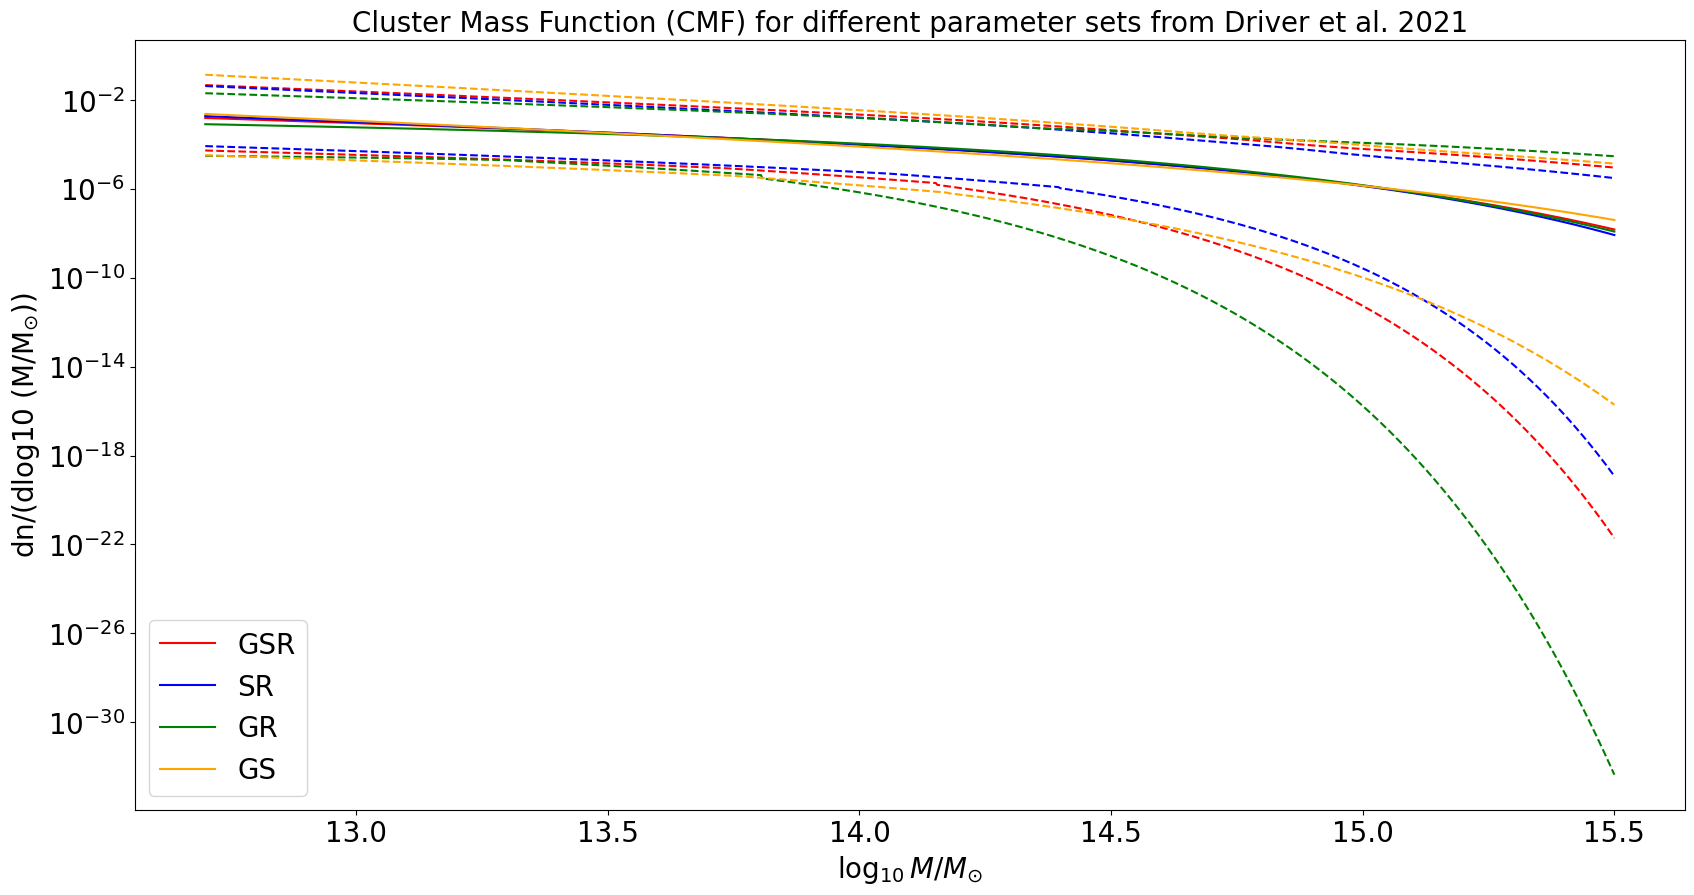

In [11]:
fig = plt.figure(figsize=(20, 10))

plt.plot(log10_M_Msun, CMF_GSR, label='GSR', color='red')
plt.plot(log10_M_Msun, Borne_min_CMF_GSR, color='red',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GSR, color='red',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_SR, label='SR', color='blue')
plt.plot(log10_M_Msun, Borne_min_CMF_SR, color='blue',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_SR, color='blue',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_GR, label='GR', color='green')
plt.plot(log10_M_Msun, Borne_min_CMF_GR, color='green',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GR, color='green',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_GS, label='GS', color='orange')
plt.plot(log10_M_Msun, Borne_min_CMF_GS, color='orange',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GS, color='orange',linestyle='dashed')

plt.xlabel(r'$\log_{10} M / M_{\odot}$')
plt.ylabel(r'dn/(dlog10 (M/M$_{\odot}$))')

plt.yscale('log')

plt.title('Cluster Mass Function (CMF) for different parameter sets from Driver et al. 2021')

plt.legend()


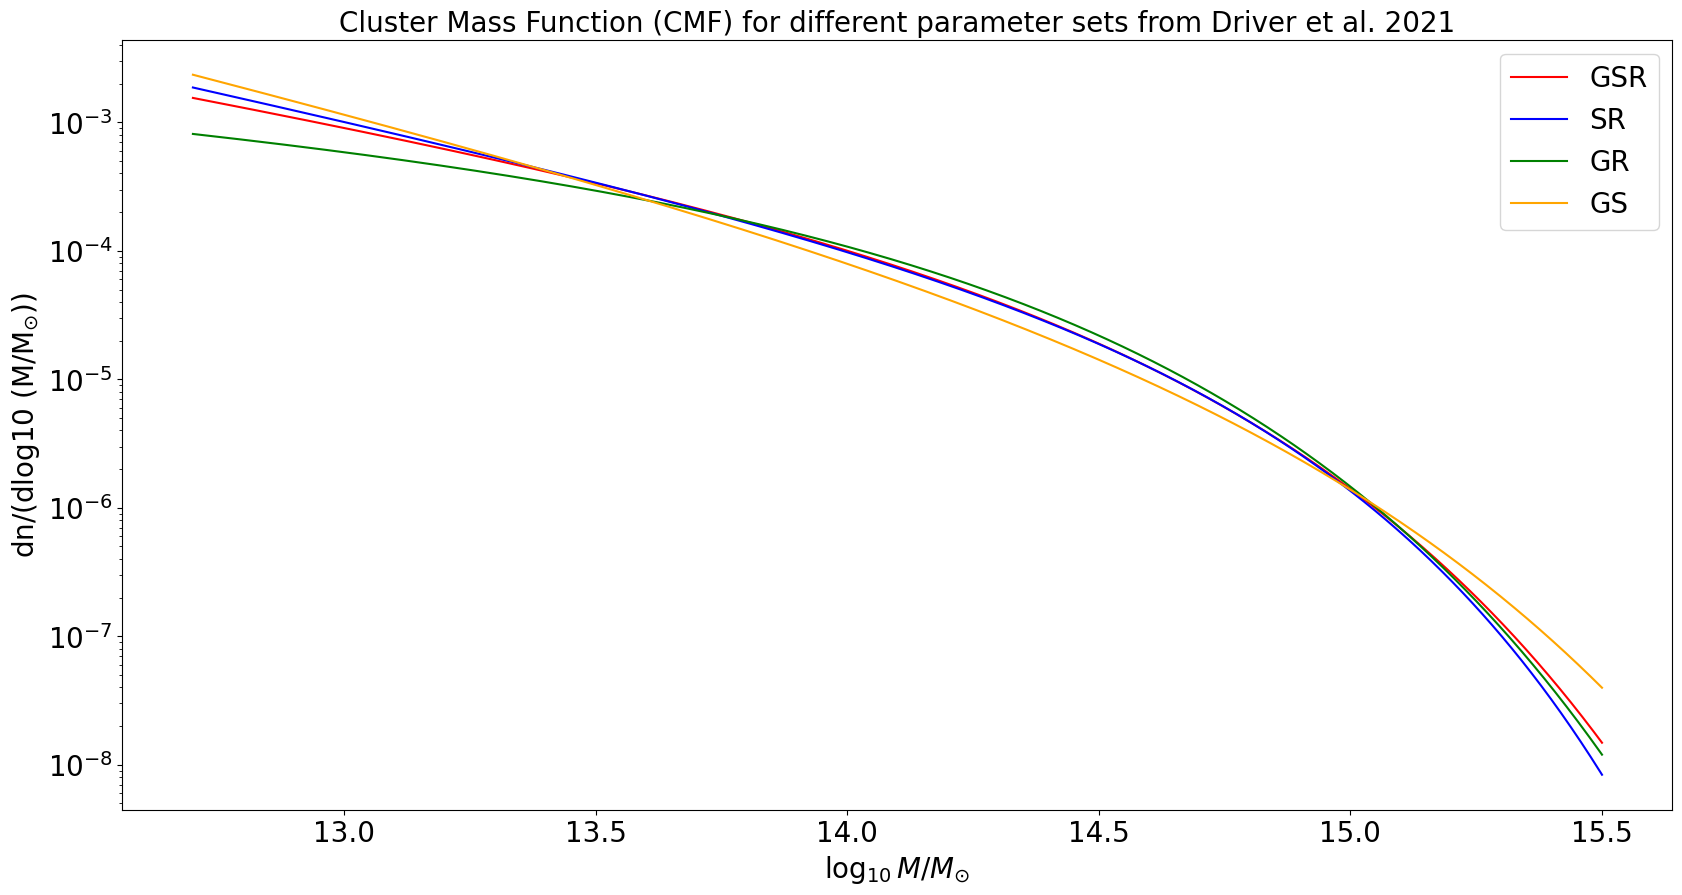

In [12]:
fig = plt.figure(figsize=(20, 10))

plt.plot(log10_M_Msun, CMF_GSR, label='GSR', color='red')


plt.plot(log10_M_Msun, CMF_SR, label='SR', color='blue')

plt.plot(log10_M_Msun, CMF_GR, label='GR', color='green')

plt.plot(log10_M_Msun, CMF_GS, label='GS', color='orange')


plt.xlabel(r'$\log_{10} M / M_{\odot}$')
plt.ylabel(r'dn/(dlog10 (M/M$_{\odot}$))')

plt.yscale('log')

plt.title('Cluster Mass Function (CMF) for different parameter sets from Driver et al. 2021')

plt.legend()

## Calcul nombre d'amas

In [13]:
# ATTENTION : calcul ci desoous PAS VALABLE car la mean density correspond à celle à z = 0.1 → On néglige cependant POUR l'INSTANT l'effet d'évolution de la CMF avec z 

# Nombre théorique d'amas dans le volume couvert par divers catalogues : pour l'instant DESI Legacy Imaging Surveys (Wen et Han 2024) ; SCUSS (Gao et al. 2019)
bornes_z = [0,0.65] # Bornes de redshift pour lesquelles on calcule le nombre d'amas (DESI Legacy va jusqu'à z = 1.5)

bornes_log10_M_Msun = [12.7,15.5] # Bornes de masses pour lesquelles la fonction MRP est valable 

## Densité volumique moyenne de la CMF théorique selon les différents lots de paramètres

mean_density_GSR = CMF_to_mean_density(CMF_GSR_func,bornes_log10_M_Msun)
mean_density_SR = CMF_to_mean_density(CMF_SR_func,bornes_log10_M_Msun)
mean_density_GR = CMF_to_mean_density(CMF_GR_func,bornes_log10_M_Msun)
mean_density_GS = CMF_to_mean_density(CMF_GS_func,bornes_log10_M_Msun)





## DESI Legacy Imaging Surveys

angular_area_DESI_deg2 = 24000 # Surface couverte par DESI Legacy Imaging Surveys en degrés carrés
volume_DESI_LEGACY = Volume_survey(angular_area_DESI_deg2,bornes_z) # Volume en Mpc^3 de la zone couverte par DESI Legacy Imaging Surveys (oon coupe en fait à 0.65 alors que ce relevé va jusqu'à 1.5, et on utilise la distance de diamètre angualaire pour la profondeur)

# GSR / DESI

N_GSR_DESI = mean_density_GSR * volume_DESI_LEGACY # Ce serait bien aussi de prendre en compte les erreurs pour avoir une fourchette de valeurs
print('N_GSR_DESI = ',round(N_GSR_DESI/1e6,3),'* 1e6 amas')

# SR / DESI

N_SR_DESI = mean_density_SR * volume_DESI_LEGACY 
print('N_SR_DESI = ',round(N_SR_DESI/1e6,3),'* 1e6 amas')

# GR / DESI

N_GR_DESI = mean_density_GR * volume_DESI_LEGACY
print('N_GR_DESI = ',round(N_GR_DESI/1e6,3),'* 1e6 amas')

# GS / DESI

N_GS_DESI = mean_density_GS * volume_DESI_LEGACY
print('N_GS_DESI = ',round(N_GS_DESI/1e6,3),'* 1e6 amas\n')






## SCUSS/SDSS/unWISE

bornes_z_SCUSS = [0.05,0.65]

angular_area_SCUSS_deg2 = 3700 # Surface couverte par SCUSS/SDSS/unWISE en degrés carrés
volume_SCUSS = Volume_survey(angular_area_SCUSS_deg2,bornes_z_SCUSS)

# GSR / SCUSS

N_GSR_SCUSS = mean_density_GSR * volume_SCUSS # Ce serait bien aussi de prendre en compte les erreurs pour avoir une fourchette de valeurs
print('N_GSR_SCUSS = ',round(N_GSR_SCUSS/1e6,3),'* 1e6 amas')

# SR / eRASS1

N_SR_SCUSS = mean_density_SR * volume_SCUSS 
print('N_SR_SCUSS = ',round(N_SR_SCUSS/1e6,3),'* 1e6 amas')

# GR / SCUSS

N_GR_SCUSS = mean_density_GR * volume_SCUSS
print('N_GR_SCUSSI = ',round(N_GR_SCUSS/1e6,3),'* 1e6 amas')

# GS / SCUSS

N_GS_SCUSS = mean_density_GS * volume_SCUSS
print('N_GS_SCUSS = ',round(N_GS_SCUSS/1e6,3),'* 1e6 amas\n')




## eRASS1

angular_area_eRASS1_deg2 = 13116 # Surface couverte par eRASS1/SDSS/unWISE en degrés carrés
volume_eRASS1 = Volume_survey(angular_area_eRASS1_deg2,bornes_z)

# GSR / eRASS1

N_GSR_eRASS1 = mean_density_GSR * volume_eRASS1 # Ce serait bien aussi de prendre en compte les erreurs pour avoir une fourchette de valeurs
print('N_GSR_eRASS1 = ',round(N_GSR_eRASS1/1e6,3),'* 1e6 amas')

# SR / eRASS1

N_SR_eRASS1 = mean_density_SR * volume_eRASS1 
print('N_SR_eRASS1 = ',round(N_SR_eRASS1/1e6,3),'* 1e6 amas')

# GR / eRASS1

N_GR_eRASS1 = mean_density_GR * volume_eRASS1
print('N_GR_eRASS1 = ',round(N_GR_eRASS1/1e6,3),'* 1e6 amas')

# GS / eRASS1

N_GS_eRASS1 = mean_density_GS * volume_eRASS1
print('N_GS_eRASS1 = ',round(N_GS_eRASS1/1e6,3),'* 1e6 amas')


N_GSR_DESI =  27.215 * 1e6 amas
N_SR_DESI =  29.846 * 1e6 amas
N_GR_DESI =  19.3 * 1e6 amas
N_GS_DESI =  32.938 * 1e6 amas

N_GSR_SCUSS =  4.193 * 1e6 amas
N_SR_SCUSS =  4.598 * 1e6 amas
N_GR_SCUSSI =  2.973 * 1e6 amas
N_GS_SCUSS =  5.074 * 1e6 amas

N_GSR_eRASS1 =  14.873 * 1e6 amas
N_SR_eRASS1 =  16.311 * 1e6 amas
N_GR_eRASS1 =  10.548 * 1e6 amas
N_GS_eRASS1 =  18.001 * 1e6 amas


# Comparaison avec les catalogues

## DESI Legacy Imaging surveys

In [14]:
path_DESI = '../SCUSS_DESI/DESI_Legacy_Wen_2024.fit'

table_DESI = fits_to_dataframe(path_DESI)

In [15]:
table_DESI

,_RAJ2000,_DEJ2000,ID,n_Name,Name,RAJ2000,DEJ2000,zCl,f_zCl,zmag,...,logMs,r500,lam500,M500,Ngal,Gamma,e_Gamma,imag_,Cat,recno
0,0.00046,-37.47628,1,,J000000.1-372835,0.00046,-37.47628,0.1364,0,15.377,...,11.49,0.766,25.79,1.17,14,0.0,0.0,1,WHY18,1
1,0.00135,-56.58835,2,WH-,J000000.3-563518,0.00135,-56.58835,0.1957,0,15.712,...,11.70,0.625,23.24,1.06,7,0.0,0.0,1,,2
2,0.00172,-39.32369,3,,J000000.4-391925,0.00172,-39.32369,0.3580,0,17.713,...,11.41,0.526,15.90,0.73,7,0.0,0.0,1,Y21,3
3,0.00201,2.31980,4,,J000000.5+021911,0.00201,2.31980,0.4282,1,18.043,...,11.55,0.612,23.40,1.07,13,0.0,0.0,1,redMaPPer,4
4,0.00260,-59.01297,5,WH-,J000000.6-590047,0.00260,-59.01297,0.1380,0,14.993,...,11.69,0.606,15.71,0.73,7,0.0,0.0,1,,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1581174,359.99667,4.99211,1581175,WH-,J235959.2+045932,359.99667,4.99211,0.5948,0,19.184,...,11.37,0.420,10.99,0.51,6,0.0,0.0,2,,1581175
1581175,359.99680,21.78514,1581176,,J235959.2+214707,359.99680,21.78514,0.4050,1,17.259,...,11.78,0.658,31.73,1.43,9,0.0,0.0,2,WHL,1581176
1581176,359.99817,10.04951,1581177,,J235959.6+100258,359.99817,10.04951,0.7919,0,18.904,...,11.88,0.621,33.23,1.50,8,0.0,0.0,2,CFSFDP,1581177
1581177,359.99847,-6.34469,1581178,WH-,J235959.6-062041,359.99847,-6.34469,1.0333,0,20.952,...,11.18,0.439,13.12,0.61,6,0.0,0.0,2,,1581178


In [16]:
table_DESI.columns

Index(['_RAJ2000', '_DEJ2000', 'ID', 'n_Name', 'Name', 'RAJ2000', 'DEJ2000',
       'zCl', 'f_zCl', 'zmag', 'W1mag', 'logMs', 'r500', 'lam500', 'M500',
       'Ngal', 'Gamma', 'e_Gamma', 'imag_', 'Cat', 'recno'],
      dtype='object')

In [17]:
# Nombre d'amas compris entre les bornes de z utilisés pour le calcul du nombre d'amas à partir de la CMF théorique

N_amas_DESI = len(table_DESI[(table_DESI['zCl'] >= bornes_z[0]) & (table_DESI['zCl'] <= bornes_z[1])])
print('N_amas_DESI = ',N_amas_DESI)

N_amas_DESI =  821225


In [18]:
# A FAIRE → DISTRIBUTION AMAS LUMINOSITE + COULEUR REDSHIFT ...

In [19]:
M500_DESI = np.log10(np.array(table_DESI['M500'])*1e14)
M500_DESI = M500_DESI[(M500_DESI > 12.7) & (M500_DESI < 15.5)] # On ne garde que les amas compris entre les bornes de masses utilisées pour le calcul de la CMF (pour DESI LEgacy, on conserve tout)

Text(0.5, 1.0, 'Histogramme des masses des amas dans DESI Legacy Imaging Surveys')

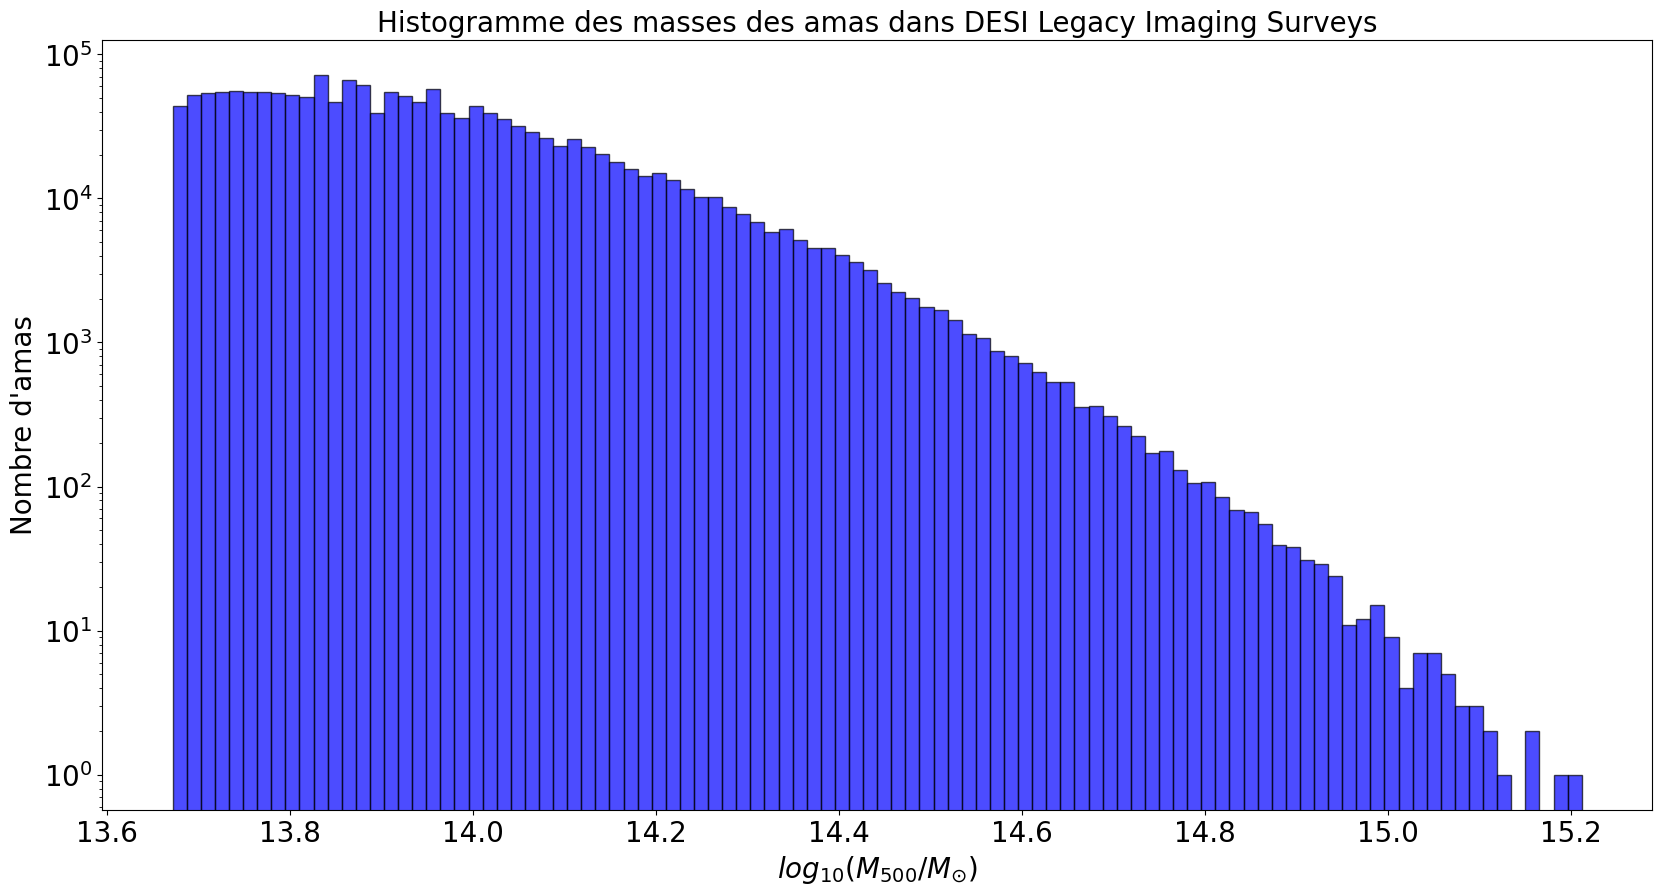

In [20]:
plt.figure(figsize=(20, 10))
plt.hist(M500_DESI, bins=100, color='blue', edgecolor='black', alpha=0.7)
plt.xlabel(r'$log_{10}(M_{500}/M_{\odot})$')
plt.ylabel('Nombre d\'amas')
plt.yscale('log')
plt.title('Histogramme des masses des amas dans DESI Legacy Imaging Surveys')

In [21]:
counts, bin_edges = np.histogram(M500_DESI, bins=100)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:]) # Calculate bin centers
cloud_of_points = list(zip(bin_centers, counts)) # Pair counts with bin centers
# cloud_of_points is now a list of (mass, count) 

bin_widths_DESI = np.diff(bin_edges)
bin_width_DESI = bin_widths_DESI[0] # la largeur d'un bin est toujours la même
print("Bin width:", bin_width_DESI) 

n_DESI_Legacy = (counts/bin_width_DESI)/volume_DESI_LEGACY # 1- On divise le nombre d'amas par la largeur des bins pour obtenir la densité volumique par bin de masse (renormalisation par bin de masse) 
                                                          # 2- On divise par le volume de la zone couverte par DESI Legacy Imaging Surveys pour obtenir la densité volumique moyenne par bin de masse



Bin width: 0.015392896950011448


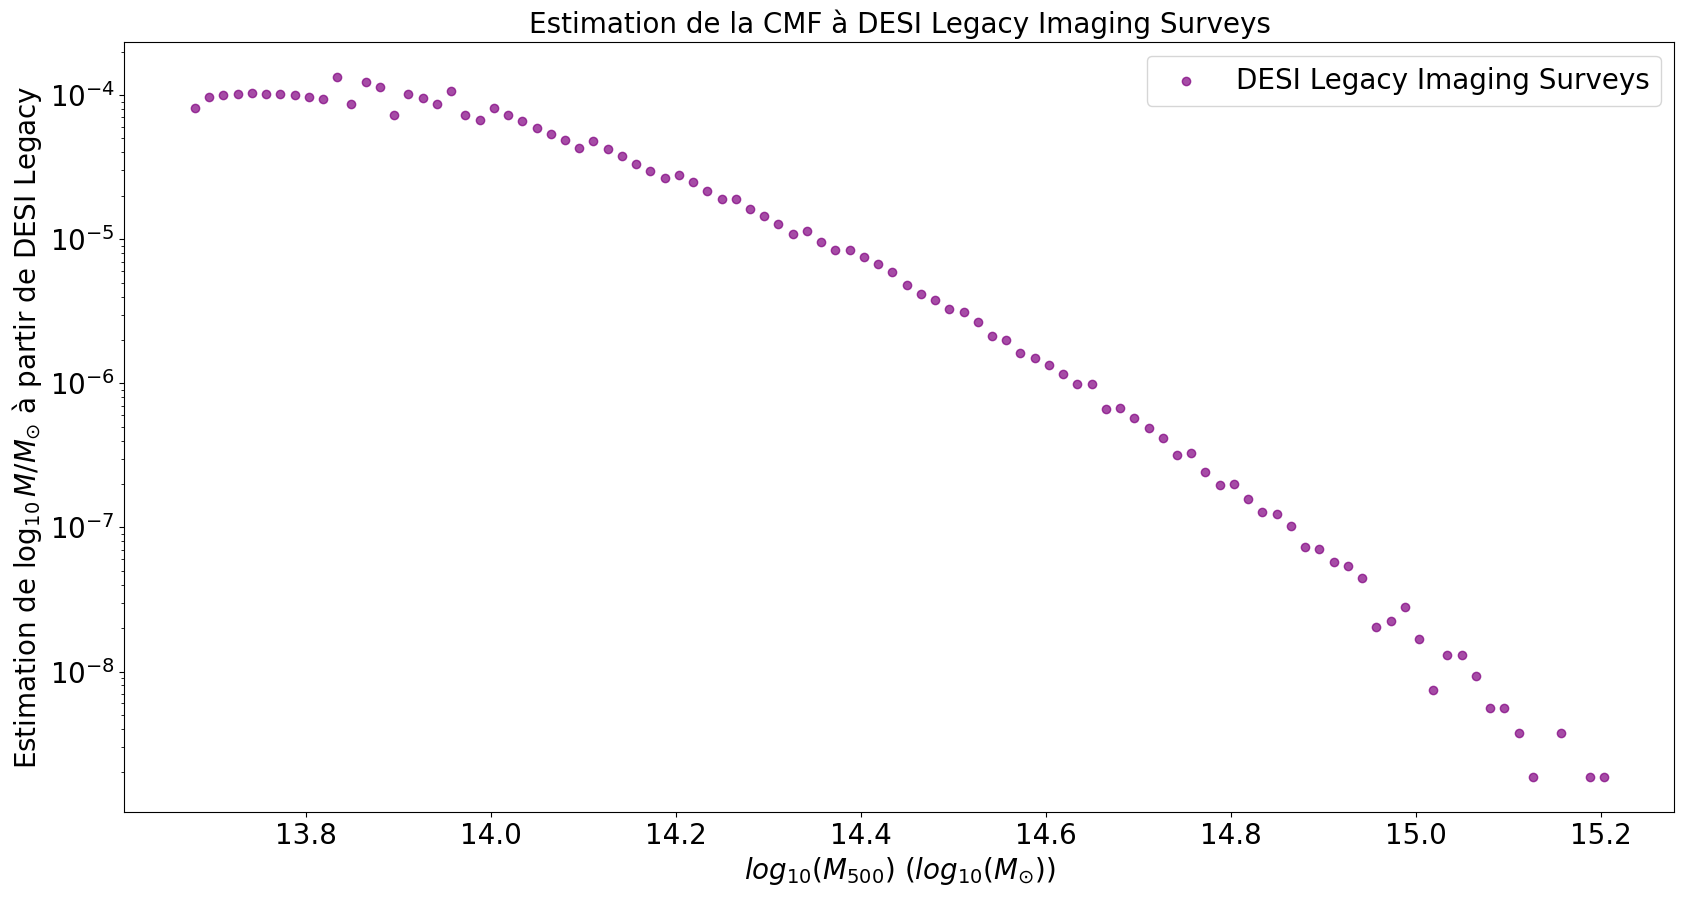

In [22]:
fig = plt.figure(figsize=(20, 10))
plt.scatter(bin_centers, n_DESI_Legacy, color='purple', label='DESI Legacy Imaging Surveys', alpha=0.7) 
plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'Estimation de $\log_{10} M / M_{\odot}$ à partir de DESI Legacy')
plt.yscale('log')
plt.title('Estimation de la CMF à DESI Legacy Imaging Surveys')
plt.legend()

<>:21: SyntaxWarning: invalid escape sequence '\o'
<>:21: SyntaxWarning: invalid escape sequence '\o'
C:\Users\ED282972\AppData\Local\Temp\ipykernel_16740\3396573795.py:21: SyntaxWarning: invalid escape sequence '\o'
  ''' le calcul des résidus (différence des valeurs) n'est pas pertinent en comparaison du rapport entre les valeurs, qui informe sur l'effet de sélection


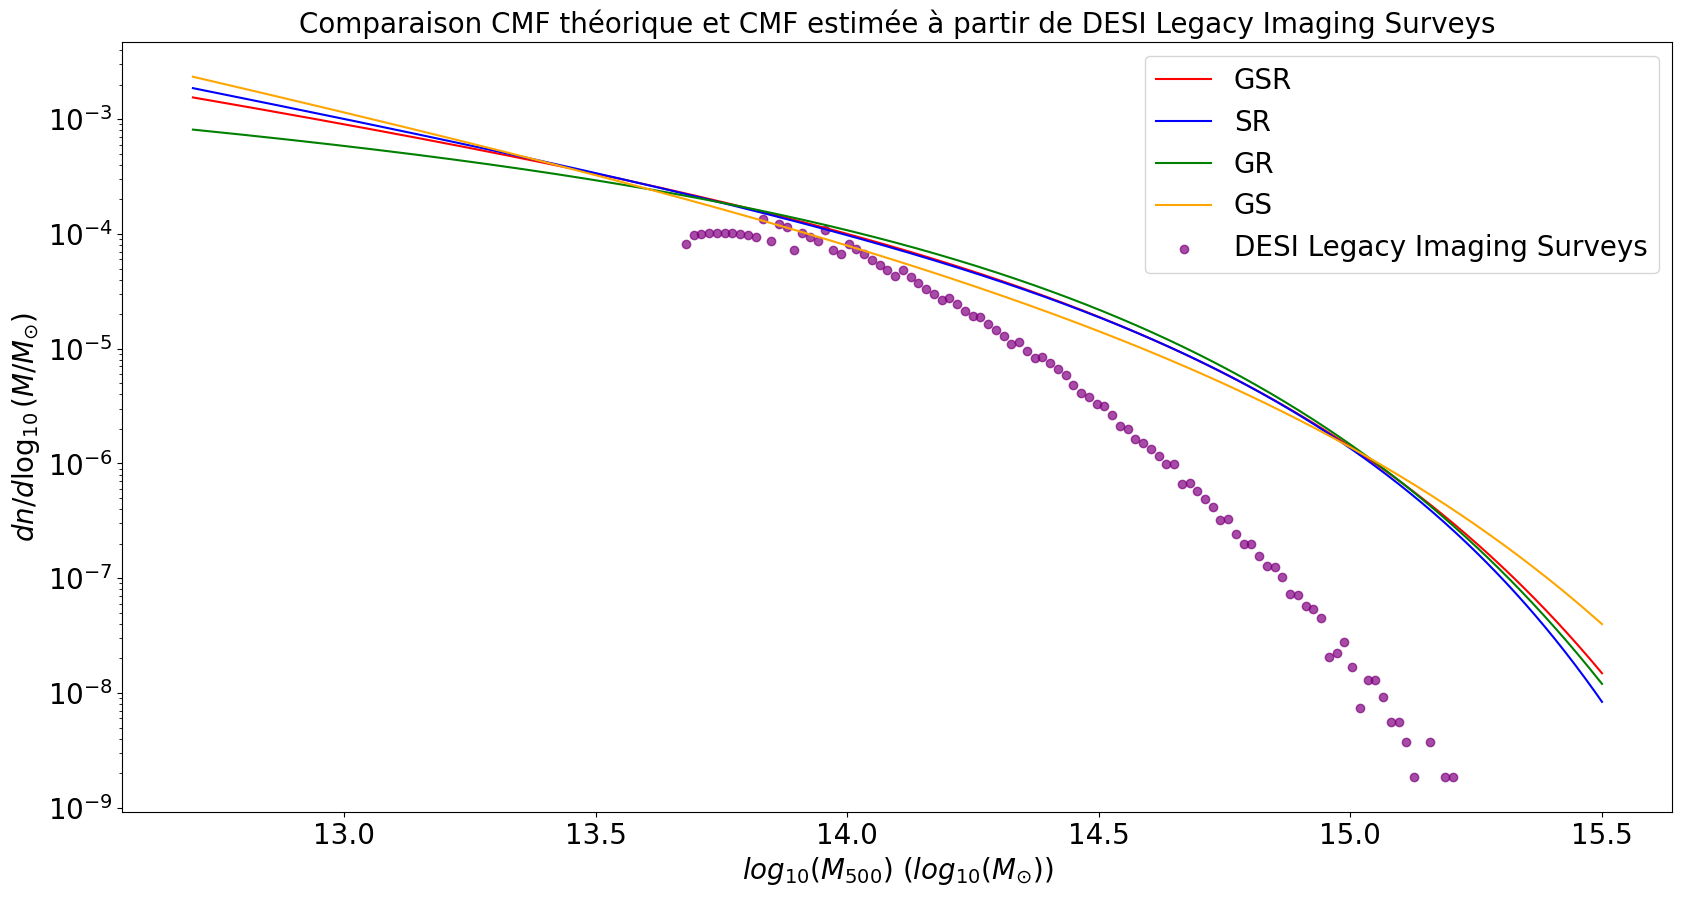

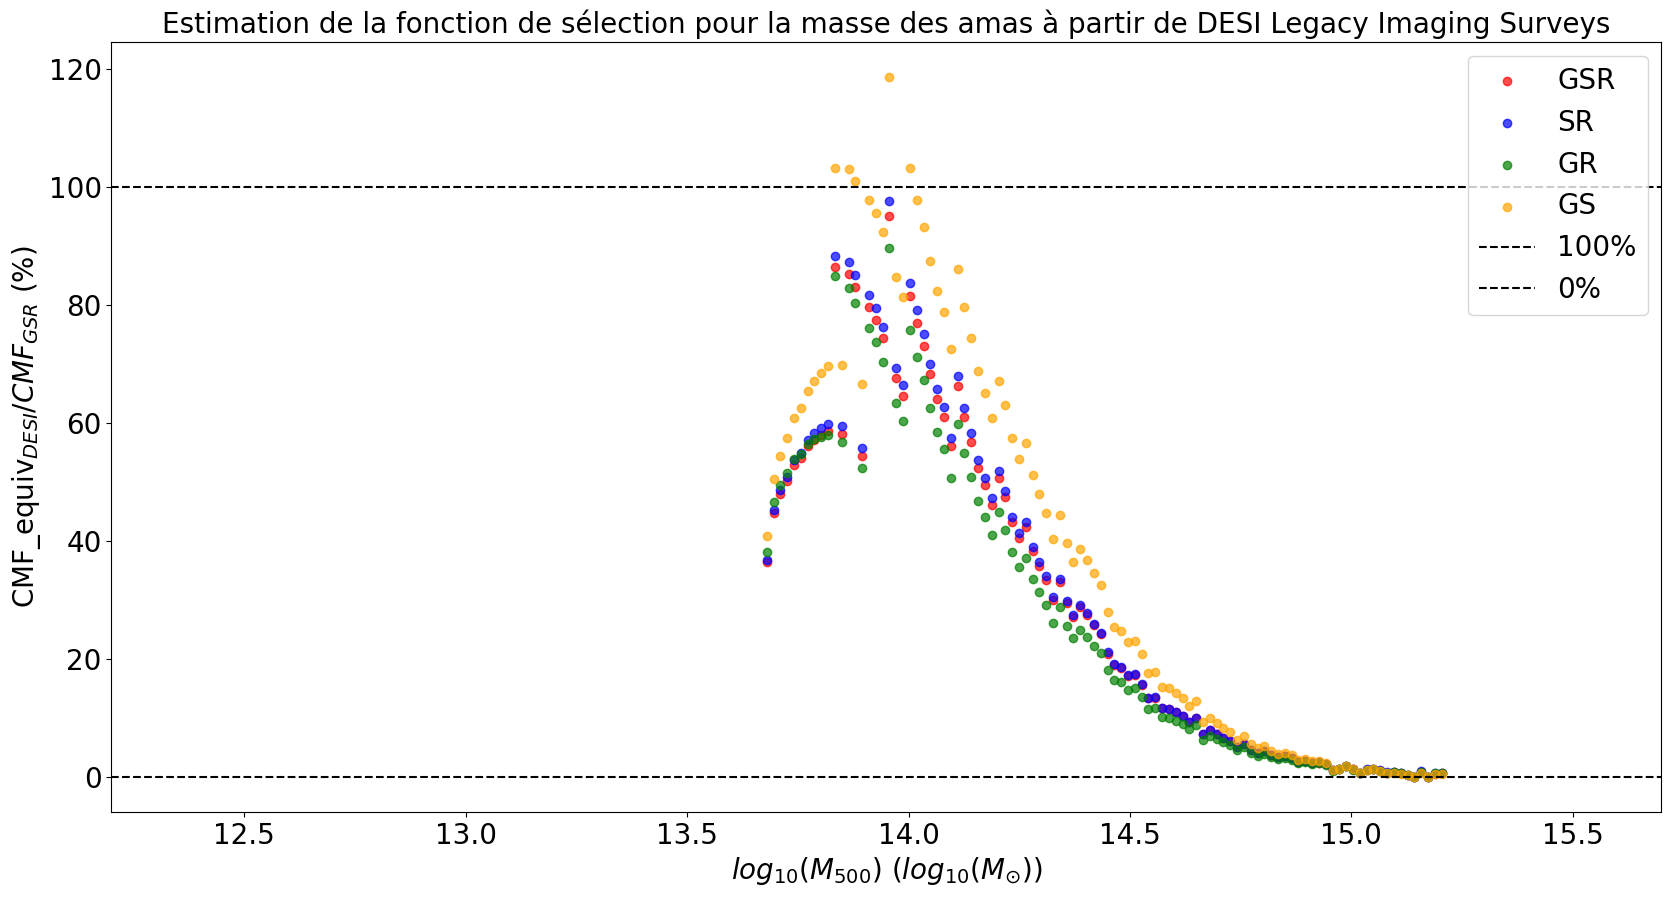

In [23]:
# Mpc ^-3 dex -1

# ATTENTION : On n'a pas pris en compte l'évolution en fonction du redshift, ni la masse de référence utilisée pour la fonction MRP (M500 ou autre chose ? → je n'arrive pas à trouver dans les papiers pour l'instant)

fig1 = plt.figure(figsize=(20, 10))

plt.plot(log10_M_Msun, CMF_GSR, label='GSR', color='red')
plt.plot(log10_M_Msun, CMF_SR, label='SR', color='blue')
plt.plot(log10_M_Msun, CMF_GR, label='GR', color='green')
plt.plot(log10_M_Msun, CMF_GS, label='GS', color='orange')

plt.scatter(bin_centers, n_DESI_Legacy, color='purple', label='DESI Legacy Imaging Surveys', alpha=0.7)

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$dn / d\log_{10} (M / M_{\odot})$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de DESI Legacy Imaging Surveys')

plt.legend()

''' le calcul des résidus (différence des valeurs) n'est pas pertinent en comparaison du rapport entre les valeurs, qui informe sur l'effet de sélection

residuals_GSR = np.abs(CMF_GSR_func(bin_centers) - n_DESI_Legacy)
residuals_SR = np.abs(CMF_SR_func(bin_centers) - n_DESI_Legacy)
residuals_GR = np.abs(CMF_GR_func(bin_centers) - n_DESI_Legacy)
residuals_GS = np.abs(CMF_GS_func(bin_centers) - n_DESI_Legacy)


fig2 = plt.figure(figsize=(20, 10))
plt.scatter(bin_centers, residuals_GSR, color='red', label='GSR Residuals', alpha=0.7)
plt.scatter(bin_centers, residuals_SR, color='blue', label='SR Residuals', alpha=0.7)
plt.scatter(bin_centers, residuals_GR, color='green', label='GR Residuals', alpha=0.7)
plt.scatter(bin_centers, residuals_GS, color='orange', label='GS Residuals', alpha=0.7)
plt.xlim(12.2, 15.7)
plt.yscale('log')

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$dn / d\log_{10} M / M_{\odot}$')


plt.title('Résidus entre la CMF théorique et la CMF estimée à partir de DESI Legacy Imaging Surveys')

'''

# On essaie d'en déduire une fonction de sélection en fonction de la masse des amas

estimation_selection_function_masse_GSR = n_DESI_Legacy/CMF_GSR_func(bin_centers)
estimation_selection_function_masse_SR = n_DESI_Legacy/CMF_SR_func(bin_centers)
estimation_selection_function_masse_GR = n_DESI_Legacy/CMF_GR_func(bin_centers)
estimation_selection_function_masse_GS = n_DESI_Legacy/CMF_GS_func(bin_centers)


plt.figure(figsize=(20, 10))

plt.scatter(bin_centers, estimation_selection_function_masse_GSR * 100, color='red', alpha=0.7,label='GSR')
plt.scatter(bin_centers, estimation_selection_function_masse_SR * 100, color='blue', alpha=0.7,label='SR')
plt.scatter(bin_centers, estimation_selection_function_masse_GR * 100, color='green', alpha=0.7,label='GR')
plt.scatter(bin_centers, estimation_selection_function_masse_GS * 100, color='orange', alpha=0.7,label='GS')
plt.xlim(12.2, 15.7)

plt.hlines(100, 12.2, 15.7, color='black', linestyle='dashed', label='100%')
plt.hlines(0, 12.2, 15.7, color='black', linestyle='dashed', label='0%')


plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'CMF_equiv$_{DESI} / CMF_{GSR}$ (%)')
plt.title('Estimation de la fonction de sélection pour la masse des amas à partir de DESI Legacy Imaging Surveys')

plt.legend()


plt.legend()

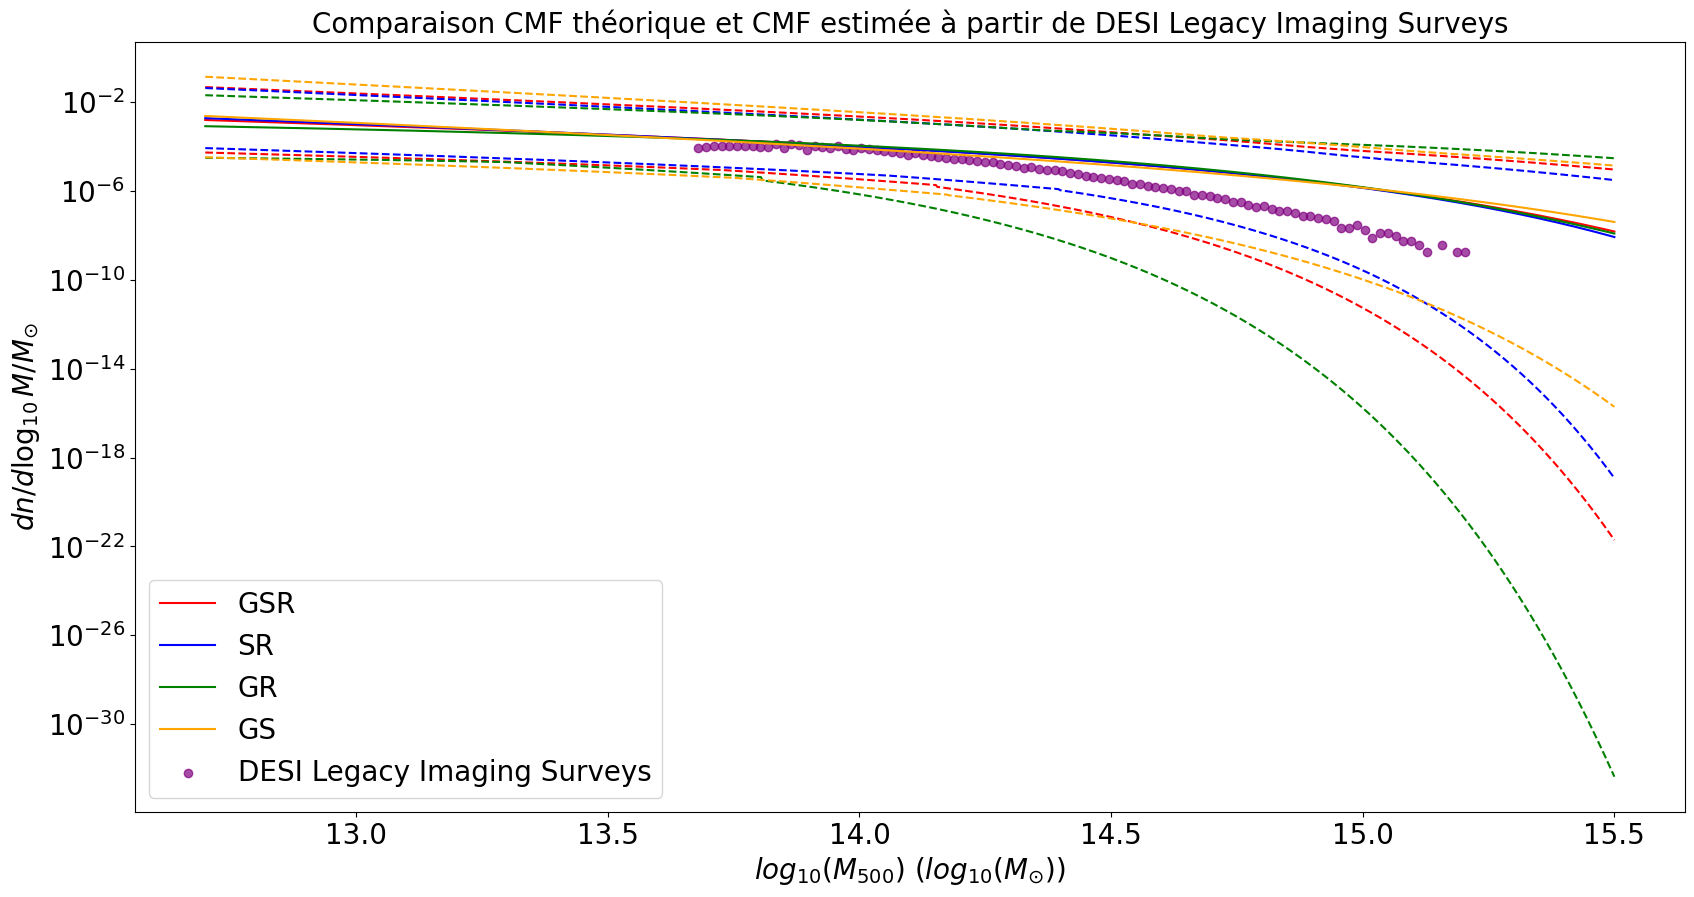

In [24]:
# Mpc ^-3 dex -1
fig = plt.figure(figsize=(20, 10))

plt.plot(log10_M_Msun, CMF_GSR, label='GSR', color='red')
plt.plot(log10_M_Msun, Borne_min_CMF_GSR, color='red',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GSR, color='red',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_SR, label='SR', color='blue')
plt.plot(log10_M_Msun, Borne_min_CMF_SR, color='blue',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_SR, color='blue',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_GR, label='GR', color='green')
plt.plot(log10_M_Msun, Borne_min_CMF_GR, color='green',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GR, color='green',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_GS, label='GS', color='orange')
plt.plot(log10_M_Msun, Borne_min_CMF_GS, color='orange',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GS, color='orange',linestyle='dashed')

plt.scatter(bin_centers, n_DESI_Legacy, color='purple', label='DESI Legacy Imaging Surveys', alpha=0.7)

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$dn / d\log_{10} M / M_{\odot}$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de DESI Legacy Imaging Surveys')
plt.legend()

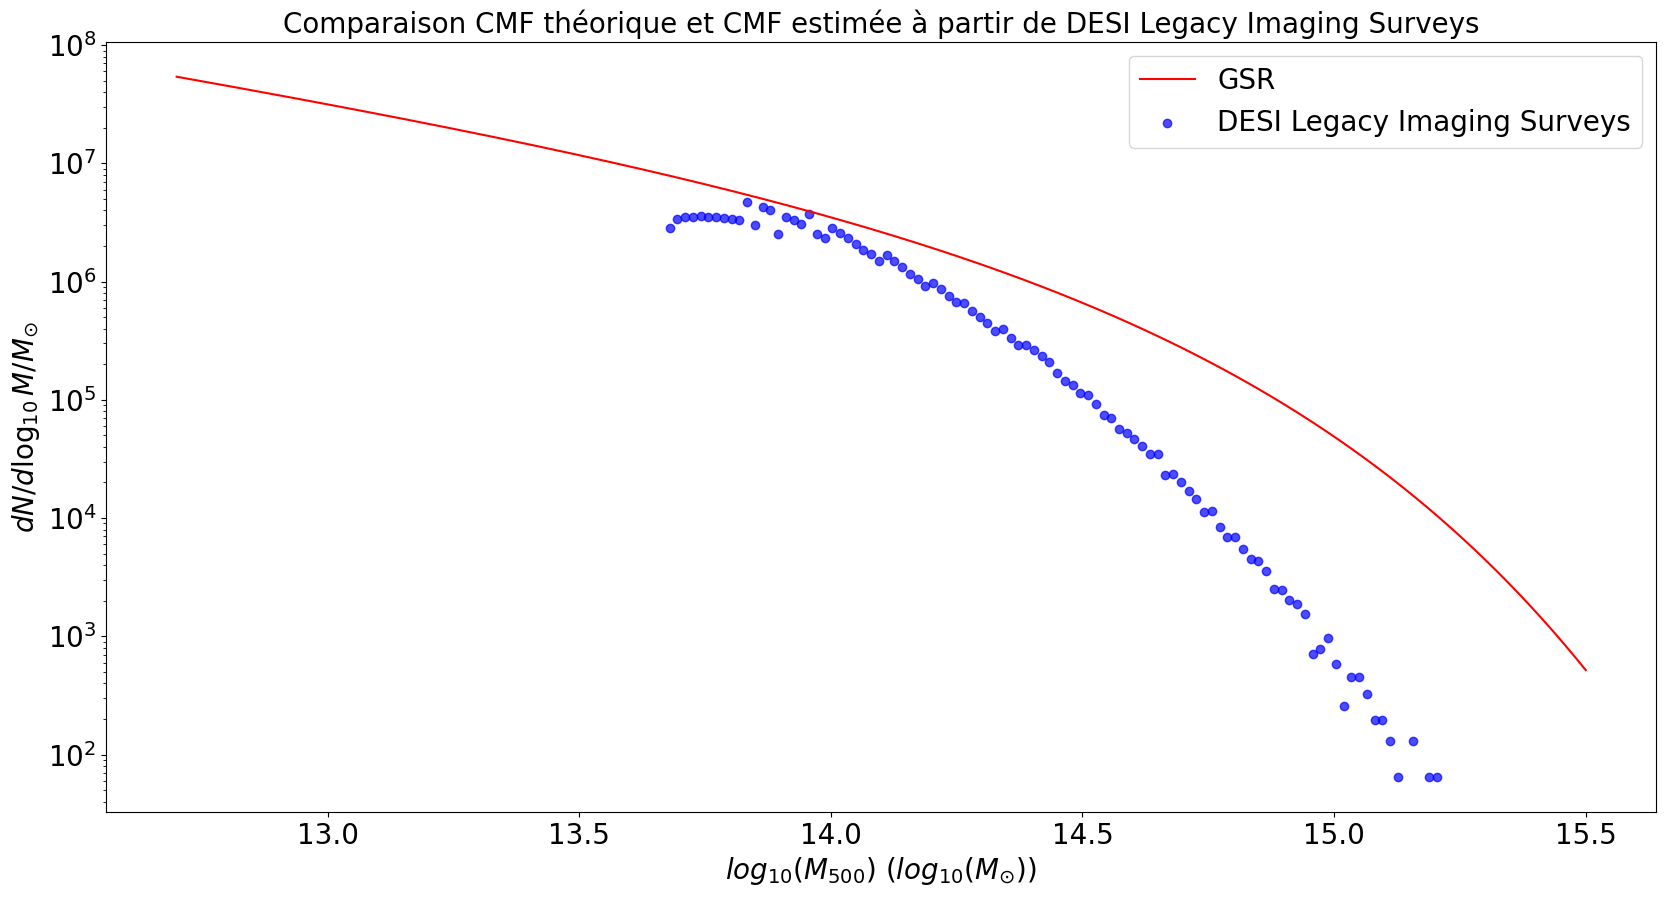

In [25]:
# dex ^-1

fig = plt.figure(figsize=(20, 10))
plt.plot(log10_M_Msun, CMF_GSR*volume_DESI_LEGACY, label='GSR', color='red')
plt.scatter(bin_centers, counts/bin_width_DESI, color='blue', label='DESI Legacy Imaging Surveys', alpha=0.7)
plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$dN / d\log_{10} M / M_{\odot}$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de DESI Legacy Imaging Surveys')
plt.legend()


## SCUSS

In [26]:
#SCUSS
path_SCUSS = '../SCUSS_DESI/SCUSS_Gao_2020.fit' #la première table est la table eRosita de départ, enrichie avec des informations d'association avec SDSS-Wen
table_SCUSS = fits_to_dataframe(path_SCUSS)

zSCUSS_list = []
for idx, row in table_SCUSS.iterrows():
    if row[f'zsp'] == 0:
        zSCUSS_list.append(row[f'zph'])
    else:
        zSCUSS_list.append(row[f'zsp'])
table_SCUSS['z'] = zSCUSS_list


# On découpe la table en différents bins de z contenant le même nombre d'amas
nb_bins_z = 3
table_SCUSS['z_bin'], bornes_z_SCUSS = pd.qcut(table_SCUSS['z'], q=nb_bins_z, retbins=True, labels=False)
print('Bornes de z pour les bins SCUSS : ', bornes_z_SCUSS)

# Create subtables for each bin
subtables_z_SCUSS = []
for i in range(nb_bins_z):
    subtable = table_SCUSS[table_SCUSS['z_bin'] == i]
    print(f'bin {i}: z from {round(bornes_z_SCUSS[i],3)} to {round(bornes_z_SCUSS[i+1],3)}, count={len(subtable)}')
    subtables_z_SCUSS.append(subtable)


Bornes de z pour les bins SCUSS :  [0.0503     0.28770333 0.39967667 0.6299    ]
bin 0: z from 0.05 to 0.288, count=6537
bin 1: z from 0.288 to 0.4, count=6536
bin 2: z from 0.4 to 0.63, count=6537


In [27]:
table_SCUSS.columns

Index(['_RAJ2000', '_DEJ2000', 'Name', 'RAJ2000', 'DEJ2000', 'zph', 'zsp',
       'zphmedian', 'N1Mpc', 'L1Mpc', 'Richness', 'M500', 'recno', 'z',
       'z_bin'],
      dtype='object')

### Fonction de masse

In [28]:
M500_SCUSS = np.log10(np.array(table_SCUSS['M500'])*1e14)
M500_SCUSS = M500_SCUSS[(M500_SCUSS > 12.7) & (M500_SCUSS < 15.5)] # On ne garde que les amas compris entre les bornes de masses utilisées pour le calcul de la CMF (pour DESI LEgacy, on conserve tout)

Text(0.5, 1.0, 'Histogramme des masses des amas dans SCUSS')

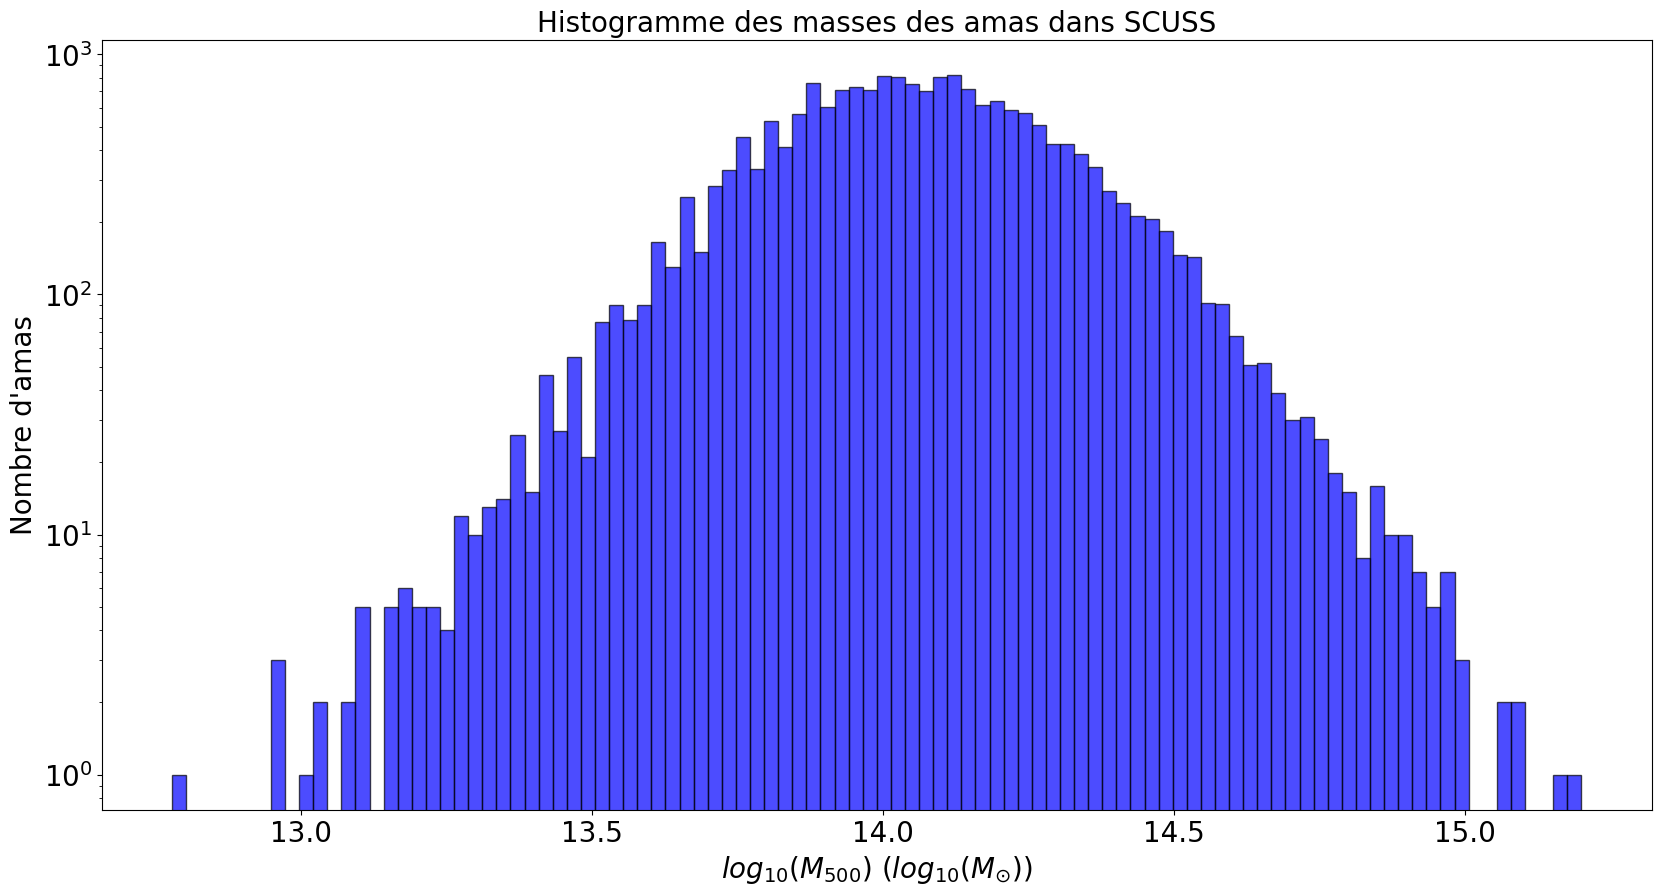

In [29]:
plt.figure(figsize=(20, 10))
plt.hist(M500_SCUSS, bins=100, color='blue', edgecolor='black', alpha=0.7)
plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel('Nombre d\'amas')
plt.yscale('log')
plt.title('Histogramme des masses des amas dans SCUSS')

In [30]:
counts, bin_edges = np.histogram(M500_SCUSS, bins=100)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:]) # Calculate bin centers
cloud_of_points = list(zip(bin_centers, counts)) # Pair counts with bin centers
# cloud_of_points is now a list of (mass, count) pair

bin_widths_SCUSS = np.diff(bin_edges)
bin_width_SCUSS = bin_widths_SCUSS[0] # la largeur d'un bin est toujours la même
print("Bin width:", bin_width_SCUSS) 

n_SCUSS = (counts/bin_width_SCUSS)/volume_SCUSS

Bin width: 0.024221519325980267


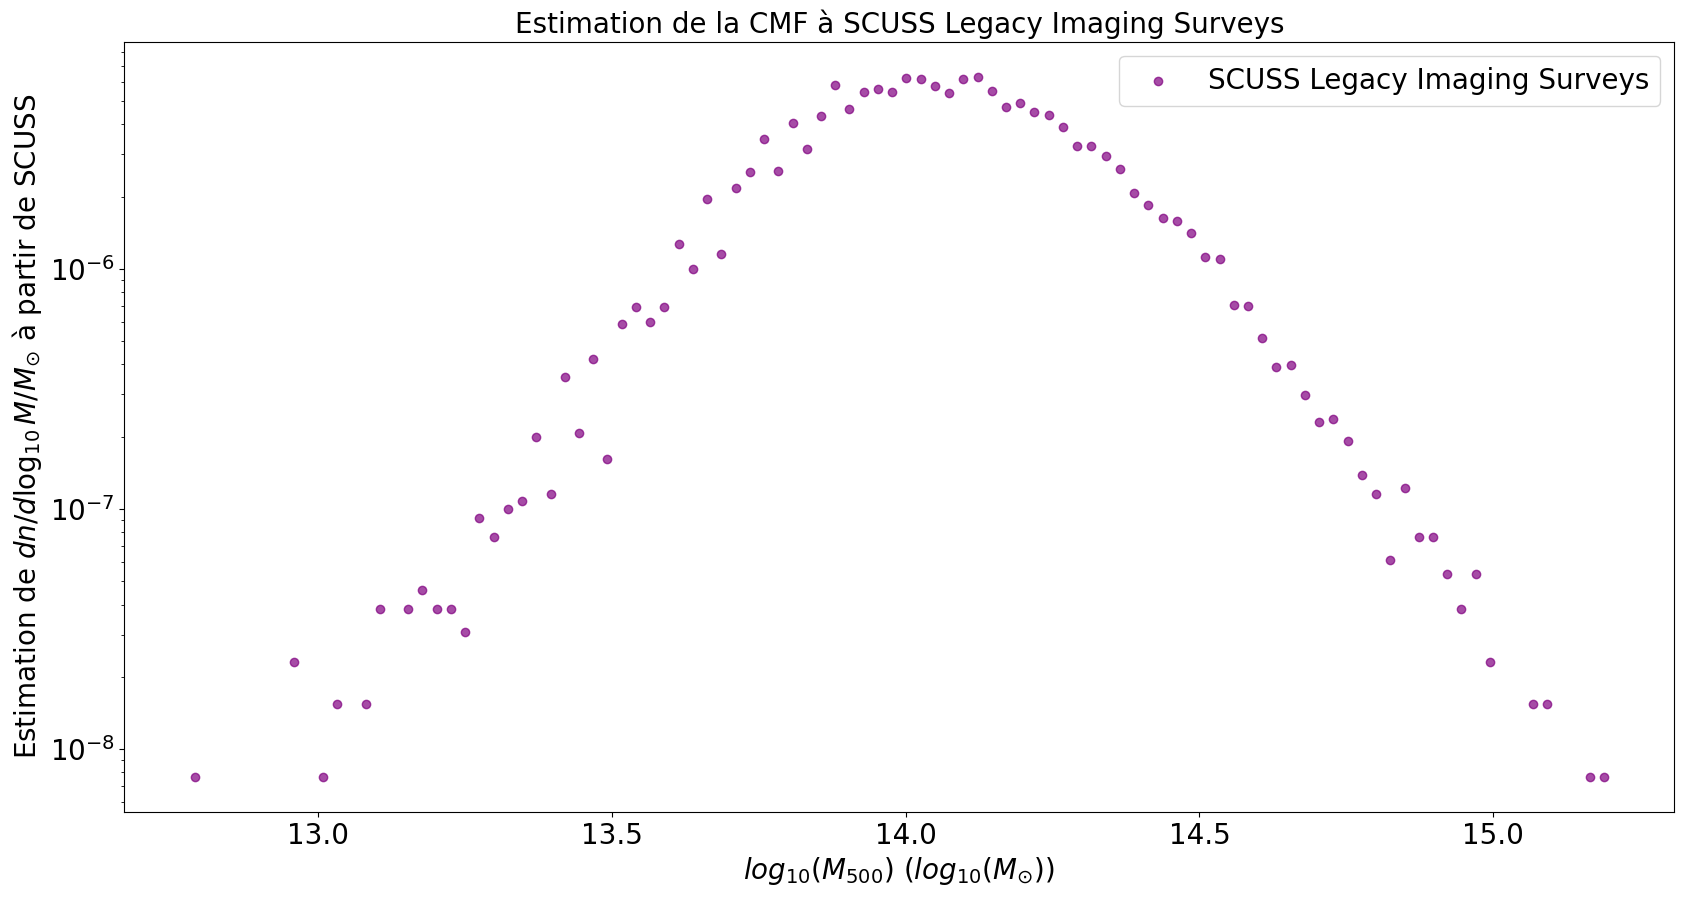

In [31]:
fig = plt.figure(figsize=(20, 10))
plt.scatter(bin_centers, n_SCUSS, color='purple', label='SCUSS Legacy Imaging Surveys', alpha=0.7) 
plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'Estimation de $dn / d\log_{10} M / M_{\odot}$ à partir de SCUSS')
plt.yscale('log')
plt.title('Estimation de la CMF à SCUSS Legacy Imaging Surveys')
plt.legend()

<>:22: SyntaxWarning: invalid escape sequence '\o'
<>:22: SyntaxWarning: invalid escape sequence '\o'
C:\Users\ED282972\AppData\Local\Temp\ipykernel_16740\4127493681.py:22: SyntaxWarning: invalid escape sequence '\o'
  '''residuals_GSR = np.abs(CMF_GSR_func(bin_centers) - n_SCUSS)


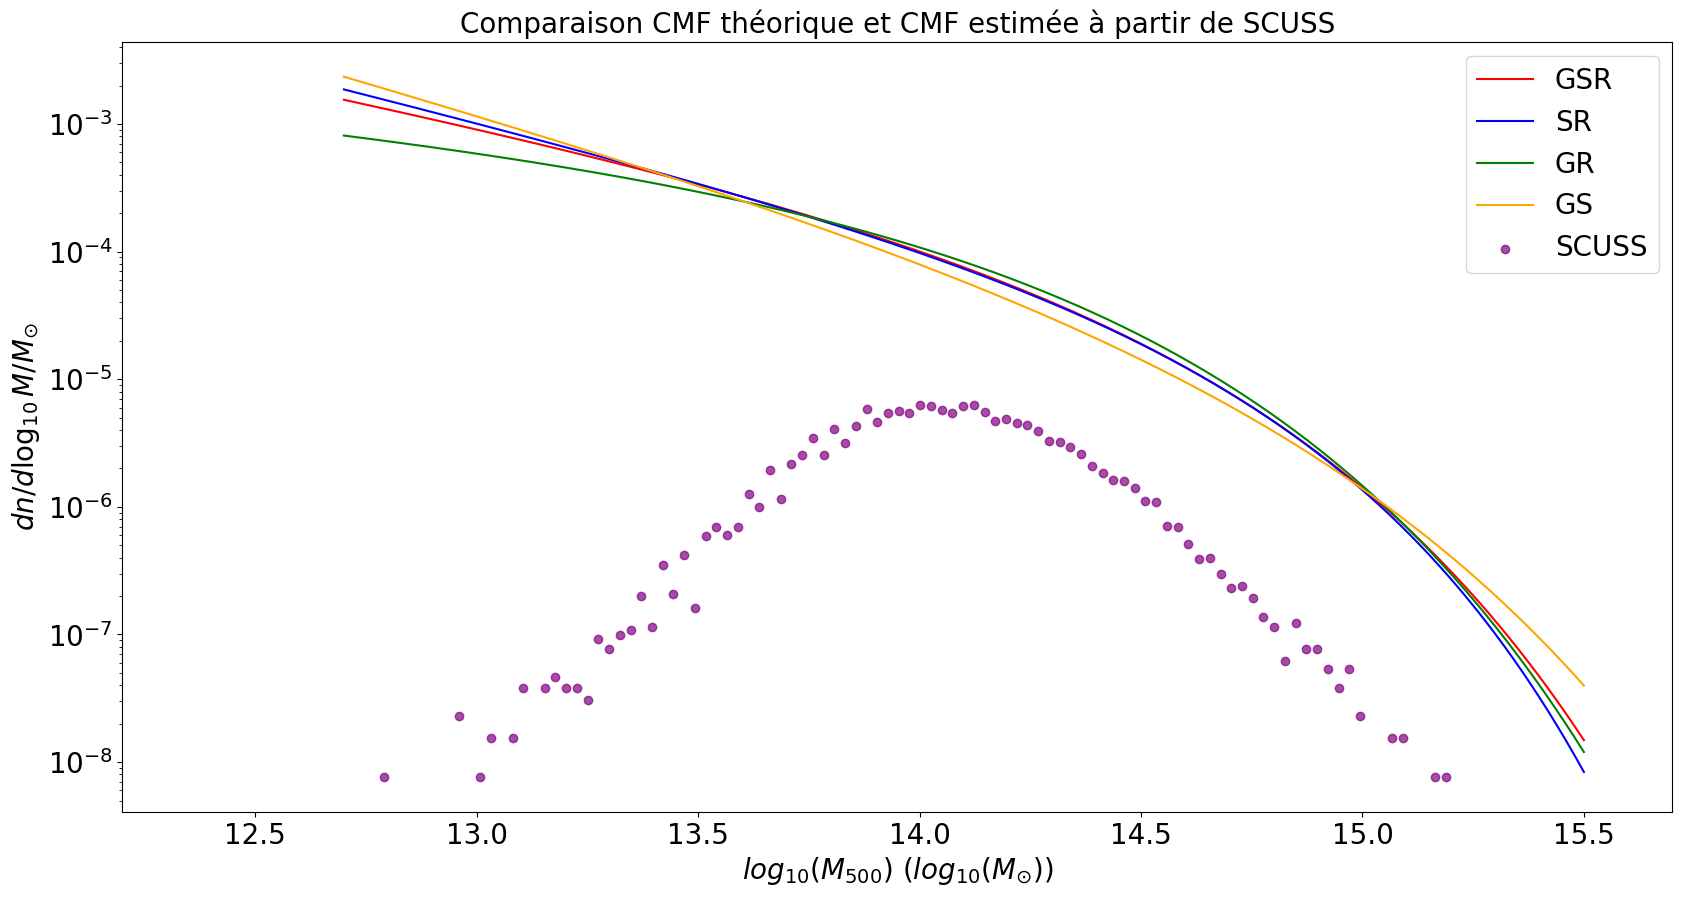

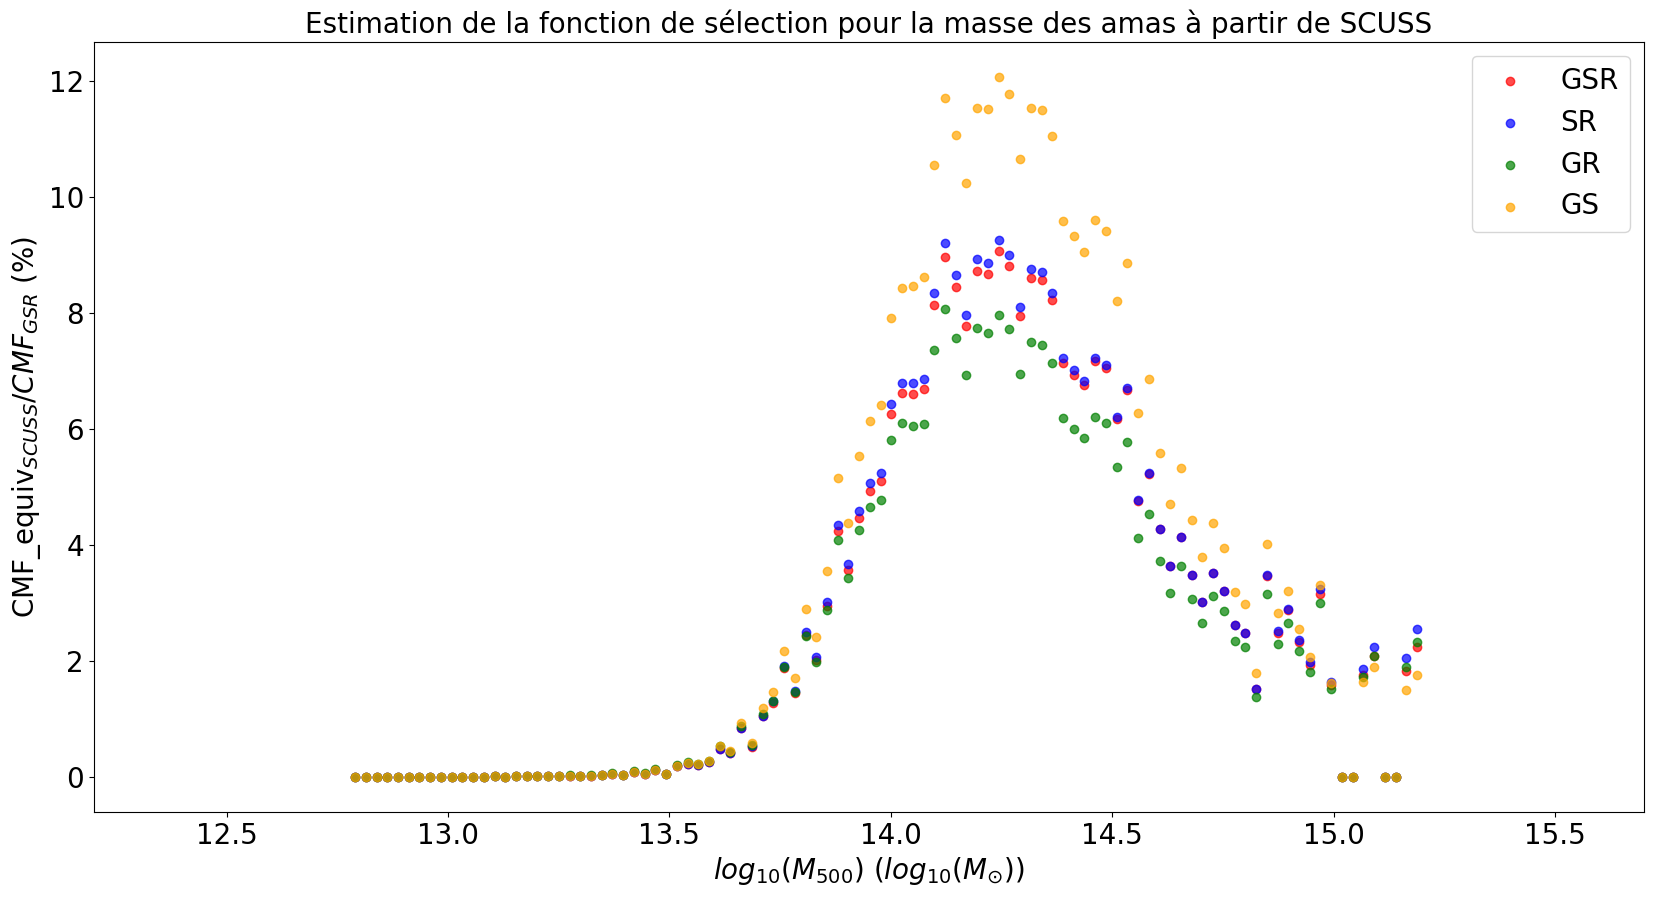

In [32]:
# Mpc ^-3 dex -1

# ATTENTION : On n'a pas pris en compte l'évolution en fonction du redshift, ni la masse de référence utilisée pour la fonction MRP (M500 ou autre chose ? → je n'arrive pas à trouver dans les papiers pour l'instant)

fig1 = plt.figure(figsize=(20, 10))

plt.plot(log10_M_Msun, CMF_GSR, label='GSR', color='red')
plt.plot(log10_M_Msun, CMF_SR, label='SR', color='blue')
plt.plot(log10_M_Msun, CMF_GR, label='GR', color='green')
plt.plot(log10_M_Msun, CMF_GS, label='GS', color='orange')

plt.scatter(bin_centers, n_SCUSS, color='purple', label='SCUSS', alpha=0.7)
plt.xlim(12.2, 15.7)

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$dn / d\log_{10} M / M_{\odot}$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de SCUSS')

plt.legend()

'''residuals_GSR = np.abs(CMF_GSR_func(bin_centers) - n_SCUSS)
residuals_SR = np.abs(CMF_SR_func(bin_centers) - n_SCUSS)
residuals_GR = np.abs(CMF_GR_func(bin_centers) - n_SCUSS)
residuals_GS = np.abs(CMF_GS_func(bin_centers) - n_SCUSS)


fig2 = plt.figure(figsize=(20, 10))
plt.scatter(bin_centers, residuals_GSR, color='red', label='GSR Residuals', alpha=0.7)
plt.scatter(bin_centers, residuals_SR, color='blue', label='SR Residuals', alpha=0.7)
plt.scatter(bin_centers, residuals_GR, color='green', label='GR Residuals', alpha=0.7)
plt.scatter(bin_centers, residuals_GS, color='orange', label='GS Residuals', alpha=0.7)
plt.xlim(12.2, 15.7)
plt.yscale('log')

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$dn / d\log_{10} M / M_{\odot}$')


plt.title('Résidus entre la CMF théorique et la CMF estimée à partir de SCUSS')
'''

# On essaie d'en déduire une fonction de sélection en fonction de la masse des amas

estimation_selection_function_masse_GSR = n_SCUSS/CMF_GSR_func(bin_centers)
estimation_selection_function_masse_SR = n_SCUSS/CMF_SR_func(bin_centers)
estimation_selection_function_masse_GR = n_SCUSS/CMF_GR_func(bin_centers)
estimation_selection_function_masse_GS = n_SCUSS/CMF_GS_func(bin_centers)



plt.figure(figsize=(20, 10))

plt.scatter(bin_centers, estimation_selection_function_masse_GSR * 100, color='red', alpha=0.7,label='GSR')
plt.scatter(bin_centers, estimation_selection_function_masse_SR * 100, color='blue', alpha=0.7,label='SR')
plt.scatter(bin_centers, estimation_selection_function_masse_GR * 100, color='green', alpha=0.7,label='GR')
plt.scatter(bin_centers, estimation_selection_function_masse_GS * 100, color='orange', alpha=0.7,label='GS')

plt.xlim(12.2, 15.7)

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'CMF_equiv$_{SCUSS} / CMF_{GSR}$ (%)')
plt.title('Estimation de la fonction de sélection pour la masse des amas à partir de SCUSS')

plt.legend()

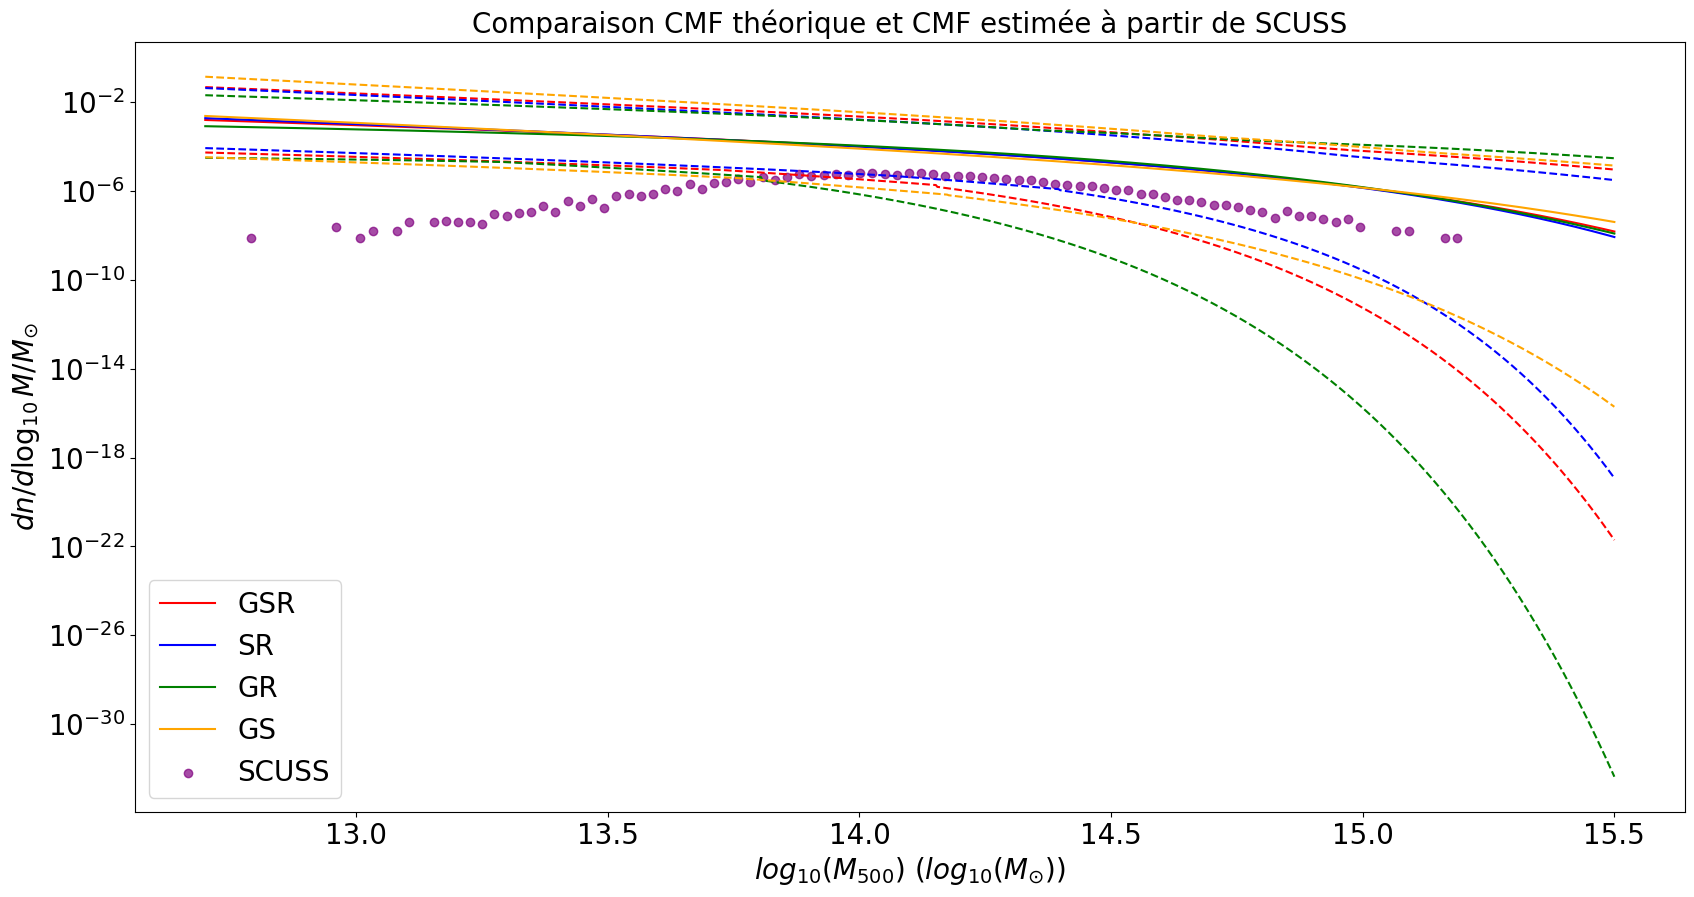

In [33]:
# Mpc ^-3 dex -1
fig = plt.figure(figsize=(20, 10))

plt.plot(log10_M_Msun, CMF_GSR, label='GSR', color='red')
plt.plot(log10_M_Msun, Borne_min_CMF_GSR, color='red',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GSR, color='red',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_SR, label='SR', color='blue')
plt.plot(log10_M_Msun, Borne_min_CMF_SR, color='blue',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_SR, color='blue',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_GR, label='GR', color='green')
plt.plot(log10_M_Msun, Borne_min_CMF_GR, color='green',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GR, color='green',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_GS, label='GS', color='orange')
plt.plot(log10_M_Msun, Borne_min_CMF_GS, color='orange',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GS, color='orange',linestyle='dashed')

plt.scatter(bin_centers, n_SCUSS, color='purple', label='SCUSS', alpha=0.7)

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$dn / d\log_{10} M / M_{\odot}$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de SCUSS')
plt.legend()

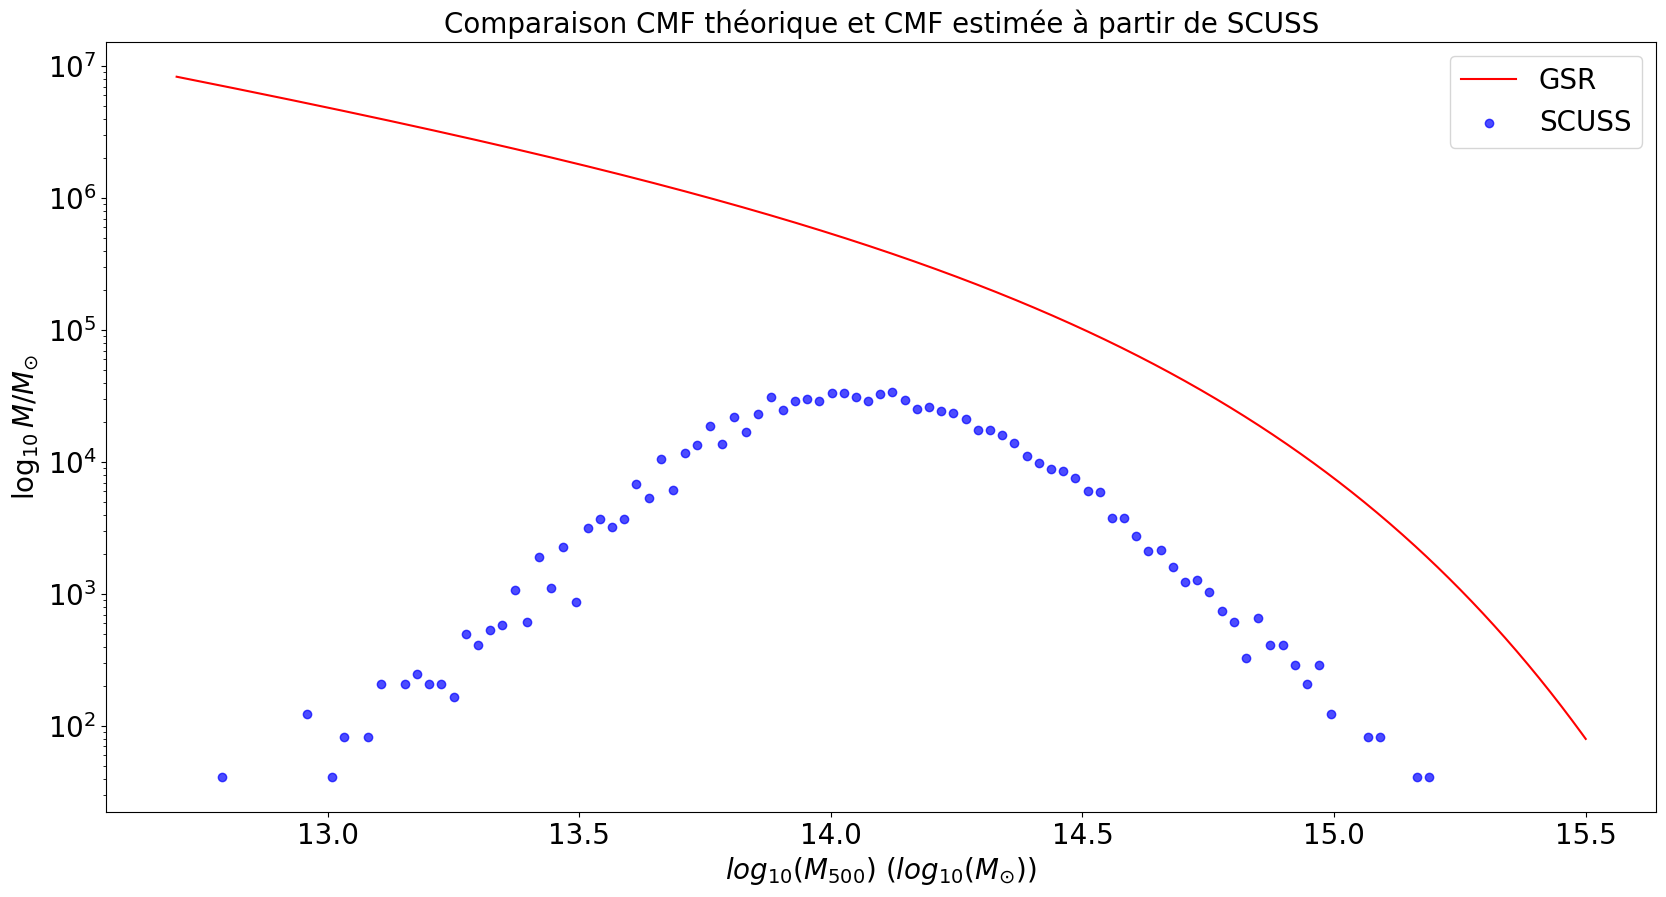

In [34]:
# dex ^-1

fig = plt.figure(figsize=(20, 10))
plt.plot(log10_M_Msun, CMF_GSR*volume_SCUSS, label='GSR', color='red')
plt.scatter(bin_centers, counts/bin_width_SCUSS, color='blue', label='SCUSS', alpha=0.7)
plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$\log_{10} M / M_{\odot}$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de SCUSS')
plt.legend()


### Fonction de "richesse"

In [35]:
table_SCUSS 

,_RAJ2000,_DEJ2000,Name,RAJ2000,DEJ2000,zph,zsp,zphmedian,N1Mpc,L1Mpc,Richness,M500,recno,z,z_bin
0,0.00035,13.02347,0,0.00035,13.02347,0.3769,0.00000,0.38710,24,7.00224,22.90440,1.26,1,0.37690,1
1,0.00635,2.95542,1,0.00635,2.95542,0.4571,0.42290,0.43890,17,6.56276,23.13604,1.27,2,0.42290,2
2,0.00958,5.28826,2,0.00958,5.28826,0.1734,0.16936,0.17750,58,14.09044,35.83500,2.04,3,0.16936,0
3,0.01474,31.78564,3,0.01474,31.78564,0.0824,0.00000,0.10490,64,12.95997,25.62747,1.42,4,0.08240,0
4,0.01476,8.94881,4,0.01476,8.94881,0.2609,0.00000,0.27620,26,8.83946,24.11363,1.33,5,0.26090,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19605,359.97270,13.33689,19605,359.97270,13.33689,0.2360,0.24498,0.23050,24,6.31375,14.90396,0.79,19606,0.24498,0
19606,359.98382,3.48642,19606,359.98382,3.48642,0.5132,0.00000,0.51320,20,8.83291,40.95954,2.35,19607,0.51320,2
19607,359.98503,-3.43589,19607,359.98503,-3.43589,0.3251,0.00000,0.32065,26,8.59997,26.87073,1.49,19608,0.32510,1
19608,359.98757,8.56171,19608,359.98757,8.56171,0.3556,0.00000,0.37079,14,3.79424,9.74870,0.50,19609,0.35560,1


In [36]:
table_SCUSS['z'].describe()

count    19610.000000
mean         0.337423
std          0.117638
min          0.050300
25%          0.253015
50%          0.345500
75%          0.430773
max          0.629900
Name: z, dtype: float64

In [37]:
RL_SCUSS = table_SCUSS['Richness']

Text(0.5, 1.0, 'Histogramme des richesses des amas dans SCUSS')

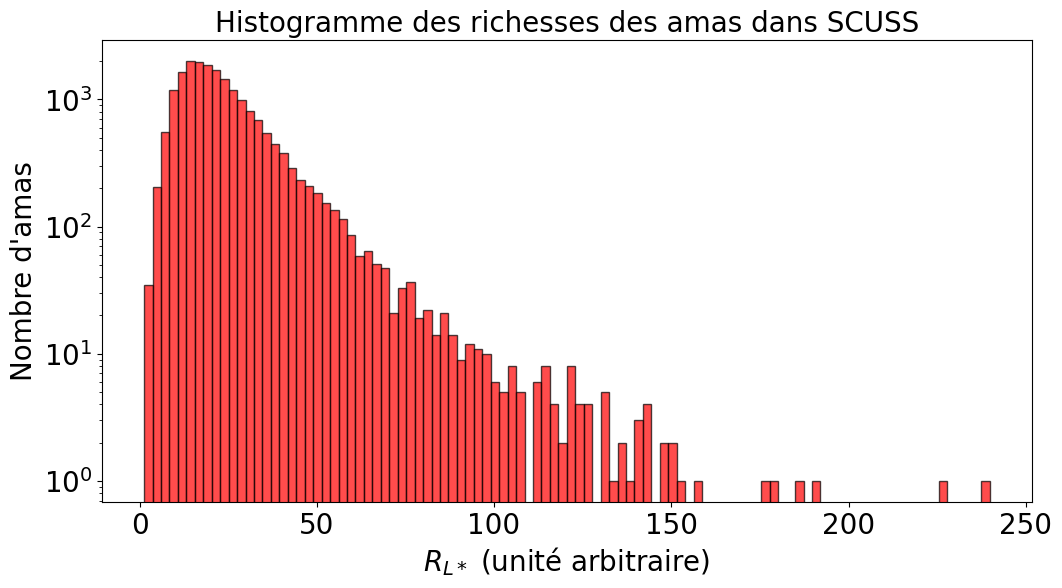

In [38]:
plt.figure(figsize=(12, 6))
plt.hist(RL_SCUSS, bins=100, color='red', edgecolor='black', alpha=0.7)
plt.xlabel(r'$R_{L*}$ (unité arbitraire)') 
plt.ylabel('Nombre d\'amas')
plt.yscale('log')
plt.title('Histogramme des richesses des amas dans SCUSS')

In [39]:
counts_RL, bin_edges_RL = np.histogram(RL_SCUSS, bins=100)
bin_centers_RL = 0.5 * (bin_edges_RL[:-1] + bin_edges_RL[1:]) # Calculate bin centers
cloud_of_points_RL = list(zip(bin_centers_RL, counts_RL)) # Pair counts with bin centers
# cloud_of_points is now a list of (mass, count) pair

bin_widths_SCUSS_RL = np.diff(bin_edges_RL)
bin_width_SCUSS_RL = bin_widths_SCUSS_RL[0] # la largeur d'un bin est toujours la même ici
print("Bin width RL :", bin_width_SCUSS_RL) 

n_SCUSS_RL = (counts_RL/bin_width_SCUSS_RL)/volume_SCUSS


Bin width RL : 2.3848826


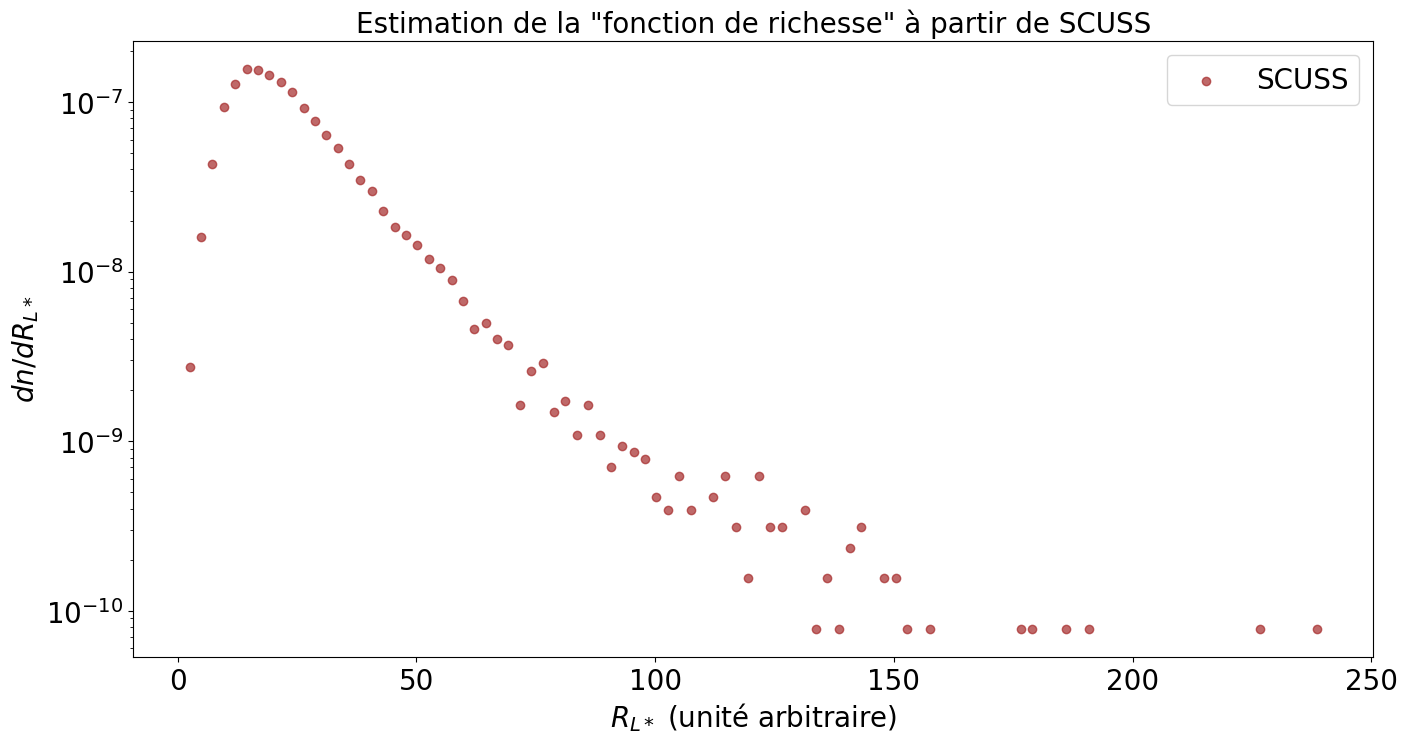

In [40]:
fig = plt.figure(figsize=(16, 8))
plt.scatter(bin_centers_RL, n_SCUSS_RL, color='brown', label='SCUSS', alpha=0.7) 
plt.xlabel(r'$R_{L*}$ (unité arbitraire)')
plt.ylabel(r'$dn / dR_{L*}$')
plt.yscale('log')
plt.title(r'Estimation de la "fonction de richesse" à partir de SCUSS')
plt.legend()

In [41]:
'''array_L1MPC_SCUSS = np.linspace(np.min(Lapp_SCUSS), np.max(L1MPC_SCUSS), 1000)
array_log10_M_Msun_from_L1MPC_SCUSS = L_app_to_log10_M_Msun(array_L1MPC_SCUSS, z ???) # ← problème !!! : On doit prendre compte le z pour passer de L1MPc à M500 ...'''

'array_L1MPC_SCUSS = np.linspace(np.min(Lapp_SCUSS), np.max(L1MPC_SCUSS), 1000)\narray_log10_M_Msun_from_L1MPC_SCUSS = L_app_to_log10_M_Msun(array_L1MPC_SCUSS, z ???) # ← problème !!! : On doit prendre compte le z pour passer de L1MPc à M500 ...'

In [42]:
array_RL_SCUSS = np.linspace(np.min(RL_SCUSS), np.max(RL_SCUSS), 1000) # RL

CRF_MRP_GSR_func = CRF_MRP(params_GSR) # "CRF" pour Cluster Richness Function → MRP car tirée de la CMF MRP 
CRF_MRP_SR_func = CRF_MRP(params_SR)
CRF_MRP_GR_func = CRF_MRP(params_GR)
CRF_MRP_GS_func = CRF_MRP(params_GS)

CRF_MRP_GSR_result = CRF_MRP_GSR_func(array_RL_SCUSS)
CRF_MRP_GSR = CRF_MRP_GSR_result[0]
CMF_GSR_from_RL_SCUSS_min = CRF_MRP_GSR_result[1]
CMF_GSR_from_RL_SCUSS_max = CRF_MRP_GSR_result[2]

'''
CMF_SR_from_RL_SCUSS = CMF_SR_func(array_log10_M_Msun_from_RL_SCUSS)
CMF_SR_from_RL_SCUSS_min = CMF_SR_func(min_array_log10_M_Msun_from_RL_SCUSS)
CMF_SR_from_RL_SCUSS_max = CMF_SR_func(max_array_log10_M_Msun_from_RL_SCUSS)

CMF_GR_from_RL_SCUSS = CMF_GR_func(array_log10_M_Msun_from_RL_SCUSS)
CMF_GR_from_RL_SCUSS_min = CMF_GR_func(min_array_log10_M_Msun_from_RL_SCUSS)
CMF_GR_from_RL_SCUSS_max = CMF_GR_func(max_array_log10_M_Msun_from_RL_SCUSS)

CMF_GS_from_RL_SCUSS = CMF_GS_func(array_log10_M_Msun_from_RL_SCUSS)
CMF_GS_from_RL_SCUSS_min = CMF_GS_func(min_array_log10_M_Msun_from_RL_SCUSS)
CMF_GS_from_RL_SCUSS_max = CMF_GS_func(max_array_log10_M_Msun_from_RL_SCUSS)'''


'\nCMF_SR_from_RL_SCUSS = CMF_SR_func(array_log10_M_Msun_from_RL_SCUSS)\nCMF_SR_from_RL_SCUSS_min = CMF_SR_func(min_array_log10_M_Msun_from_RL_SCUSS)\nCMF_SR_from_RL_SCUSS_max = CMF_SR_func(max_array_log10_M_Msun_from_RL_SCUSS)\n\nCMF_GR_from_RL_SCUSS = CMF_GR_func(array_log10_M_Msun_from_RL_SCUSS)\nCMF_GR_from_RL_SCUSS_min = CMF_GR_func(min_array_log10_M_Msun_from_RL_SCUSS)\nCMF_GR_from_RL_SCUSS_max = CMF_GR_func(max_array_log10_M_Msun_from_RL_SCUSS)\n\nCMF_GS_from_RL_SCUSS = CMF_GS_func(array_log10_M_Msun_from_RL_SCUSS)\nCMF_GS_from_RL_SCUSS_min = CMF_GS_func(min_array_log10_M_Msun_from_RL_SCUSS)\nCMF_GS_from_RL_SCUSS_max = CMF_GS_func(max_array_log10_M_Msun_from_RL_SCUSS)'

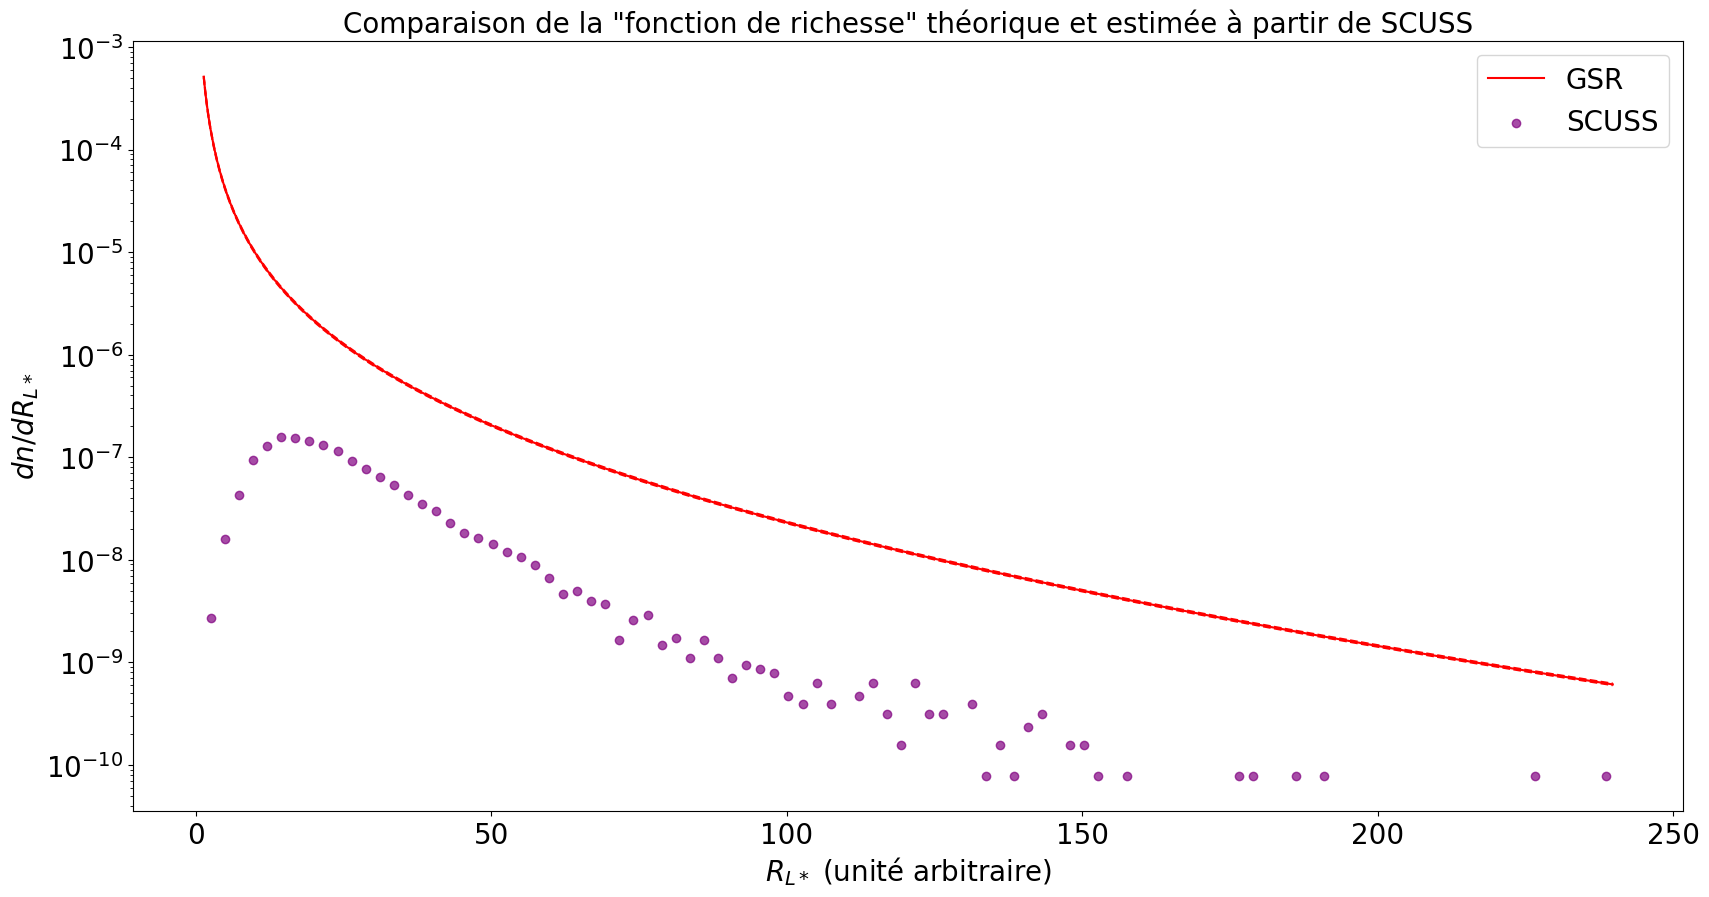

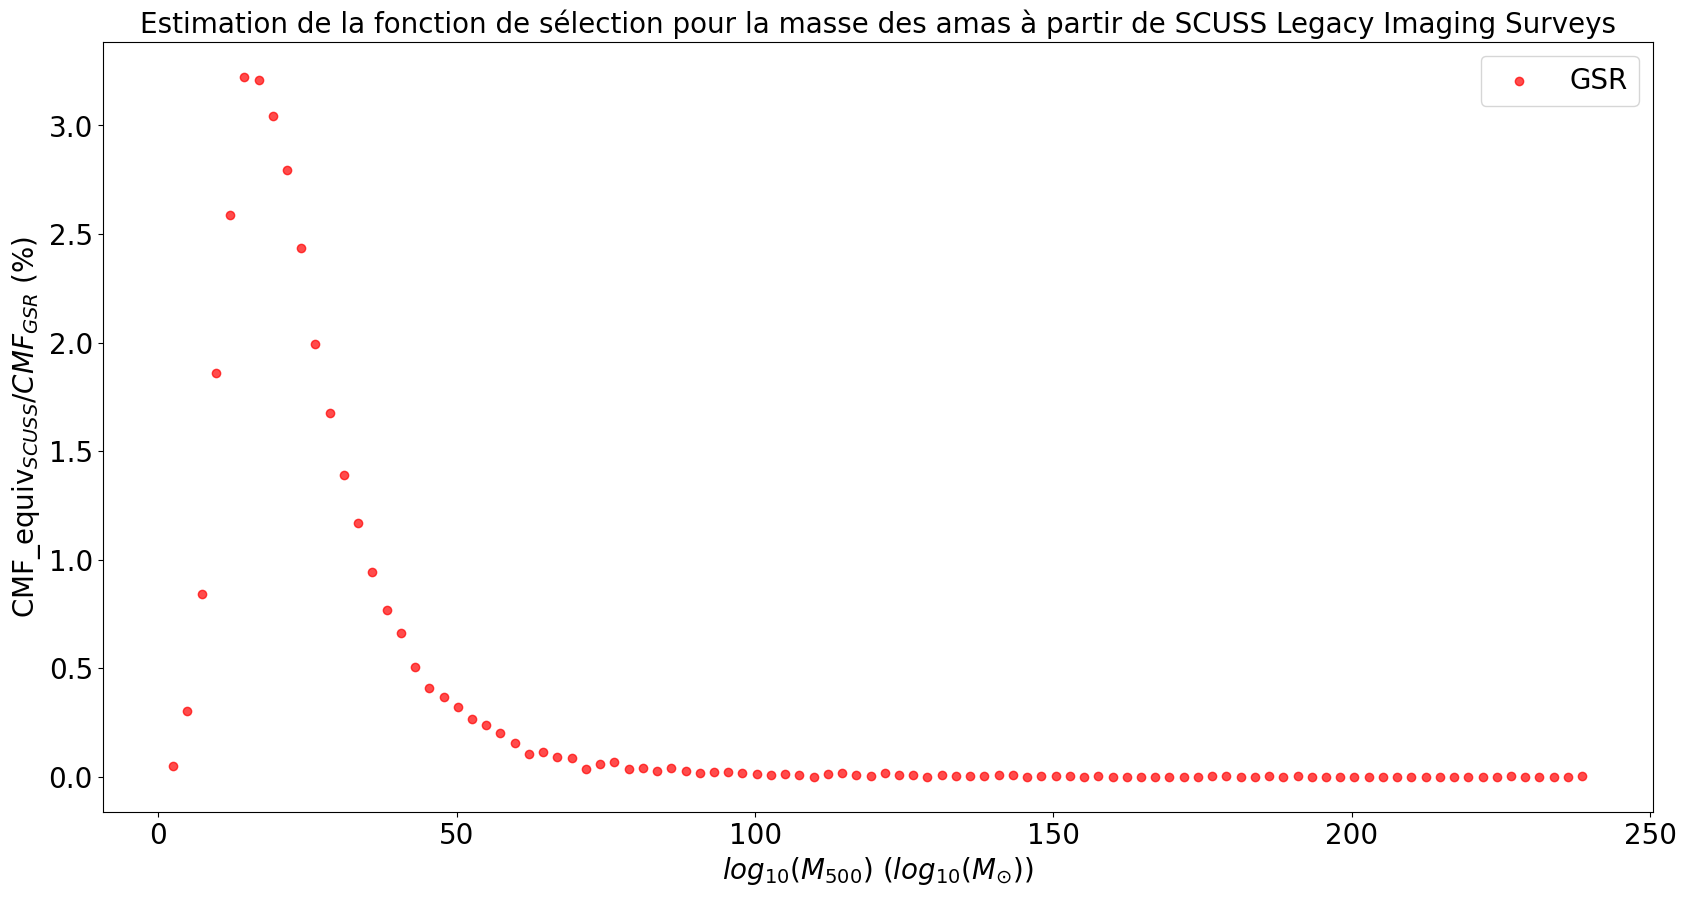

In [43]:
# Mpc ^-3 dex -1

fig1 = plt.figure(figsize=(20, 10))

plt.plot(array_RL_SCUSS, CRF_MRP_GSR, label='GSR', color='red')
plt.plot(array_RL_SCUSS, CMF_GSR_from_RL_SCUSS_min, color='red',linestyle='dashed')
plt.plot(array_RL_SCUSS, CMF_GSR_from_RL_SCUSS_max, color='red',linestyle='dashed')



plt.scatter(bin_centers_RL, n_SCUSS_RL, color='purple', label='SCUSS', alpha=0.7)

plt.xlabel(r'$R_{L*}$ (unité arbitraire)',fontsize=20)
plt.ylabel(r'$dn / dR_{L*}$',fontsize=20)
plt.tick_params(axis='both', labelsize=20)
plt.yscale('log')
plt.title(r'Comparaison de la "fonction de richesse" théorique et estimée à partir de SCUSS',fontsize=20)

plt.legend(fontsize=20)

bin_centers_log10_M_Msun_from_RL_SCUSS = RL_to_log10_M_Msun(bin_centers_RL)[0]
CRF_MRP_GSR_result_bin_centers = CRF_MRP_GSR_func(bin_centers_log10_M_Msun_from_RL_SCUSS)
CRF_MRP_GSR_bin_centers = CRF_MRP_GSR_result_bin_centers[0]
CMF_GSR_from_RL_SCUSS_min_bin_centers = CRF_MRP_GSR_result_bin_centers[1]
CMF_GSR_from_RL_SCUSS_max_bin_centers = CRF_MRP_GSR_result_bin_centers[2]

estimation_selection_function_RL_SCUSS_GSR = n_SCUSS_RL/CRF_MRP_GSR_bin_centers

plt.figure(figsize=(20, 10))

plt.scatter(bin_centers_RL, estimation_selection_function_RL_SCUSS_GSR * 100, color='red', alpha=0.7,label='GSR')
'''plt.scatter(bin_centers, estimation_selection_function_masse_SR * 100, color='blue', alpha=0.7,label='SR')
plt.scatter(bin_centers, estimation_selection_function_masse_GR * 100, color='green', alpha=0.7,label='GR')
plt.scatter(bin_centers, estimation_selection_function_masse_GS * 100, color='orange', alpha=0.7,label='GS')'''

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'CMF_equiv$_{SCUSS} / CMF_{GSR}$ (%)')
plt.title('Estimation de la fonction de sélection pour la masse des amas à partir de SCUSS Legacy Imaging Surveys')

plt.legend()

### Fonction de luminosité

#### L1Mpc - Luminosité absolue en bande r

Bin width L1Mpc: 0.3860154
Bin width log10(L1Mpc): 0.014715418121722834


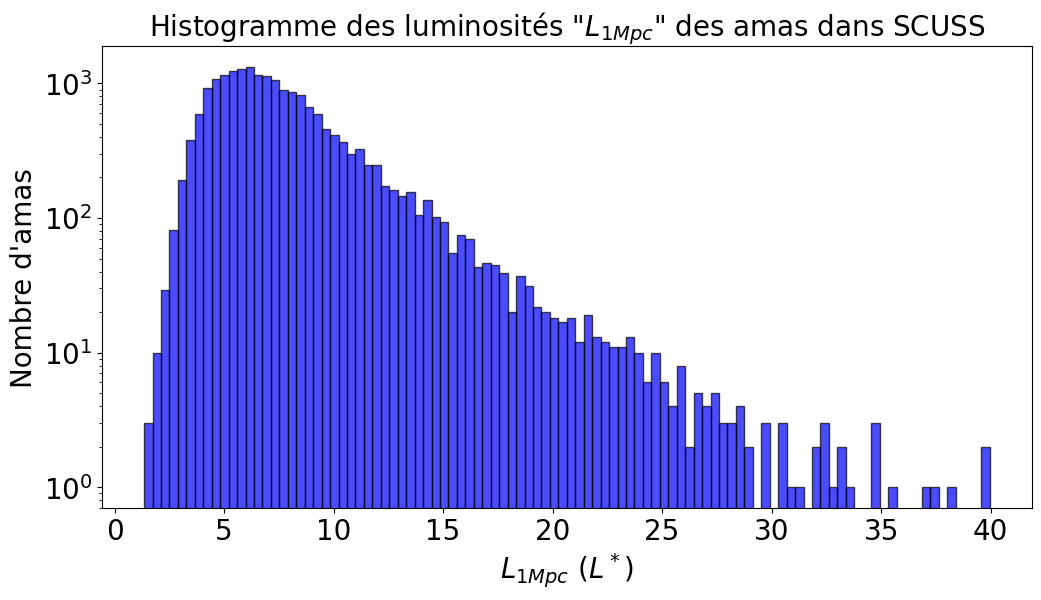

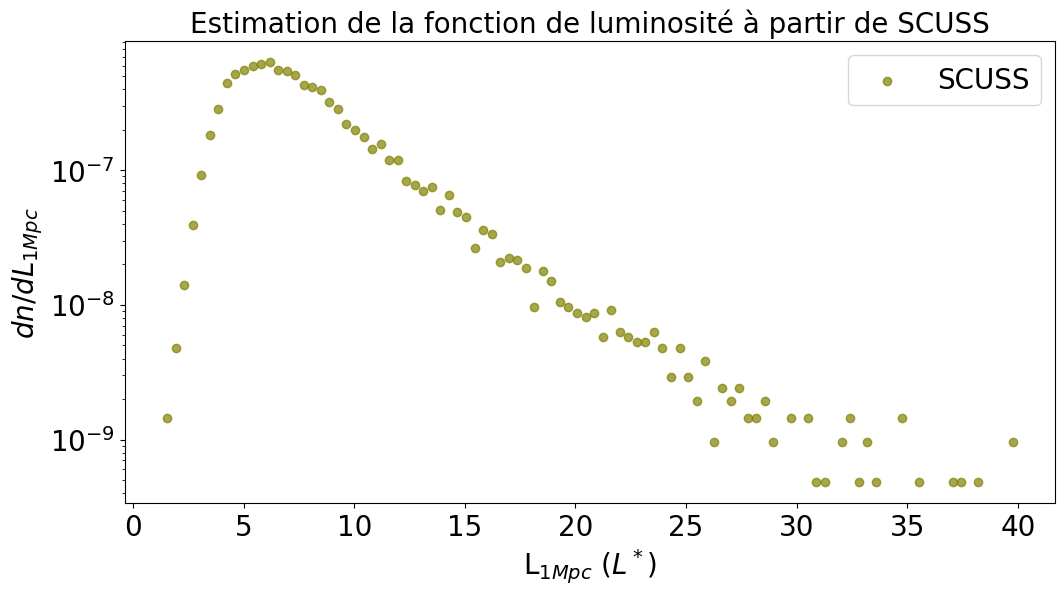

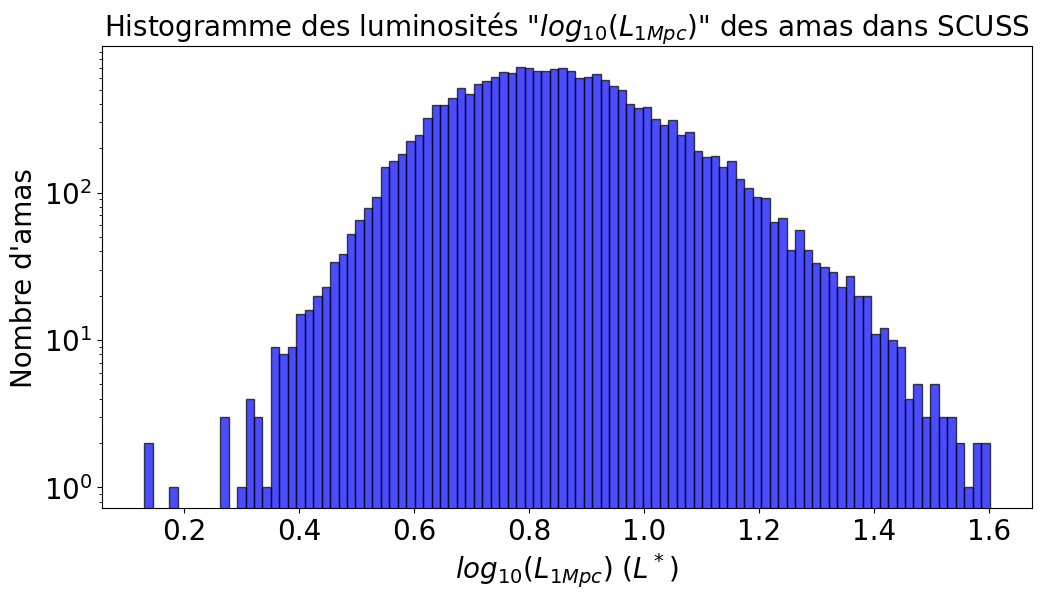

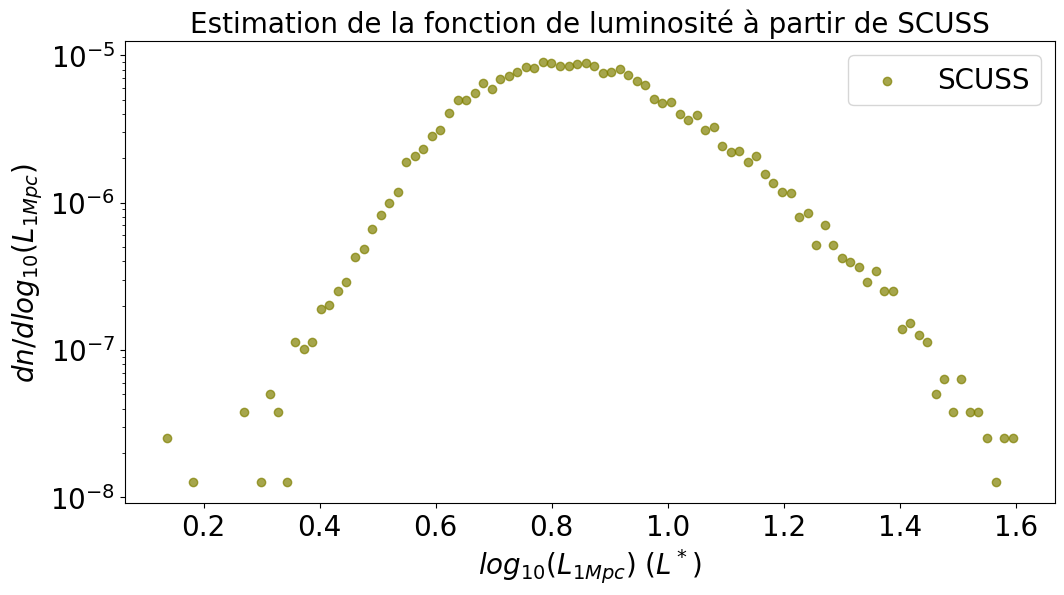

In [44]:
# Données SCUSS : L1Mpc :

L1MPC_SCUSS = table_SCUSS['L1Mpc'] # Gao et al. 2019, section 3.3 : "L1Mpc is the total r-band luminosity of cluster members within a distance of 1 Mpc from the BCG"
log10_L1MPC_SCUSS = np.log10(L1MPC_SCUSS) # Calcul possible car L1Mpc est adimensionné (exprimé en unités de L*, lumisnoisté de référence d'une galaxie)


# L1Mpc
plt.figure(figsize=(12, 6))
plt.hist(L1MPC_SCUSS, bins=100, color='blue', edgecolor='black', alpha=0.7)
plt.xlabel(r'$L_{1Mpc}$ ($L^*$)') 
plt.ylabel('Nombre d\'amas')
plt.yscale('log')
plt.title(r'Histogramme des luminosités "$L_{1Mpc}$" des amas dans SCUSS')


counts_L1Mpc, bin_edges_L1Mpc = np.histogram(L1MPC_SCUSS, bins=100)
bin_centers_L1Mpc = 0.5 * (bin_edges_L1Mpc[:-1] + bin_edges_L1Mpc[1:]) # Calculate bin centers
cloud_of_points_L1Mpc = list(zip(bin_centers_L1Mpc, counts_L1Mpc)) # Pair counts with bin centers
# cloud_of_points is now a list of (mass, count) pair

bin_widths_SCUSS_L1Mpc = np.diff(bin_edges_L1Mpc)
bin_width_SCUSS_L1Mpc = bin_widths_SCUSS_L1Mpc[0] # la largeur d'un bin est toujours la même ici
print("Bin width L1Mpc:", bin_width_SCUSS_L1Mpc) 

n_SCUSS_L1Mpc = (counts_L1Mpc/bin_width_SCUSS_L1Mpc)/volume_SCUSS

fig = plt.figure(figsize=(12, 6))
plt.scatter(bin_centers_L1Mpc, n_SCUSS_L1Mpc, color='olive', label='SCUSS', alpha=0.7) 
plt.xlabel(r'L$_{1Mpc}$ ($L^*$)')
plt.ylabel(r'$dn / dL_{1Mpc}$')
plt.yscale('log')
plt.title(r'Estimation de la fonction de luminosité à partir de SCUSS')
plt.legend()



# log10(L1Mpc)
plt.figure(figsize=(12, 6))
plt.hist(log10_L1MPC_SCUSS, bins=100, color='blue', edgecolor='black', alpha=0.7)
plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)') 
plt.ylabel('Nombre d\'amas')
plt.yscale('log')
plt.title(r'Histogramme des luminosités "$log_{10}(L_{1Mpc})$" des amas dans SCUSS')


counts_L1Mpc_log10, bin_edges_L1Mpc_log10 = np.histogram(log10_L1MPC_SCUSS, bins=100)
bin_centers_L1Mpc_log10 = 0.5 * (bin_edges_L1Mpc_log10[:-1] + bin_edges_L1Mpc_log10[1:]) # Calculate bin centers
cloud_of_points_L1Mpc_log10 = list(zip(bin_centers_L1Mpc_log10, counts_L1Mpc_log10)) # Pair counts with bin centers
# cloud_of_points is now a list of (mass, count) pair

bin_widths_SCUSS_L1Mpc_log10 = np.diff(bin_edges_L1Mpc_log10)
bin_width_SCUSS_L1Mpc_log10 = bin_widths_SCUSS_L1Mpc_log10[0] # la largeur d'un bin est toujours la même ici
print("Bin width log10(L1Mpc):", bin_width_SCUSS_L1Mpc_log10) 

n_SCUSS_L1Mpc_log10 = (counts_L1Mpc_log10/bin_width_SCUSS_L1Mpc_log10)/volume_SCUSS

fig = plt.figure(figsize=(12, 6))
plt.scatter(bin_centers_L1Mpc_log10, n_SCUSS_L1Mpc_log10, color='olive', label='SCUSS', alpha=0.7) 
plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
plt.ylabel(r'$dn / dlog_{10}(L_{1Mpc})$')
plt.yscale('log')
plt.title(r'Estimation de la fonction de luminosité à partir de SCUSS')
plt.legend()


In [45]:
bins_mean_z = [] # Je vais y placer les valeurs moyennes de z pour chaque bin de luminosité, afin de pouvoir les positionner sur l'axe des redshifts dans le graphe 3D
for i in range(len(bin_centers_L1Mpc)):
    current_table_SCUSS = table_SCUSS[
        (table_SCUSS['L1Mpc'] >= bin_edges_L1Mpc[i]) &
        (table_SCUSS['L1Mpc'] < bin_edges_L1Mpc[i+1])
    ]
    current_mean_z = current_table_SCUSS['z'].mean()
    bins_mean_z.append(current_mean_z)

In [46]:
# Théorie fonction de luminosité

array_L1Mpc_SCUSS = np.linspace(np.min(L1MPC_SCUSS), np.max(L1MPC_SCUSS), 100) # L1Mpc
array_log10_L1Mpc_SCUSS = np.log10(array_L1Mpc_SCUSS) 
array_z = np.array([0.1,0.2,0.3,0.4,0.5,0.6]) # On va faire plusieurs tracés en fonction de plusieurs redshifts
array_z_3D = np.linspace(bornes_z[0], bornes_z[1], 1000) # Pour le graphe 3D

# On va passer de L1Mpc à log10(M/Msun) : cependant ce calcul dépend du redshift, on va donc faire plusieurs tracés en fonction de plusieurs redshifts puis on fera un graphe 3D : x = L1Mpc, y = redshift, z = dn/dL1Mpc(L1Mpc,z)

'''
# L1_Mpc → log10(M/Msun) : 
matrix_log10_M_Msun_from_L1Mpc_SCUSS = L1Mpc_to_log10_M_Msun(array_L1Mpc_SCUSS, array_z) # Lignes : valeurs de z fixés ; Colonnes : valeurs de L1Mpc fixées

# log10(M/Msun) → dn/dL1Mpc
CMF_GSR_from_L1Mpc_SCUSS = [] # On va stocker les valeurs de la CMF pour chaque redshift
for array__log10_M_sun__fixed_z in matrix_log10_M_Msun_from_L1Mpc_SCUSS:
    CMF_GSR_from_L1Mpc_SCUSS.append(CMF_GSR_func(array__log10_M_sun__fixed_z))
'''

# Calcul de (dn /dlog10(L1Mpc))(log10(L1Mpc)) 
# 2D
CLF_log10_MRP_GSR_func = CLF_log10_MRP(params_GSR,array_z)
CLF_log10_MRP_GSR_result = CLF_log10_MRP_GSR_func(array_log10_L1Mpc_SCUSS)
CLF_log10_MRP_GSR = CLF_log10_MRP_GSR_result[0]
CLF_log10_MRP_GSR_from_min = CLF_log10_MRP_GSR_result[1] # on calcule popur la valeur minimale de log10(L1Mpc) autorisée par la dispersion de la relation de scaling
CLF_log10_MRP_GSR_from_max = CLF_log10_MRP_GSR_result[2] # idem mais pour la valeur max

#3D
CLF_log10_MRP_GSR_func_3D = CLF_log10_MRP(params_GSR,array_z_3D)
CLF_log10_MRP_GSR_result_3D = CLF_log10_MRP_GSR_func_3D(array_log10_L1Mpc_SCUSS)
CLF_log10_MRP_GSR_3D = CLF_log10_MRP_GSR_result_3D[0]


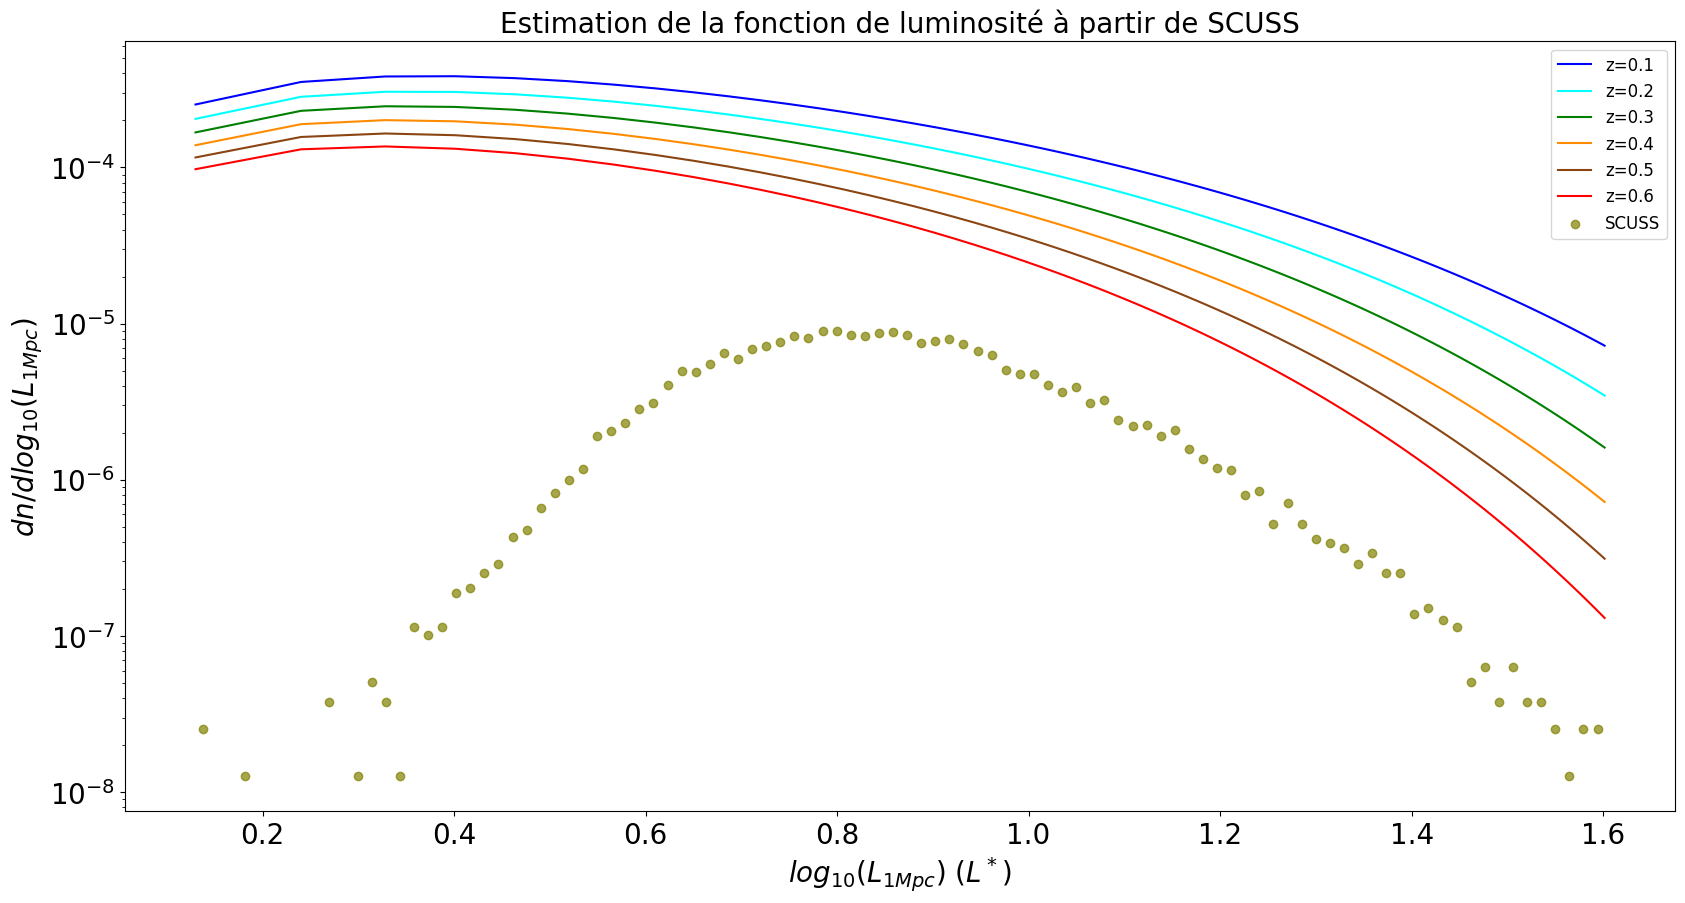

In [47]:
# Mpc ^-3 dex -1

fig1 = plt.figure(figsize=(20, 10))

for i, z in enumerate(array_z): # On plot dn/dL1Mpc pour chaque redshift
    plt.plot(
        array_log10_L1Mpc_SCUSS,
        CLF_log10_MRP_GSR[i], # Pour le ième redshift de array_z
        label=f'z={z}',
        color=cmap_blue2red(i / (len(array_z) - 1)) # i / (len(array_z) - 1) → i normalisé entre 0 et 1 pour le colormap
    )

plt.scatter(bin_centers_L1Mpc_log10, n_SCUSS_L1Mpc_log10, color='olive', label='SCUSS', alpha=0.7)


plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
plt.ylabel(r'$dn / dlog_{10}(L_{1Mpc})$')
plt.yscale('log')
plt.title(r'Estimation de la fonction de luminosité à partir de SCUSS')
plt.legend(fontsize=12)

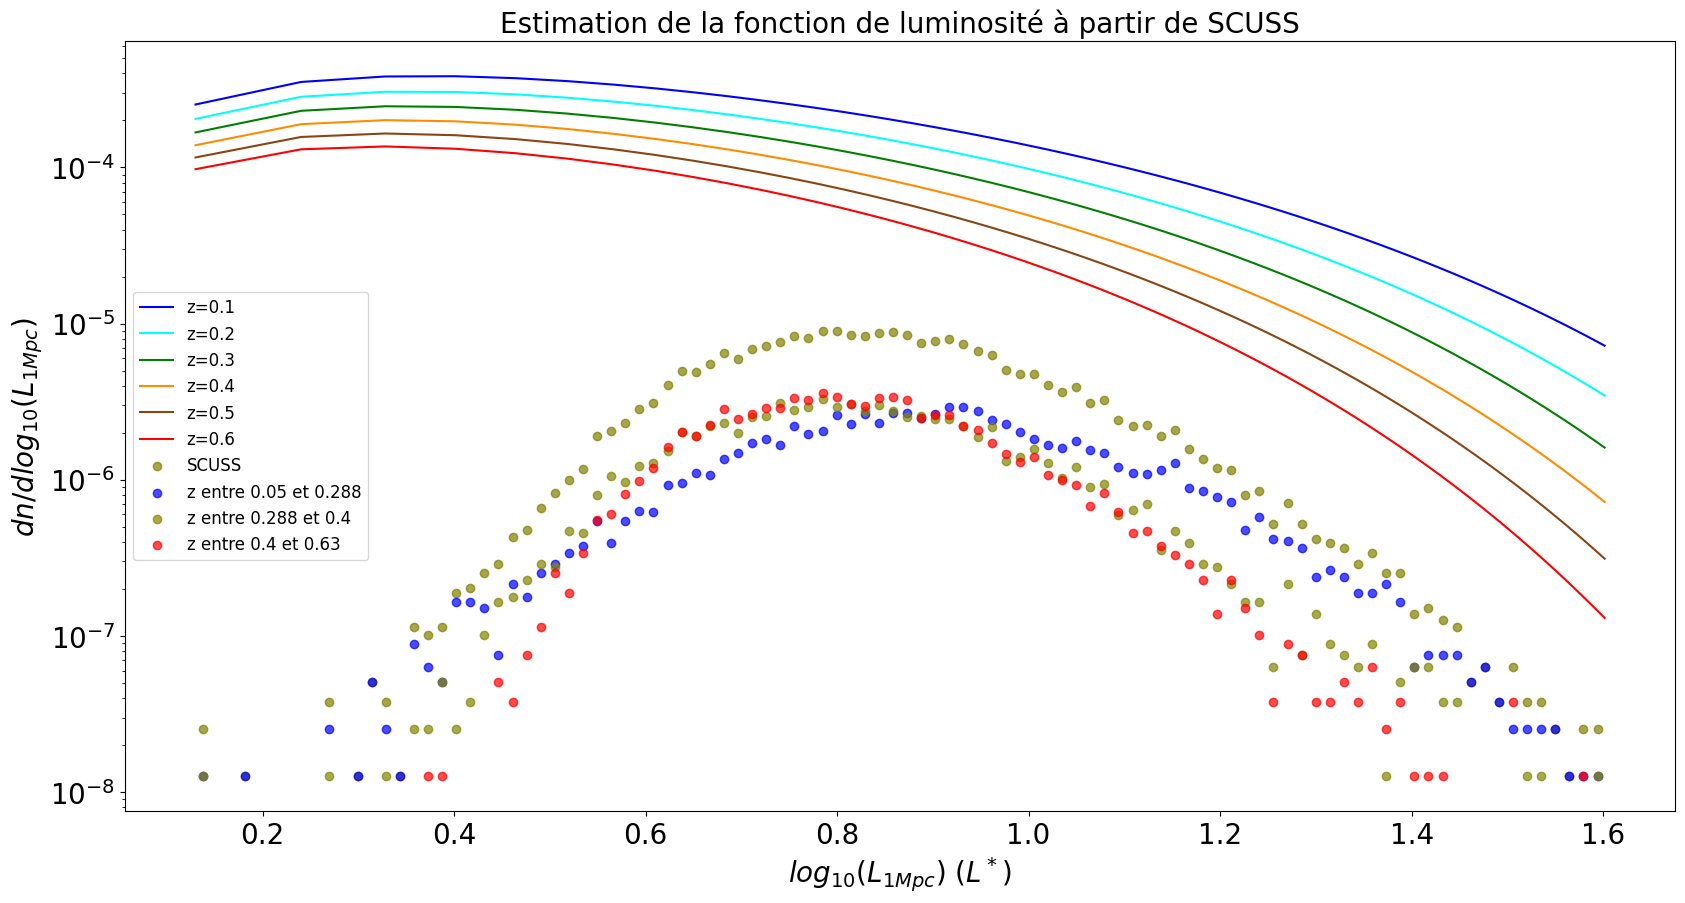

In [48]:
# On fait comme précedemment, mais en s'intéressant aux différents bins de redshift
fig2 = plt.figure(figsize=(20, 10))
#théorie
for i, z in enumerate(array_z): # On plot dn/dL1Mpc pour chaque redshift
    plt.plot(
        array_log10_L1Mpc_SCUSS,
        CLF_log10_MRP_GSR[i], # Pour le ième redshift de array_z
        label=f'z={z}',
        color=cmap_blue2red(i / (len(array_z) - 1)) # i / (len(array_z) - 1) → i normalisé entre 0 et 1 pour le colormap
    )

plt.scatter(bin_centers_L1Mpc_log10, n_SCUSS_L1Mpc_log10, color='olive', label='SCUSS', alpha=0.7)
#données
for i,subtable in enumerate(subtables_z_SCUSS):
    L1MPC_subtable = subtable['L1Mpc']
    log10_L1MPC_subtable = np.log10(L1MPC_subtable)
    
    counts_log10_L1Mpc_subtable, bin_edges_log10_L1Mpc_subtable = np.histogram(log10_L1MPC_subtable,
                                                                                bins=100,
                                                                                range=[np.log10(table_SCUSS['L1Mpc'].min()), np.log10(table_SCUSS['L1Mpc'].max())])
    bin_centers_log10_L1Mpc_subtable = 0.5 * (bin_edges_log10_L1Mpc_subtable[:-1] + bin_edges_log10_L1Mpc_subtable[1:]) # Calculate bin centers
    n_SCUSS_log10_L1Mpc_subtable = (counts_log10_L1Mpc_subtable / bin_width_SCUSS_L1Mpc_log10) / volume_SCUSS
    
    plt.scatter(bin_centers_log10_L1Mpc_subtable,
                n_SCUSS_log10_L1Mpc_subtable,
                label=f'z entre {round(bornes_z_SCUSS[i],3)} et {round(bornes_z_SCUSS[i+1],3)}', 
                color=cmap_blue2red(i / (len(subtables_z_SCUSS) - 1)),
                alpha=0.7,
                )
plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
plt.ylabel(r'$dn / dlog_{10}(L_{1Mpc})$')
plt.yscale('log')
plt.title(r'Estimation de la fonction de luminosité à partir de SCUSS')
plt.legend(fontsize=12)
#faire idem en Lapp

Pour le code ci-dessous, ajouter la commande magic "%matplotlib widget" pour rendre le graphe 3D interactif : attention cela fonctionnera pour tout les plots, on doit l'enlever de la cellule et restart le kernel pour revenir à la normale.

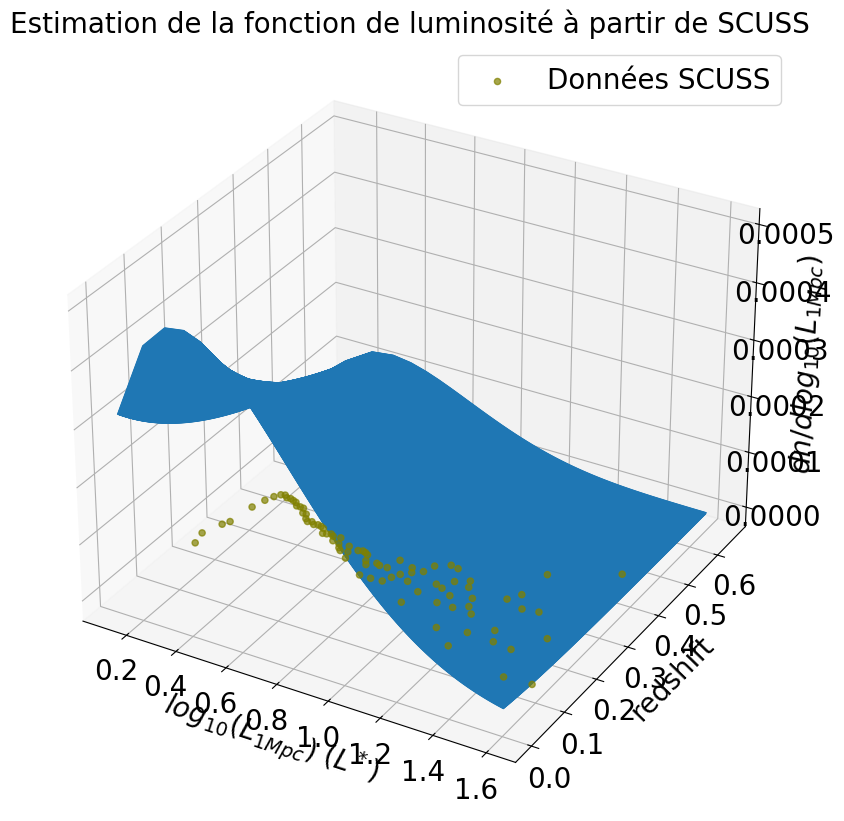

In [49]:
# Idem en 3D

fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot(111, projection='3d')

for i, z in enumerate(array_z_3D): # On plot dn/dL1Mpc pour chaque redshift
    ax.plot(
        array_log10_L1Mpc_SCUSS,
        array_z_3D[i], # Pour le ième redshift de array_z_3D
        CLF_log10_MRP_GSR_3D[i], # idem
        color='tab:blue'
        #label="Courbes de la fonction de luminosité théorique tirée de la CMF MRP"
    )

ax.scatter(bin_centers_L1Mpc_log10, bins_mean_z, n_SCUSS_L1Mpc_log10, color='olive', alpha=0.7, label='Données SCUSS') # !!! Pour chaque bin de luminosité, on place la valeur MOYENNE de z : est-ce pertinent ?

#ax.scatter(array_log10_L1Mpc_SCUSS, array_z_3D, CLF_log10_MRP_GSR_3D, cmap='viridis', marker='o')  # c=C pour colorer selon dn/d(log10(M/Msun))
# ajouter les points des données ; réduire l'axe des z à 100
'''
ax.set_zscale('log')
ax.set_zlim(1e-9, 1e-2)  # Adjust these values to fit your data'''

ax.set_xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
ax.set_ylabel('redshift')
ax.set_zlabel(r'$dn / dlog_{10}(L_{1Mpc})$')
ax.legend()
plt.title('Estimation de la fonction de luminosité à partir de SCUSS')
plt.show()

#### Luminosité apparente

In [50]:
# On va ajouter une colonne Lapp à la table SCUSS : il va s'agir de la luminosité apparente tirée de L1Mpc et de la distance lumineuse tirée de du redshift (pour les paramètres cosmologiques de Planck 2018)
Lapp_SCUSS = []
for idx, row in table_SCUSS.iterrows():
    L1Mpc = row['L1Mpc']
    z = row['z']
    DL = (cosmo.luminosity_distance(z).value)*1e6  # Calcul de la distance lumineuse en pc
    Lapp = ((10/DL)**2) * L1Mpc  # Conversion de L1Mpc à Lapp
    Lapp_SCUSS.append(Lapp) # On obtient une lumisnsoité apparente en unités de L* : à voir si il vaut mieux passer en unités SI ou autre par la suite

log10_Lapp_SCUSS = np.log10(Lapp_SCUSS)  

table_SCUSS['Lapp'] = Lapp_SCUSS

# On le fait aussi pour chaque sous-table de de SCUSS
for subtable in subtables_z_SCUSS:
    Lapp_subtable = []
    for idx, row in subtable.iterrows():
        L1Mpc = row['L1Mpc']
        z = row['z']
        DL = (cosmo.luminosity_distance(z).value)*1e6  # Calcul de la distance lumineuse en pc
        Lapp = ((10/DL)**2) * L1Mpc  # Conversion de L1Mpc à Lapp
        Lapp_subtable.append(Lapp) # On obtient une lumisnsoité apparente en unités de L* : à voir si il vaut mieux passer en unités SI ou autre par la suite

    subtable['Lapp'] = Lapp_subtable

C:\Users\ED282972\AppData\Local\Temp\ipykernel_16740\1126148305.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subtable['Lapp'] = Lapp_subtable
C:\Users\ED282972\AppData\Local\Temp\ipykernel_16740\1126148305.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subtable['Lapp'] = Lapp_subtable
C:\Users\ED282972\AppData\Local\Temp\ipykernel_16740\1126148305.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value i

Bin width log10(Lapp): 0.0312821264112344


C:\Users\ED282972\AppData\Local\Temp\ipykernel_16740\1458322610.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


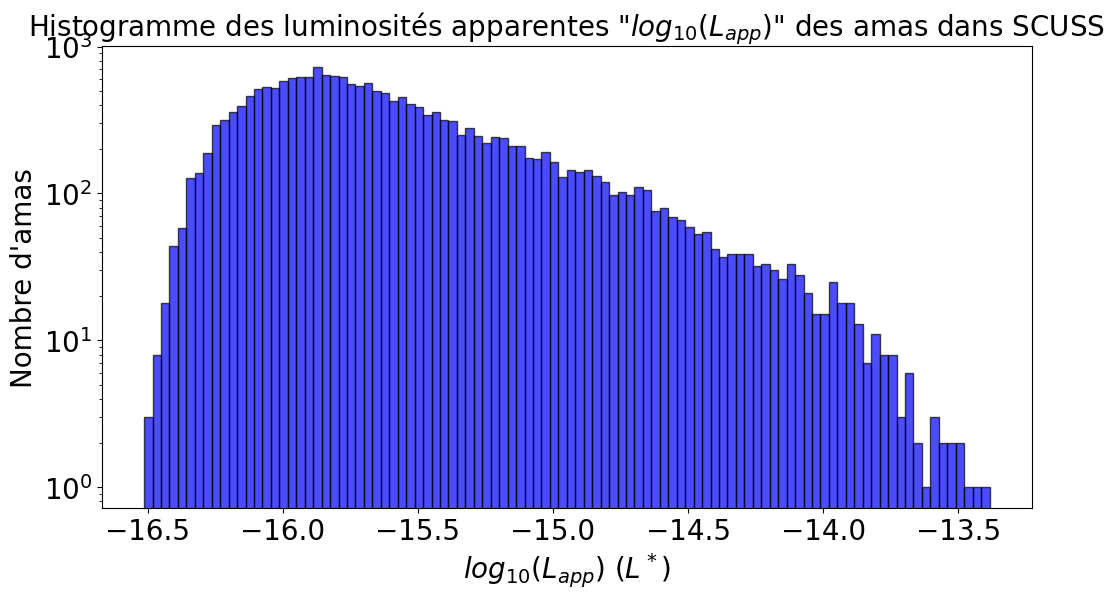

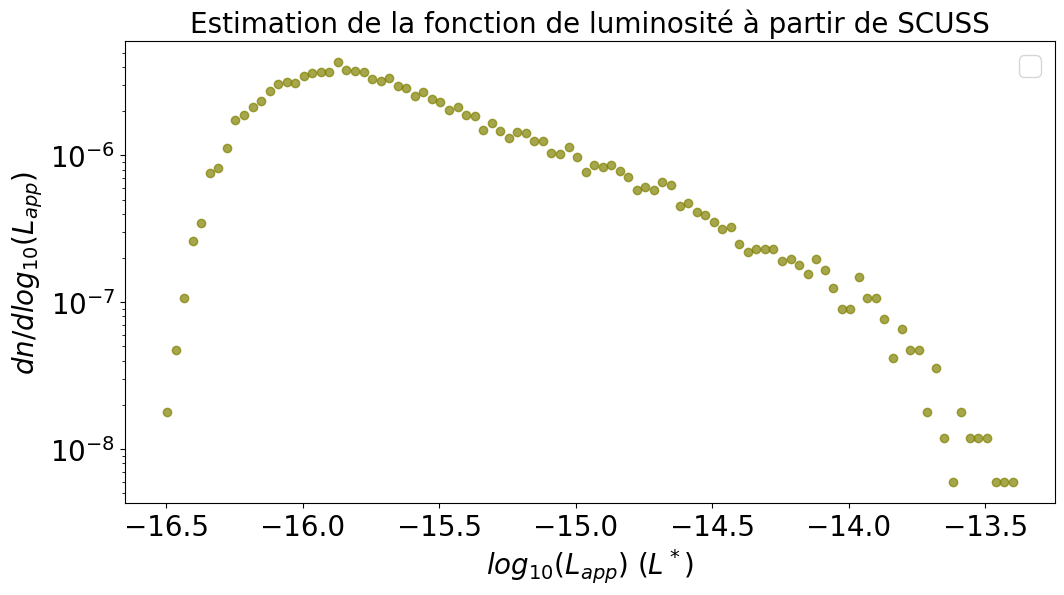

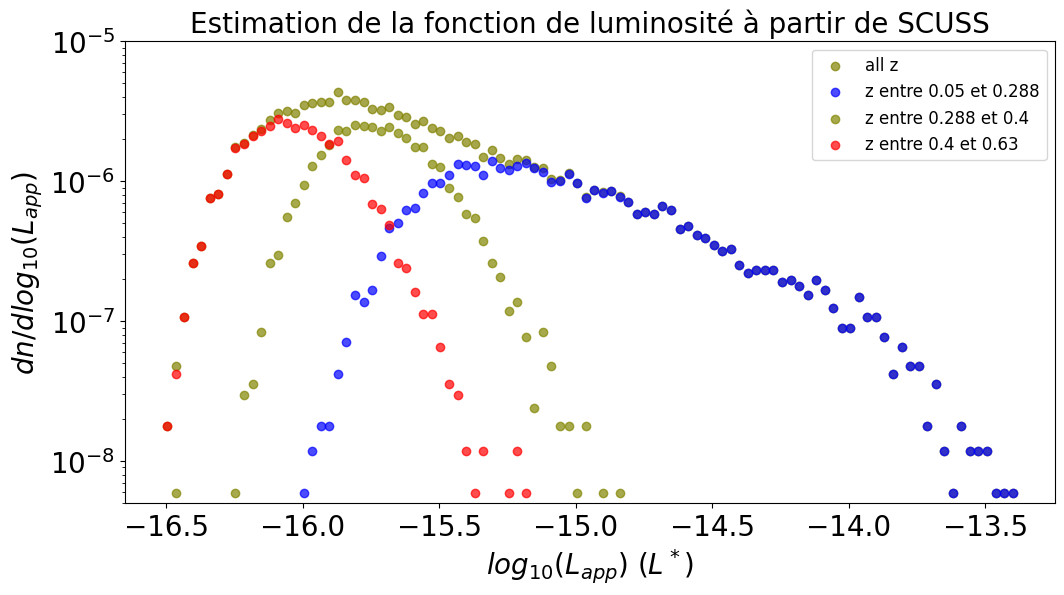

In [51]:
# log10(Lapp)
plt.figure(figsize=(12, 6))
plt.hist(log10_Lapp_SCUSS, bins=100, color='blue', edgecolor='black', alpha=0.7)
plt.xlabel(r'$log_{10}(L_{app})$ ($L^*$)') 
plt.ylabel('Nombre d\'amas')
plt.yscale('log')
plt.title(r'Histogramme des luminosités apparentes "$log_{10}(L_{app})$" des amas dans SCUSS')


counts_Lapp_log10, bin_edges_Lapp_log10 = np.histogram(log10_Lapp_SCUSS, bins=100)
bin_centers_Lapp_log10 = 0.5 * (bin_edges_Lapp_log10[:-1] + bin_edges_Lapp_log10[1:]) # Calculate bin centers
cloud_of_points_Lapp_log10 = list(zip(bin_centers_Lapp_log10, counts_Lapp_log10)) # Pair counts with bin centers
# cloud_of_points is now a list of (mass, count) pair

bin_widths_SCUSS_Lapp_log10 = np.abs(np.diff(bin_edges_Lapp_log10))
bin_width_SCUSS_Lapp_log10 = bin_widths_SCUSS_Lapp_log10[0] # la largeur d'un bin est toujours la même ici
print("Bin width log10(Lapp):", bin_width_SCUSS_Lapp_log10) 

n_SCUSS_Lapp_log10 = (counts_Lapp_log10/bin_width_SCUSS_Lapp_log10)/volume_SCUSS

fig = plt.figure(figsize=(12, 6))
plt.scatter(bin_centers_Lapp_log10, n_SCUSS_Lapp_log10, color='olive', alpha=0.7) 
#plt.ylim(0.5*1e-8,1e-5) # Bizarremment sans ça le plot n'affiche pas tout les points
plt.xlabel(r'$log_{10}(L_{app})$ ($L^*$)')
plt.ylabel(r'$dn / dlog_{10}(L_{app})$')
plt.yscale('log')
plt.title(r'Estimation de la fonction de luminosité à partir de SCUSS')
plt.legend()

fig = plt.figure(figsize=(12, 6))
plt.scatter(bin_centers_Lapp_log10, n_SCUSS_Lapp_log10, color='olive', label='all z', alpha=0.7) 
for i,subtable in enumerate(subtables_z_SCUSS):
    Lapp_subtable = subtable['Lapp']
    log10_Lapp_subtable = np.log10(Lapp_subtable)   

    counts_log10_Lapp_subtable, bin_edges_log10_Lapp_subtable = np.histogram(log10_Lapp_subtable,
                                                                            bins=100,
                                                                            range=[np.log10(table_SCUSS['Lapp'].min()), np.log10(table_SCUSS['Lapp'].max())])
    bin_centers_log10_Lapp_subtable = 0.5 * (bin_edges_log10_Lapp_subtable[:-1] + bin_edges_log10_Lapp_subtable[1:]) # Calculate bin centers
    n_SCUSS_log10_Lapp_subtable = (counts_log10_Lapp_subtable / bin_width_SCUSS_Lapp_log10) / volume_SCUSS

    plt.scatter(bin_centers_log10_Lapp_subtable,
                n_SCUSS_log10_Lapp_subtable,    
                label=f'z entre {round(bornes_z_SCUSS[i],3)} et {round(bornes_z_SCUSS[i+1],3)}',
                color=cmap_blue2red(i / (len(subtables_z_SCUSS) - 1)),
                alpha=0.7,
                )
plt.xlabel(r'$log_{10}(L_{app})$ ($L^*$)')
plt.ylabel(r'$dn / dlog_{10}(L_{app})$')
plt.yscale('log')
plt.ylim(0.5*1e-8,1e-5) # Bizarremment sans ça le plot n'affiche pas tout les points
plt.title(r'Estimation de la fonction de luminosité à partir de SCUSS')
plt.legend(fontsize=12)

### Coupure L_app

In [52]:
# A partir de dn/dlog10(Lapp) ci-dessus, on en déduit une coupure minimale de détection de cette survey en Lapp
log10_Lapp_min = -14.5 ; L_app_min = 10**log10_Lapp_min # En unités de L*
log10_Lapp_min_2 = -16.5 ; L_app_min_2 = 10**log10_Lapp_min_2 # En unités de L*


# Maintenant in va calculer la coupure en redshift associé à celle en luminosité apparente pour chaque bin de log10(L1mpc)
arg_inv_lum_dist = 10 * np.sqrt((10**bin_centers_L1Mpc_log10) / (L_app_min)) # Homogène à une distance lumineuse en pc
arg_inv_lum_dist_2 = 10 * np.sqrt((10**bin_centers_L1Mpc_log10) / (L_app_min_2)) 
z_max = inverse_luminosity_distance(arg_inv_lum_dist) # coupure en redshift associée à la coupure en luminosité apparente
z_max_2 = inverse_luminosity_distance(arg_inv_lum_dist_2)



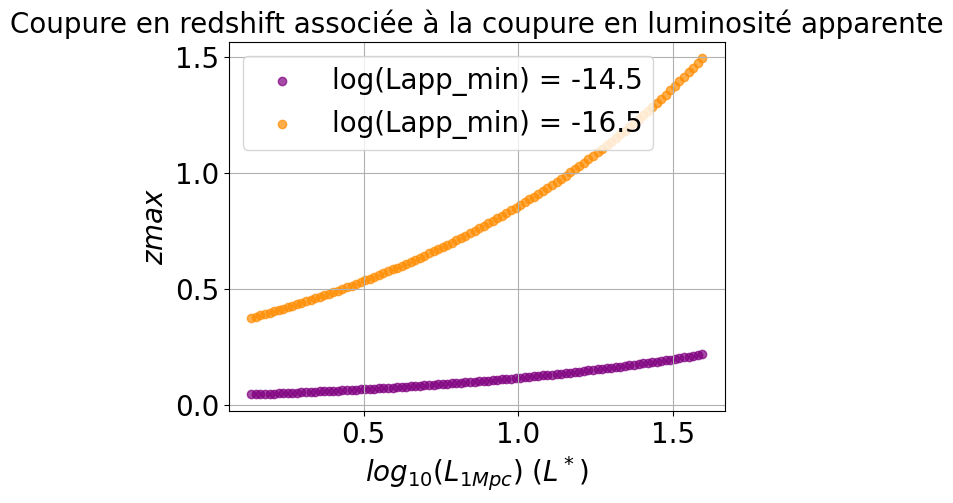

In [53]:
plt.scatter(bin_centers_L1Mpc_log10, z_max, color='purple',label=f'log(Lapp_min) = {log10_Lapp_min}', alpha=0.7)
plt.scatter(bin_centers_L1Mpc_log10, z_max_2, color='darkorange',label=f'log(Lapp_min) = {log10_Lapp_min_2}', alpha=0.7)
plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
plt.ylabel(r'$z{max}$')
plt.title(f'Coupure en redshift associée à la coupure en luminosité apparente')
plt.grid(True)
plt.legend()


In [54]:
bornes_z_cut_SCUSS = [0.05, z_max] 
volume_SCUSS_cut = Volume_survey_array(angular_area_SCUSS_deg2,bornes_z_cut_SCUSS)

bornes_z_cut_SCUSS_2 = [0.05, z_max_2] 
volume_SCUSS_cut_2 = Volume_survey_array(angular_area_SCUSS_deg2,bornes_z_cut_SCUSS_2)

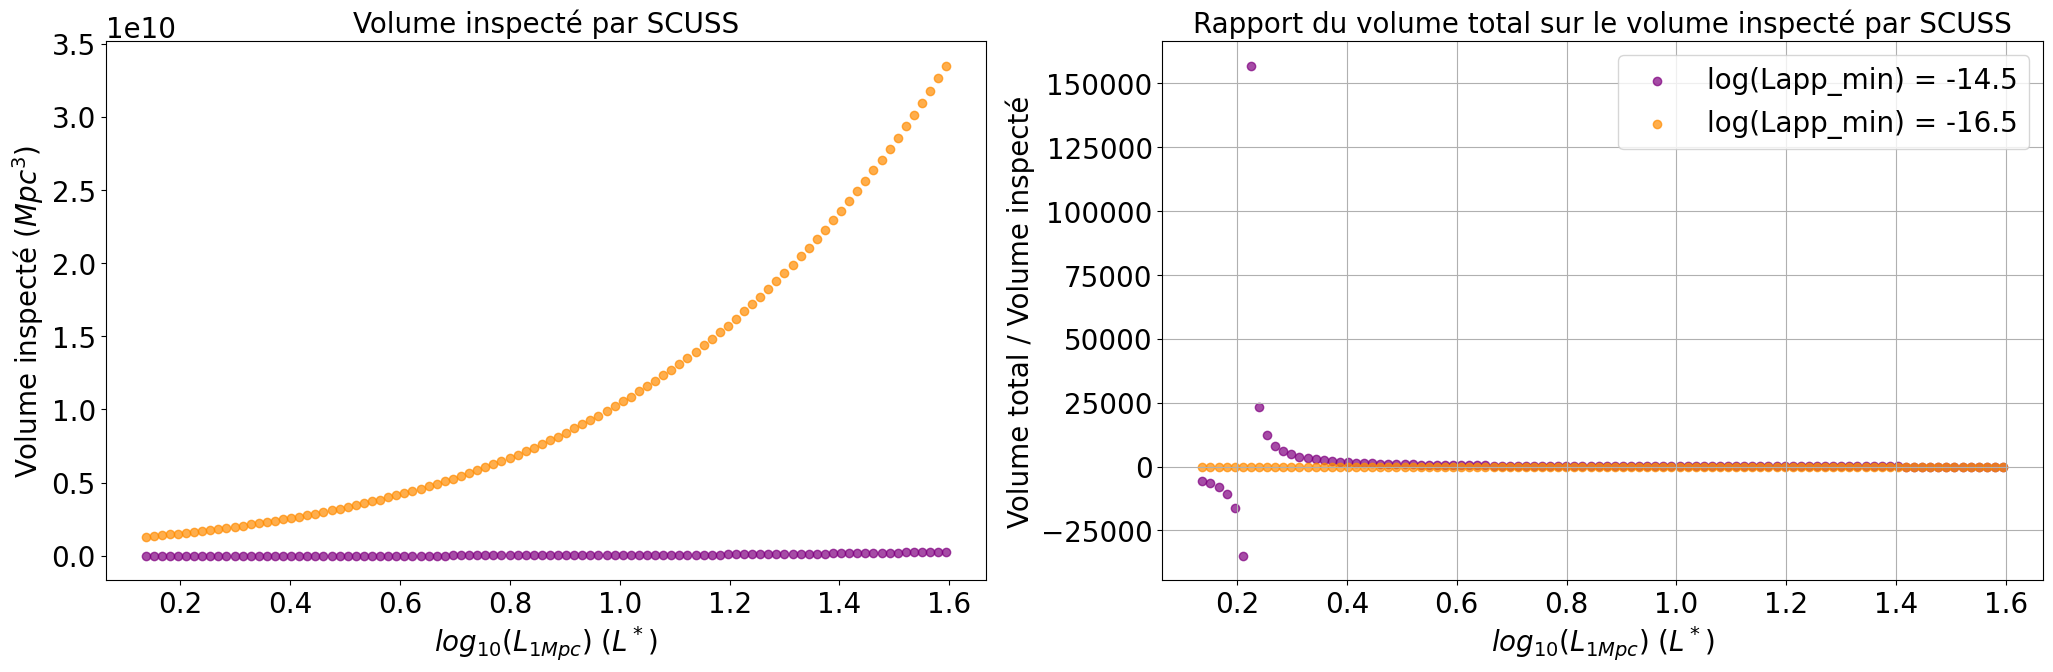

In [55]:
fig1 = plt.figure(figsize=(25, 7))

plt.subplot(121)
plt.scatter(bin_centers_L1Mpc_log10, volume_SCUSS_cut, color='purple',label=f'log(Lapp_min) = {log10_Lapp_min}',alpha=0.7)
plt.scatter(bin_centers_L1Mpc_log10, volume_SCUSS_cut_2, color='darkorange',label=f'log(Lapp_min) = {log10_Lapp_min_2}',alpha=0.7)
plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
plt.ylabel(r'Volume inspecté $(Mpc^3)$')
plt.title(f'Volume inspecté par SCUSS')

plt.subplot(122)
plt.scatter(bin_centers_L1Mpc_log10, volume_SCUSS/np.array(volume_SCUSS_cut), color='purple',label=f'log(Lapp_min) = {log10_Lapp_min}',alpha=0.7)
plt.scatter(bin_centers_L1Mpc_log10, volume_SCUSS/np.array(volume_SCUSS_cut_2), color='darkorange',label=f'log(Lapp_min) = {log10_Lapp_min_2}',alpha=0.7)
plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
plt.ylabel(r'Volume total / Volume inspecté')
plt.title(f'Rapport du volume total sur le volume inspecté par SCUSS')

plt.grid(True)
plt.legend()



In [56]:
# On recalcule la densité maintenant par bin de L1Mpc maintenant qu'on dispose du volume d'observation pour chaque bin
n_SCUSS_L1Mpc_log10_cut = []
for i in range(len(bin_centers_L1Mpc_log10)):
    current_n_SCUSS_L1Mpc_log10 = (counts_L1Mpc_log10[i]/bin_width_SCUSS_L1Mpc_log10)/volume_SCUSS_cut[i]
    n_SCUSS_L1Mpc_log10_cut.append(current_n_SCUSS_L1Mpc_log10)



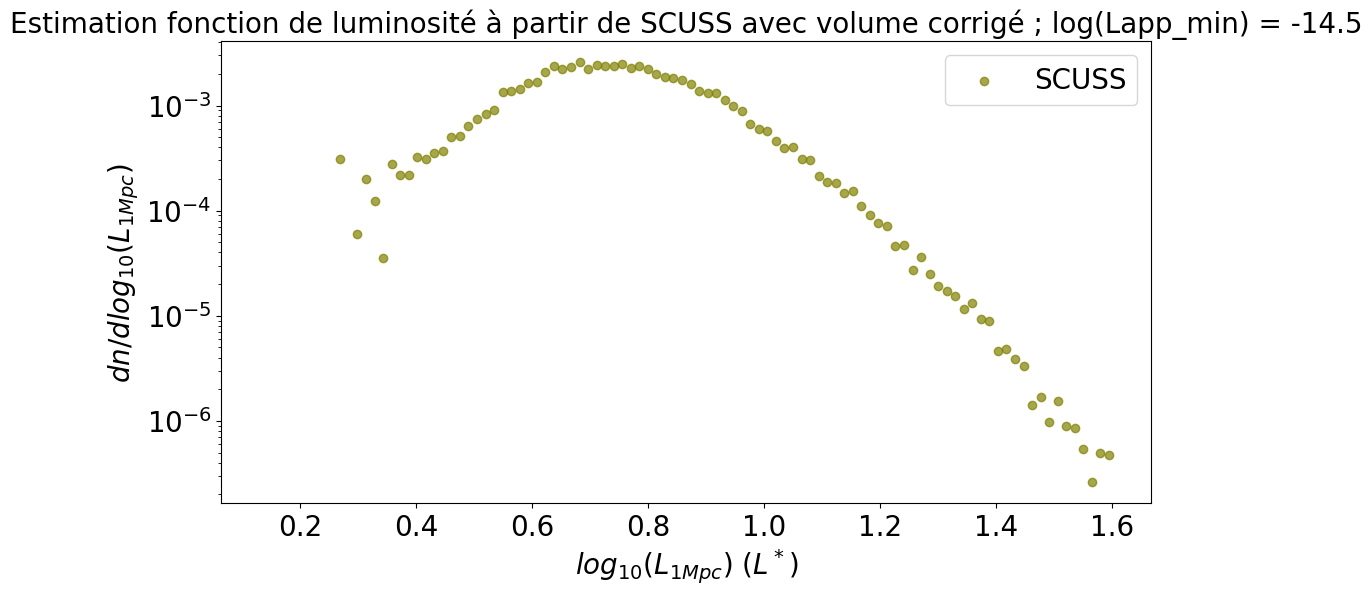

In [57]:
fig = plt.figure(figsize=(12, 6))
plt.scatter(bin_centers_L1Mpc_log10, n_SCUSS_L1Mpc_log10_cut, color='olive', label='SCUSS', alpha=0.7) 
plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
plt.ylabel(r'$dn / dlog_{10}(L_{1Mpc})$')
plt.yscale('log')
plt.title(f"Estimation fonction de luminosité à partir de SCUSS avec volume corrigé ; log(Lapp_min) = {log10_Lapp_min}")
plt.legend()

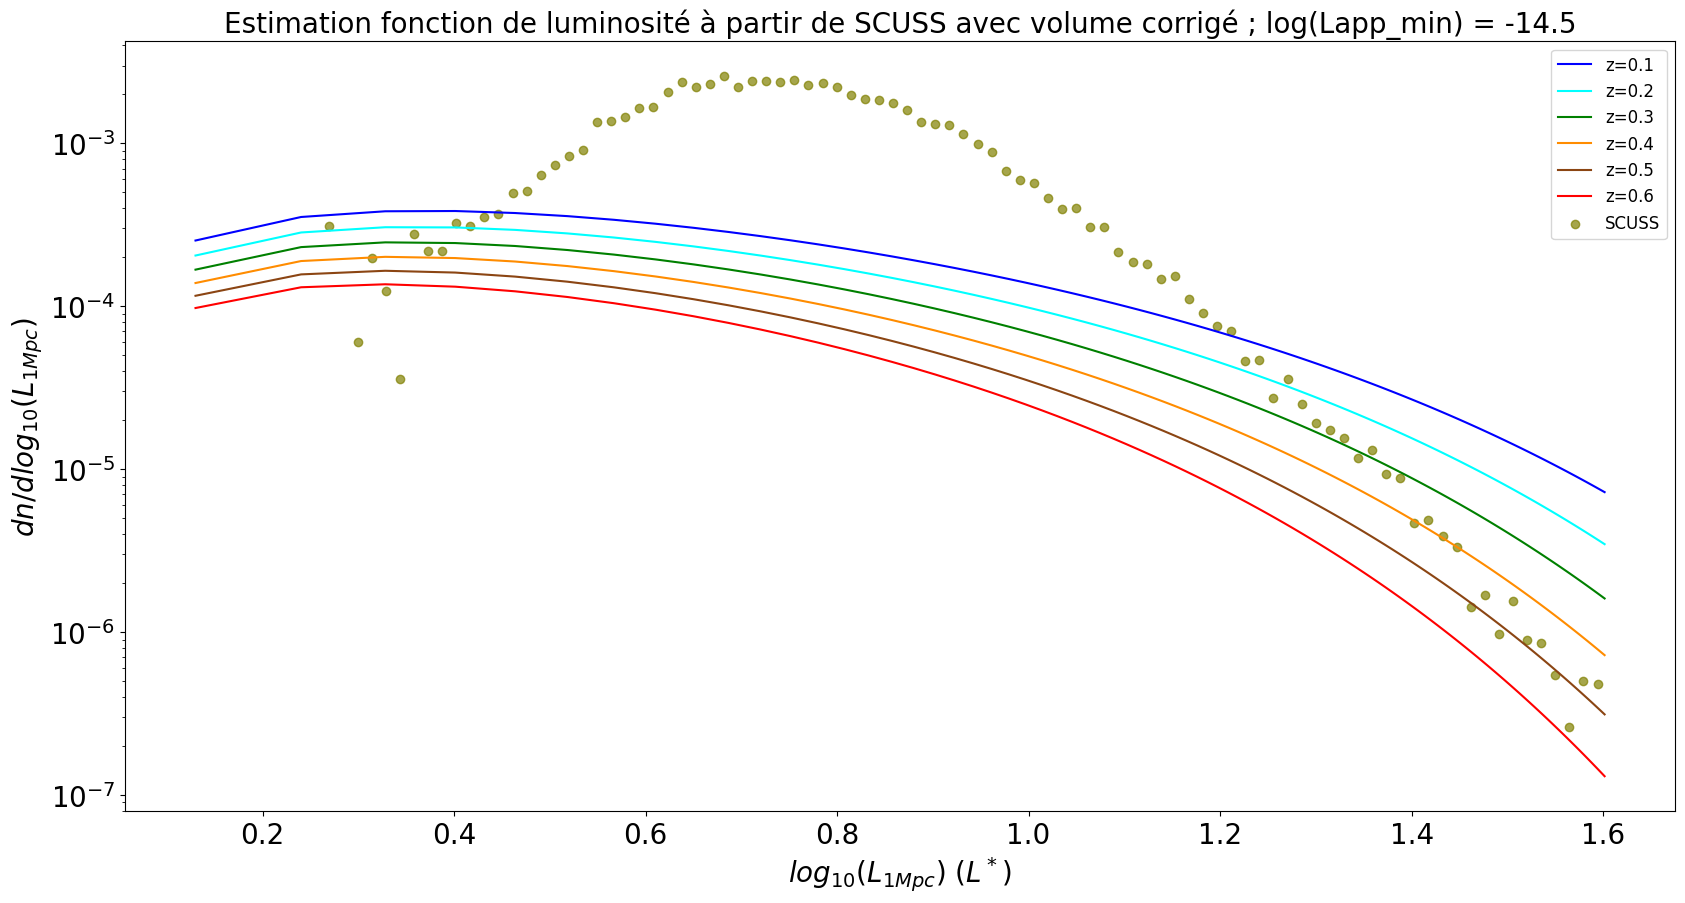

In [58]:
# Mpc ^-3 dex -1

fig1 = plt.figure(figsize=(20, 10))

#cmap = plt.get_cmap('tab10') # Matplotlib's collection of predefined colormaps
for i, z in enumerate(array_z): # On plot dn/dL1Mpc pour chaque redshift
    plt.plot(
        array_log10_L1Mpc_SCUSS,
        CLF_log10_MRP_GSR[i], # Pour le ième redshift de array_z
        label=f'z={z}',
        color=cmap_blue2red(i/(len(array_z) - 1)) # i / (len(array_z) - 1) → i normalisé entre 0 et 1 pour le colormap
    )

plt.scatter(bin_centers_L1Mpc_log10, n_SCUSS_L1Mpc_log10_cut, color='olive', label='SCUSS', alpha=0.7)


plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
plt.ylabel(r'$dn / dlog_{10}(L_{1Mpc})$')
plt.yscale('log')
plt.title(f"Estimation fonction de luminosité à partir de SCUSS avec volume corrigé ; log(Lapp_min) = {log10_Lapp_min}")
plt.legend(fontsize=12)

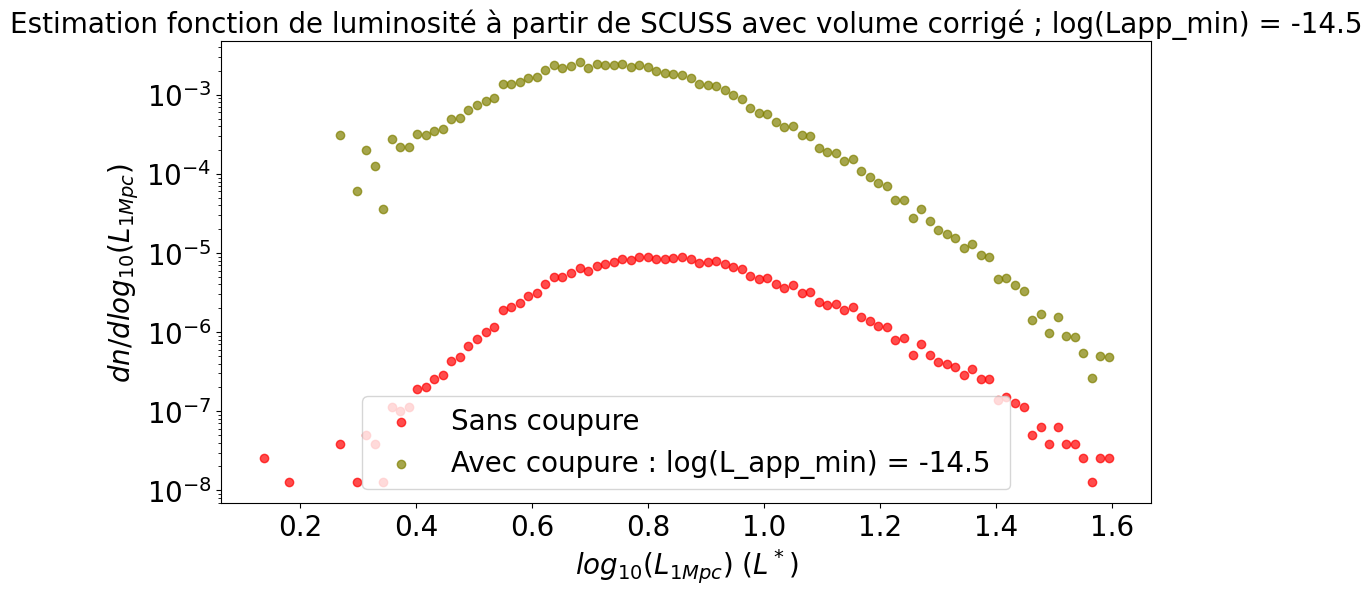

In [59]:
# Comparaison avec et sans coupure

fig = plt.figure(figsize=(12, 6))
plt.scatter(bin_centers_L1Mpc_log10, n_SCUSS_L1Mpc_log10, color='red', label='Sans coupure', alpha=0.7)
plt.scatter(bin_centers_L1Mpc_log10, n_SCUSS_L1Mpc_log10_cut, color='olive', label=f'Avec coupure : log(L_app_min) = {round(log10_Lapp_min,3)} ', alpha=0.7)
plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
plt.ylabel(r'$dn / dlog_{10}(L_{1Mpc})$')
plt.yscale('log')
plt.title(f"Estimation fonction de luminosité à partir de SCUSS avec volume corrigé ; log(Lapp_min) = {log10_Lapp_min}")
plt.legend()

## eRASS1

### Calculs prélims

In [60]:
path_eRASS1 = '../DESI_eRass/eRass_Bulbul_2024.fit' #la première table est la table eRosita de départ, enrichie avec des informations d'association avec SDSS-Wen

table_eRASS1 = fits_to_dataframe(path_eRASS1)
volume_eRASS1 = Volume_survey(angular_area_eRASS1_deg2,bornes_z)

nb_bins_z = 3 ; nb_bornes_z = nb_bins_z + 1 

In [61]:

# On crée plusieurs subsamples de la table eRASS1 en fonction des bornes de z
# Largeur en z identiques - nombre d'éléments différents

bornes_z_eRASS1 = np.linspace(0,np.max(table_eRASS1['zBest']),nb_bornes_z) # On va faire plusieurs tracés en fonction de plusieurs redshifts (n bins de z issus des n+1 bornes de z)

subtables_z_eRASS1 = []
for i in range(len(bornes_z_eRASS1)-1):
    subtable = table_eRASS1[(table_eRASS1['zBest'] >= bornes_z_eRASS1[i]) & (table_eRASS1['zBest'] <= bornes_z_eRASS1[i+1])]
    print(f'bin {i} : z allant de {round(bornes_z_eRASS1[i],3)} à {round(bornes_z_eRASS1[i+1],3)}')
    subtables_z_eRASS1.append(subtable)

M500_eRASS1 = np.log10(np.array(table_eRASS1['M500'])*1e13) # Pour ce catalogue, les masses sont données en 10^13 Msun
M500_eRASS1 = M500_eRASS1[(M500_eRASS1 > 12.7) & (M500_eRASS1 < 15.5)] # On ne garde que les amas compris entre les bornes de masses utilisées pour le calcul de la CMF (pour DESI LEgacy, on conserve tout)

M500_eRASS1_sub_z = []
for subtable in subtables_z_eRASS1:
    M500_sub = np.log10(np.array(subtable['M500'])*1e13) # Pour ce catalogue, les masses sont données en 10^13 Msun
    M500_sub = M500_sub[(M500_sub > 12.7) & (M500_sub < 15.5)] # On ne garde que les amas compris entre les bornes de masses utilisées pour le calcul de la CMF (pour DESI LEgacy, on conserve tout)
    M500_eRASS1_sub_z.append(M500_sub)


    

# Largeur en z différentes - même nombre d'éléments
# Create quantile-based bins for 'zBest'
table_eRASS1['z_bin'], bornes_z_eRASS1_2 = pd.qcut(table_eRASS1['zBest'], q=nb_bins_z, retbins=True, labels=False)

# Create subtables for each bin
subtables_z_eRASS1_2 = []
for i in range(nb_bins_z):
    subtable = table_eRASS1[table_eRASS1['z_bin'] == i]
    print(f'bin {i}: z from {round(bornes_z_eRASS1_2[i],3)} to {round(bornes_z_eRASS1_2[i+1],3)}, count={len(subtable)}')
    subtables_z_eRASS1_2.append(subtable)

M500_eRASS1_sub_z_2 = []
for subtable in subtables_z_eRASS1_2:
    M500_sub = np.log10(np.array(subtable['M500'])*1e13) # Pour ce catalogue, les masses sont données en 10^13 Msun
    M500_sub = M500_sub[(M500_sub > 12.7) & (M500_sub < 15.5)] # On ne garde que les amas compris entre les bornes de masses utilisées pour le calcul de la CMF (pour DESI LEgacy, on conserve tout)
    M500_eRASS1_sub_z_2.append(M500_sub)

bin 0 : z allant de 0.0 à 0.441
bin 1 : z allant de 0.441 à 0.881
bin 2 : z allant de 0.881 à 1.322
bin 0: z from 0.003 to 0.212, count=4083
bin 1: z from 0.212 to 0.425, count=4081
bin 2: z from 0.425 to 1.322, count=4083


C:\Users\ED282972\AppData\Local\Temp\ipykernel_16740\3290012287.py:12: RuntimeWarning: divide by zero encountered in log10
  M500_eRASS1 = np.log10(np.array(table_eRASS1['M500'])*1e13) # Pour ce catalogue, les masses sont données en 10^13 Msun
C:\Users\ED282972\AppData\Local\Temp\ipykernel_16740\3290012287.py:17: RuntimeWarning: divide by zero encountered in log10
  M500_sub = np.log10(np.array(subtable['M500'])*1e13) # Pour ce catalogue, les masses sont données en 10^13 Msun
C:\Users\ED282972\AppData\Local\Temp\ipykernel_16740\3290012287.py:37: RuntimeWarning: divide by zero encountered in log10
  M500_sub = np.log10(np.array(subtable['M500'])*1e13) # Pour ce catalogue, les masses sont données en 10^13 Msun


In [62]:
nb_bins_histos_ERASS1 = 40 #nb de bins de masse pour les prochains histogrammes

In [63]:
# Calcul estimation de la fonction de masse à partir de eRASS1 ; calculs des erreurs poissoniennes

counts_eRASS1, bin_edges = np.histogram(M500_eRASS1, bins=nb_bins_histos_ERASS1, range=[12.5, 15.5])
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:]) # Calculate bin centers
cloud_of_points = list(zip(bin_centers, counts)) # Pair counts with bin centers
# cloud_of_points is now a list of (mass, count) pair

bin_widths_eRASS1 = np.diff(bin_edges)
bin_width_eRASS1 = bin_widths_eRASS1[0] # la largeur d'un bin est toujours la même
print("Bin width:", bin_width_eRASS1) 

# Estimation CMF
n_eRASS1 = (counts_eRASS1/bin_width_eRASS1)/volume_eRASS1

#Estimation des erreurs poissoniennes
total = np.sum(counts_eRASS1)
errors_poisson_eRASS1 = np.sqrt(counts_eRASS1)
norm_counts_eRASS1 = counts_eRASS1 / (total * bin_width_eRASS1) ; errors_poisson_eRASS1_normalized = np.sqrt(counts_eRASS1) / (total * bin_width_eRASS1)

Bin width: 0.07499999999999929


In [64]:
len(bin_centers)

40

In [65]:
# Idem mais pour chaque sous-table de eRASS1
# Largeur en z identiques - nombre d'éléments différents


n_eRASS1_sub_z = [] # Estimation CMF

# Estimation des erreurs poissoniennes
counts_eRASS1_sub_z = [] ; norm_counts_eRASS1_sub_z = []
errors_poisson_eRASS1_sub_z = [] ; errors_poisson_eRASS1_normalized_sub_z = [] 

bin_centers_eRASS1_sub_z = []
for sub_M500 in M500_eRASS1_sub_z:
    counts, bin_edges = np.histogram(sub_M500, bins=nb_bins_histos_ERASS1, range=[12.5, 15.5])
    bin_centers_ = 0.5 * (bin_edges[:-1] + bin_edges[1:]) # Calculate bin centers
    cloud_of_points = list(zip(bin_centers_, counts)) # Pair counts with bin centers
    # cloud_of_points is now a list of (mass, count) pair
    bin_centers_eRASS1_sub_z.append(bin_centers_)
    
    bin_widths_eRASS1 = np.diff(bin_edges)
    bin_width_eRASS1 = bin_widths_eRASS1[0] # la largeur d'un bin est toujours la même

    # Estimation CMF
    sub_n_eRASS1 = (counts/bin_width_eRASS1)/volume_eRASS1
    n_eRASS1_sub_z.append(sub_n_eRASS1)

    #Estimation des erreurs poissoniennes
    total = np.sum(counts)

    counts_eRASS1_sub_z.append(counts)
    errors_poisson_eRASS1_sub_z.append(np.sqrt(counts))

    norm_counts_eRASS1_sub_z.append(counts / (total * bin_width_eRASS1))
    errors_poisson_eRASS1_normalized_sub_z.append(np.sqrt(counts) / (total * bin_width_eRASS1))

# ATTENTION : On diminue fortement le nombre d'amas dans les bins de z plus grand, donc les stats sont moins fiables !



In [66]:
# Largeur en z différentes - même nombre d'éléments


n_eRASS1_sub_z_2 = [] # Estimation CMF

# Estimation des erreurs poissoniennes
counts_eRASS1_sub_z_2 = [] ; norm_counts_eRASS1_sub_z_2 = []
errors_poisson_eRASS1_sub_z_2 = [] ; errors_poisson_eRASS1_normalized_sub_z_2 = [] 

bin_centers_eRASS1_sub_z_2 = []

for sub_M500 in M500_eRASS1_sub_z_2:
    counts, bin_edges = np.histogram(sub_M500, bins=nb_bins_histos_ERASS1, range=[12.5, 15.5])
    bin_centers_ = 0.5 * (bin_edges[:-1] + bin_edges[1:]) # Calculate bin centers
    cloud_of_points = list(zip(bin_centers_, counts)) # Pair counts with bin centers
    # cloud_of_points is now a list of (mass, count) pair
    bin_centers_eRASS1_sub_z_2.append(bin_centers_)
    
    bin_widths_eRASS1 = np.diff(bin_edges)
    bin_width_eRASS1 = bin_widths_eRASS1[0] # la largeur d'un bin est toujours la même

    # Estimation CMF
    sub_n_eRASS1 = (counts/bin_width_eRASS1)/volume_eRASS1
    n_eRASS1_sub_z_2.append(sub_n_eRASS1)

    #Estimation des erreurs poissoniennes
    total = np.sum(counts)

    counts_eRASS1_sub_z_2.append(counts)
    errors_poisson_eRASS1_sub_z_2.append(np.sqrt(counts))

    norm_counts_eRASS1_sub_z_2.append(counts / (total * bin_width_eRASS1))
    errors_poisson_eRASS1_normalized_sub_z_2.append(np.sqrt(counts) / (total * bin_width_eRASS1))

# ATTENTION : On diminue fortement le nombre d'amas dans les bins de z plus grand, donc les stats sont moins fiables !

### Affichage histos masse

In [67]:
nb_bins_histo = 40

Moyenne de la masse des amas est de  14.248  et l'écart type de  0.364  pour eRASS1
Moyenne de la masse des amas est de  14.18  et l'écart type de  0.391  pour eRASS1 pour des z allant de 0.0 à 0.441
Moyenne de la masse des amas est de  14.413  et l'écart type de  0.215  pour eRASS1 pour des z allant de 0.441 à 0.881
Moyenne de la masse des amas est de  14.403  et l'écart type de  0.159  pour eRASS1 pour des z allant de 0.881 à 1.322


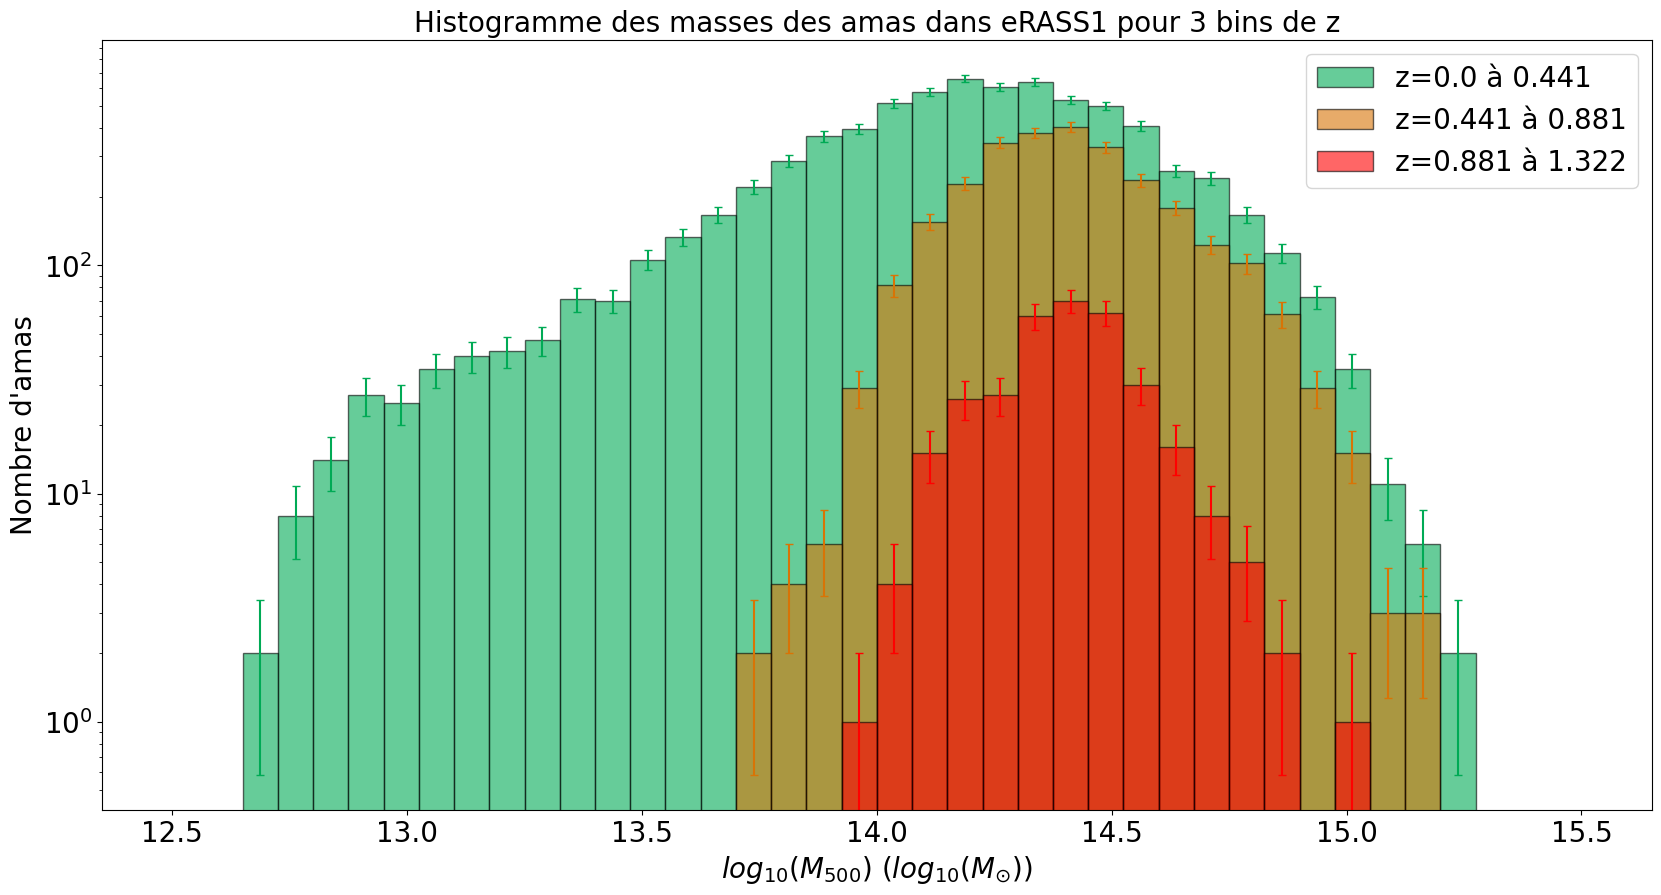

In [68]:
# Histo largeurs fixés - nb différents
# Note : Transformer tout ce code sous la forme de fonction pour éviter la répétition

# Histogramme des masses des amas dans eRASS1 sans normalisation
plt.figure(figsize=(20, 10))

plt.ylabel('Nombre d\'amas')
plt.yscale('log')
plt.title('Histogramme des masses des amas dans eRASS1')
print('Moyenne de la masse des amas est de ',round(np.mean(M500_eRASS1),3)," et l'écart type de ", round(np.std(M500_eRASS1),3), " pour eRASS1")

#cmap = plt.get_cmap('tab10') 
for i,sub_mass in enumerate(M500_eRASS1_sub_z) :
    print('Moyenne de la masse des amas est de ',round(np.mean(sub_mass),3),r" et l'écart type de ", round(np.std(sub_mass),3), f" pour eRASS1 pour des z allant de {round(bornes_z_eRASS1[i],3)} à {round(bornes_z_eRASS1[i+1],3)}")

    
    plt.hist(
        sub_mass,
        bins=nb_bins_histo,
        range=(12.5, 15.5),  # On fixe la plage de l'histogramme pour qu'il soit comparable avec les autres !
        color=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z))),  # Normalisation de i pour le colormap
        alpha=0.6,
        edgecolor='black',
        label=f'z={round(bornes_z_eRASS1[i],3)} à {round(bornes_z_eRASS1[i+1],3)}'
    )
    plt.errorbar(bin_centers, counts_eRASS1_sub_z[i], yerr=errors_poisson_eRASS1_sub_z[i], fmt='none', ecolor=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z))), capsize=3)
    plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)') 
    plt.ylabel('Nombre d\'amas')
    plt.yscale('log')
    plt.title(f'Histogramme des masses des amas dans eRASS1 pour {nb_bins_z} bins de z')

plt.legend()





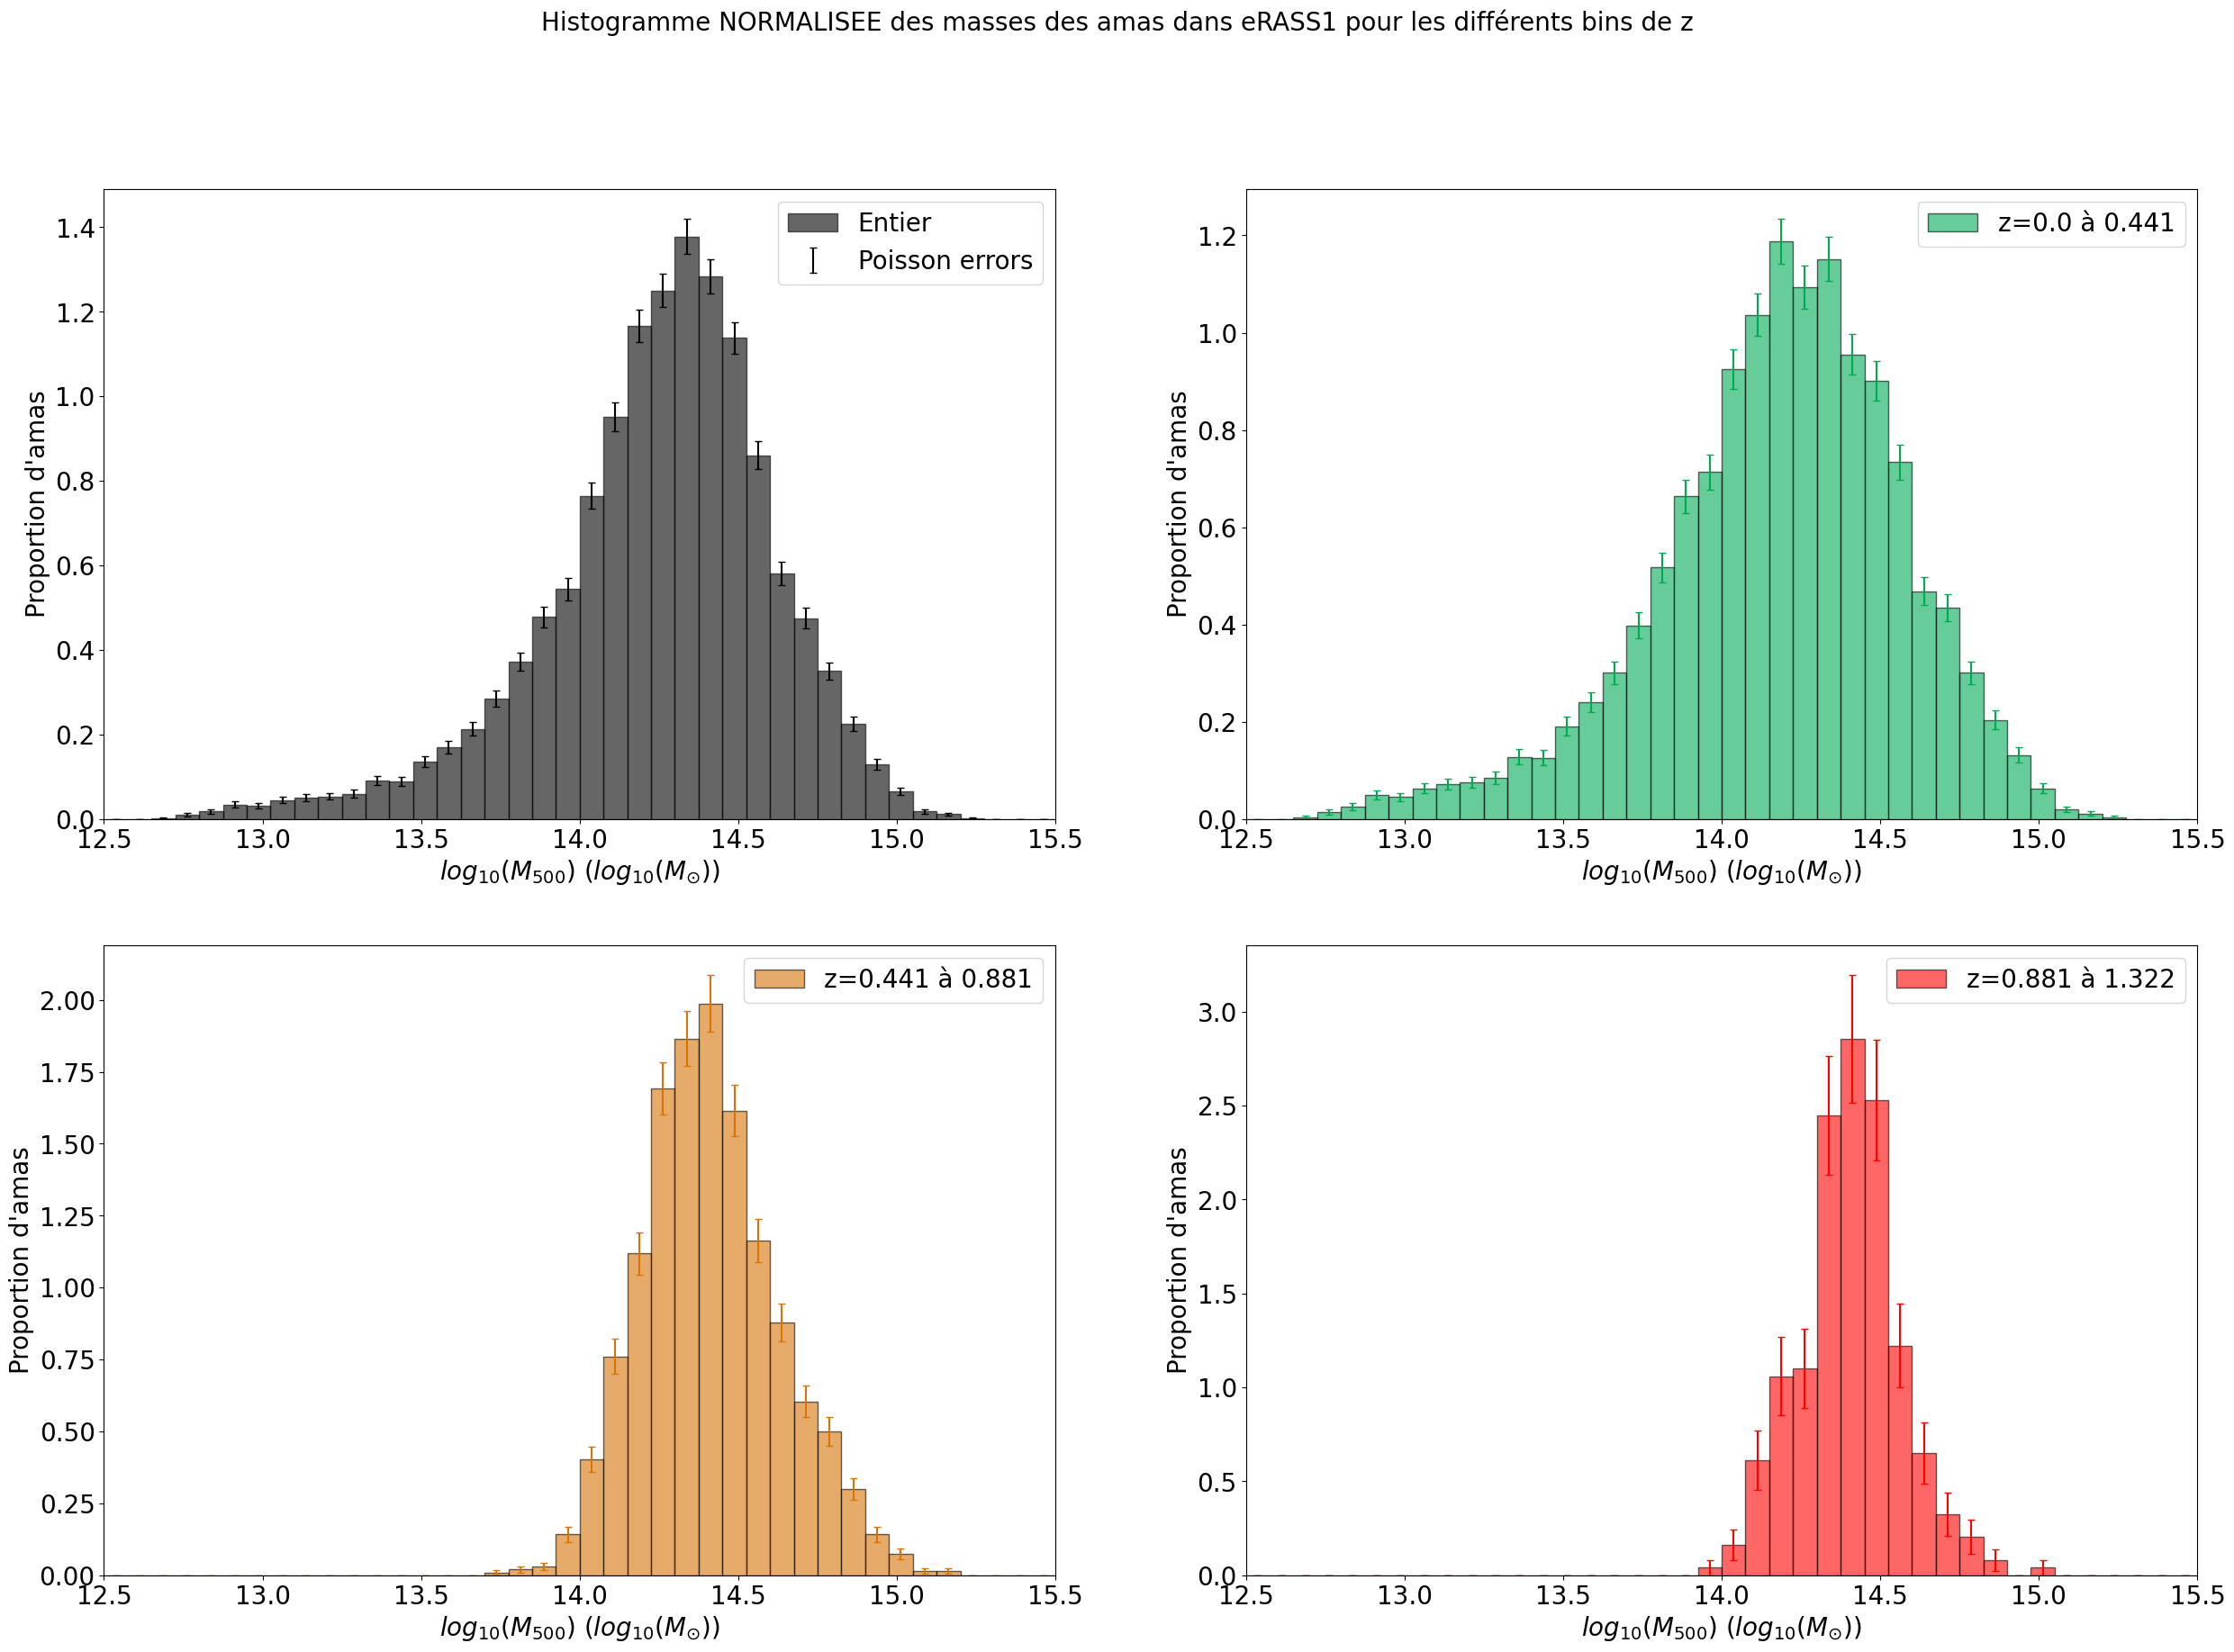

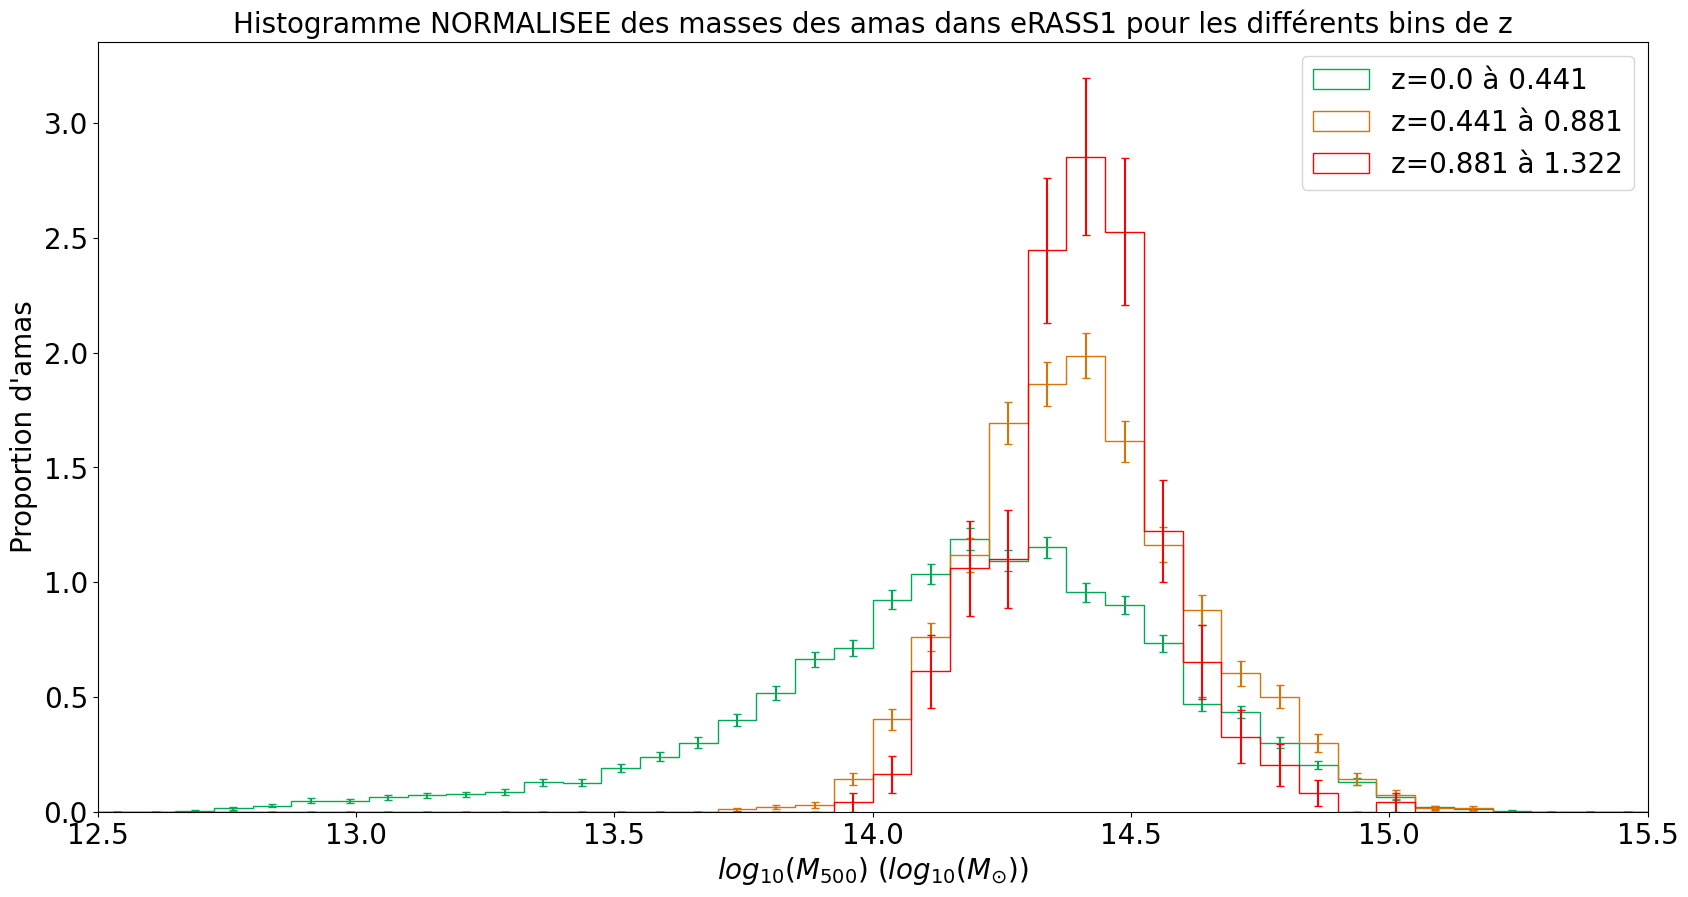

In [69]:
# Histogramme des masses des amas dans eRASS1 normalisé (chaqye nombre d'amas par bin est divisé par le nombre total d'amas dans eRASS1)
plt.figure(figsize=(30, 20))
plt.suptitle(f'Histogramme NORMALISEE des masses des amas dans eRASS1 pour les différents bins de z', fontsize=20)
plt.subplot((nb_bins_z+1)//2 , (nb_bins_z+1)//2 ,1)
plt.hist(M500_eRASS1, bins=nb_bins_histo, color='black',range=(12.5, 15.5), alpha = 0.6, edgecolor='black',label = 'Entier', density=True) #l'opition density=True normalise l'histogramme ((nombre d’éléments dans le bin) ÷ (nombre total d’éléments × largeur du bin))
plt.errorbar(bin_centers, norm_counts_eRASS1, yerr=errors_poisson_eRASS1_normalized, fmt='none', ecolor='black', capsize=3, label='Poisson errors')
plt.xlim(12.5, 15.5)
plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
if nb_bins_histo == 100:
    plt.ylabel('Proportion d\'amas en %')
else:
    plt.ylabel('Proportion d\'amas')
plt.legend()

for i,sub_mass in enumerate(M500_eRASS1_sub_z) :
    plt.subplot((nb_bins_z+1)//2 , (nb_bins_z+1)//2  ,i+2)
    plt.hist(sub_mass, bins=nb_bins_histo, range=(12.5, 15.5), 
             color=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z))), edgecolor='black', alpha=0.6,
             label = f'z={round(bornes_z_eRASS1[i],3)} à {round(bornes_z_eRASS1[i+1],3)}', density=True) #idem
    plt.errorbar(bin_centers, norm_counts_eRASS1_sub_z[i], yerr=errors_poisson_eRASS1_normalized_sub_z[i], fmt='none',
                 ecolor=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z))), capsize=3)
    plt.xlim(12.5, 15.5)
    plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
    if nb_bins_histo == 100:
        plt.ylabel('Proportion d\'amas en %')
    else:
        plt.ylabel('Proportion d\'amas')
    plt.legend()

#
plt.figure(figsize=(20, 10))
plt.title(f'Histogramme NORMALISEE des masses des amas dans eRASS1 pour les différents bins de z', fontsize=20)
for i,sub_mass in enumerate(M500_eRASS1_sub_z) :
    plt.hist(sub_mass, bins=nb_bins_histo, color=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z))),range=(12.5, 15.5), label=f'z={round(bornes_z_eRASS1[i],3)} à {round(bornes_z_eRASS1[i+1],3)}', density=True, histtype='step') # Only edges
    plt.errorbar(bin_centers, norm_counts_eRASS1_sub_z[i], yerr=errors_poisson_eRASS1_normalized_sub_z[i], fmt='none',
                 ecolor=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z))), capsize=3)
    plt.xlim(12.5, 15.5)
    plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
    if nb_bins_histo == 100:
        plt.ylabel('Proportion d\'amas en %')
    else:
        plt.ylabel('Proportion d\'amas')    
    plt.legend()

Moyenne de la masse des amas est de  14.248  et l'écart type de  0.364  pour eRASS1
Moyenne de la masse des amas est de  14.019  et l'écart type de  0.424  pour eRASS1 pour des z allant de 0.003 à 0.212
Moyenne de la masse des amas est de  14.327  et l'écart type de  0.285  pour eRASS1 pour des z allant de 0.212 à 0.425
Moyenne de la masse des amas est de  14.413  et l'écart type de  0.213  pour eRASS1 pour des z allant de 0.425 à 1.322


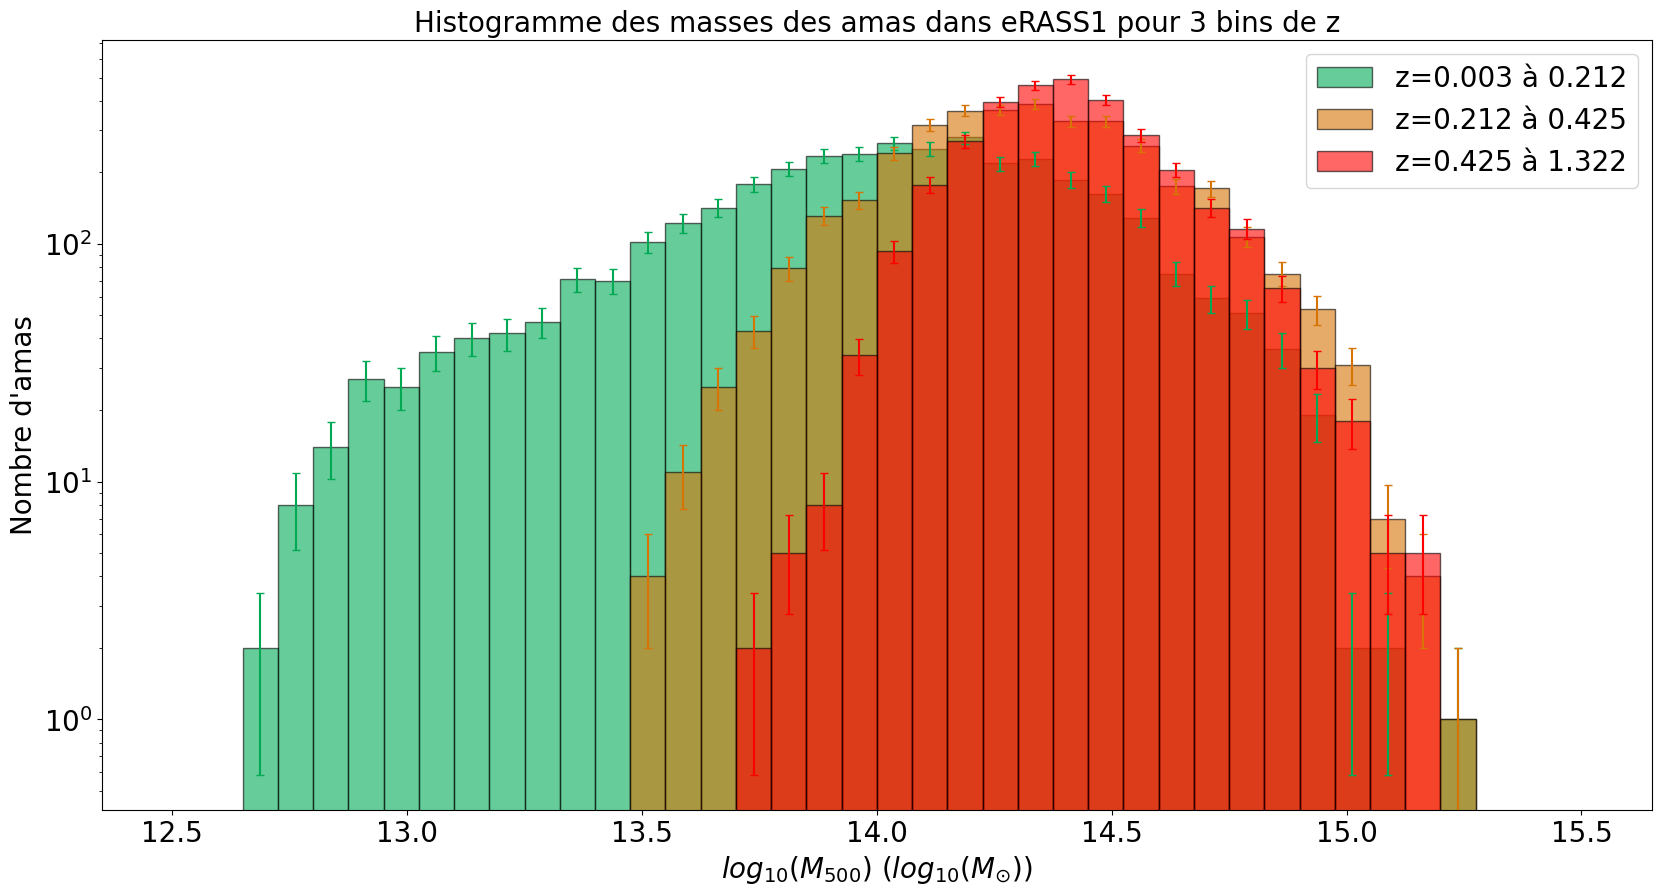

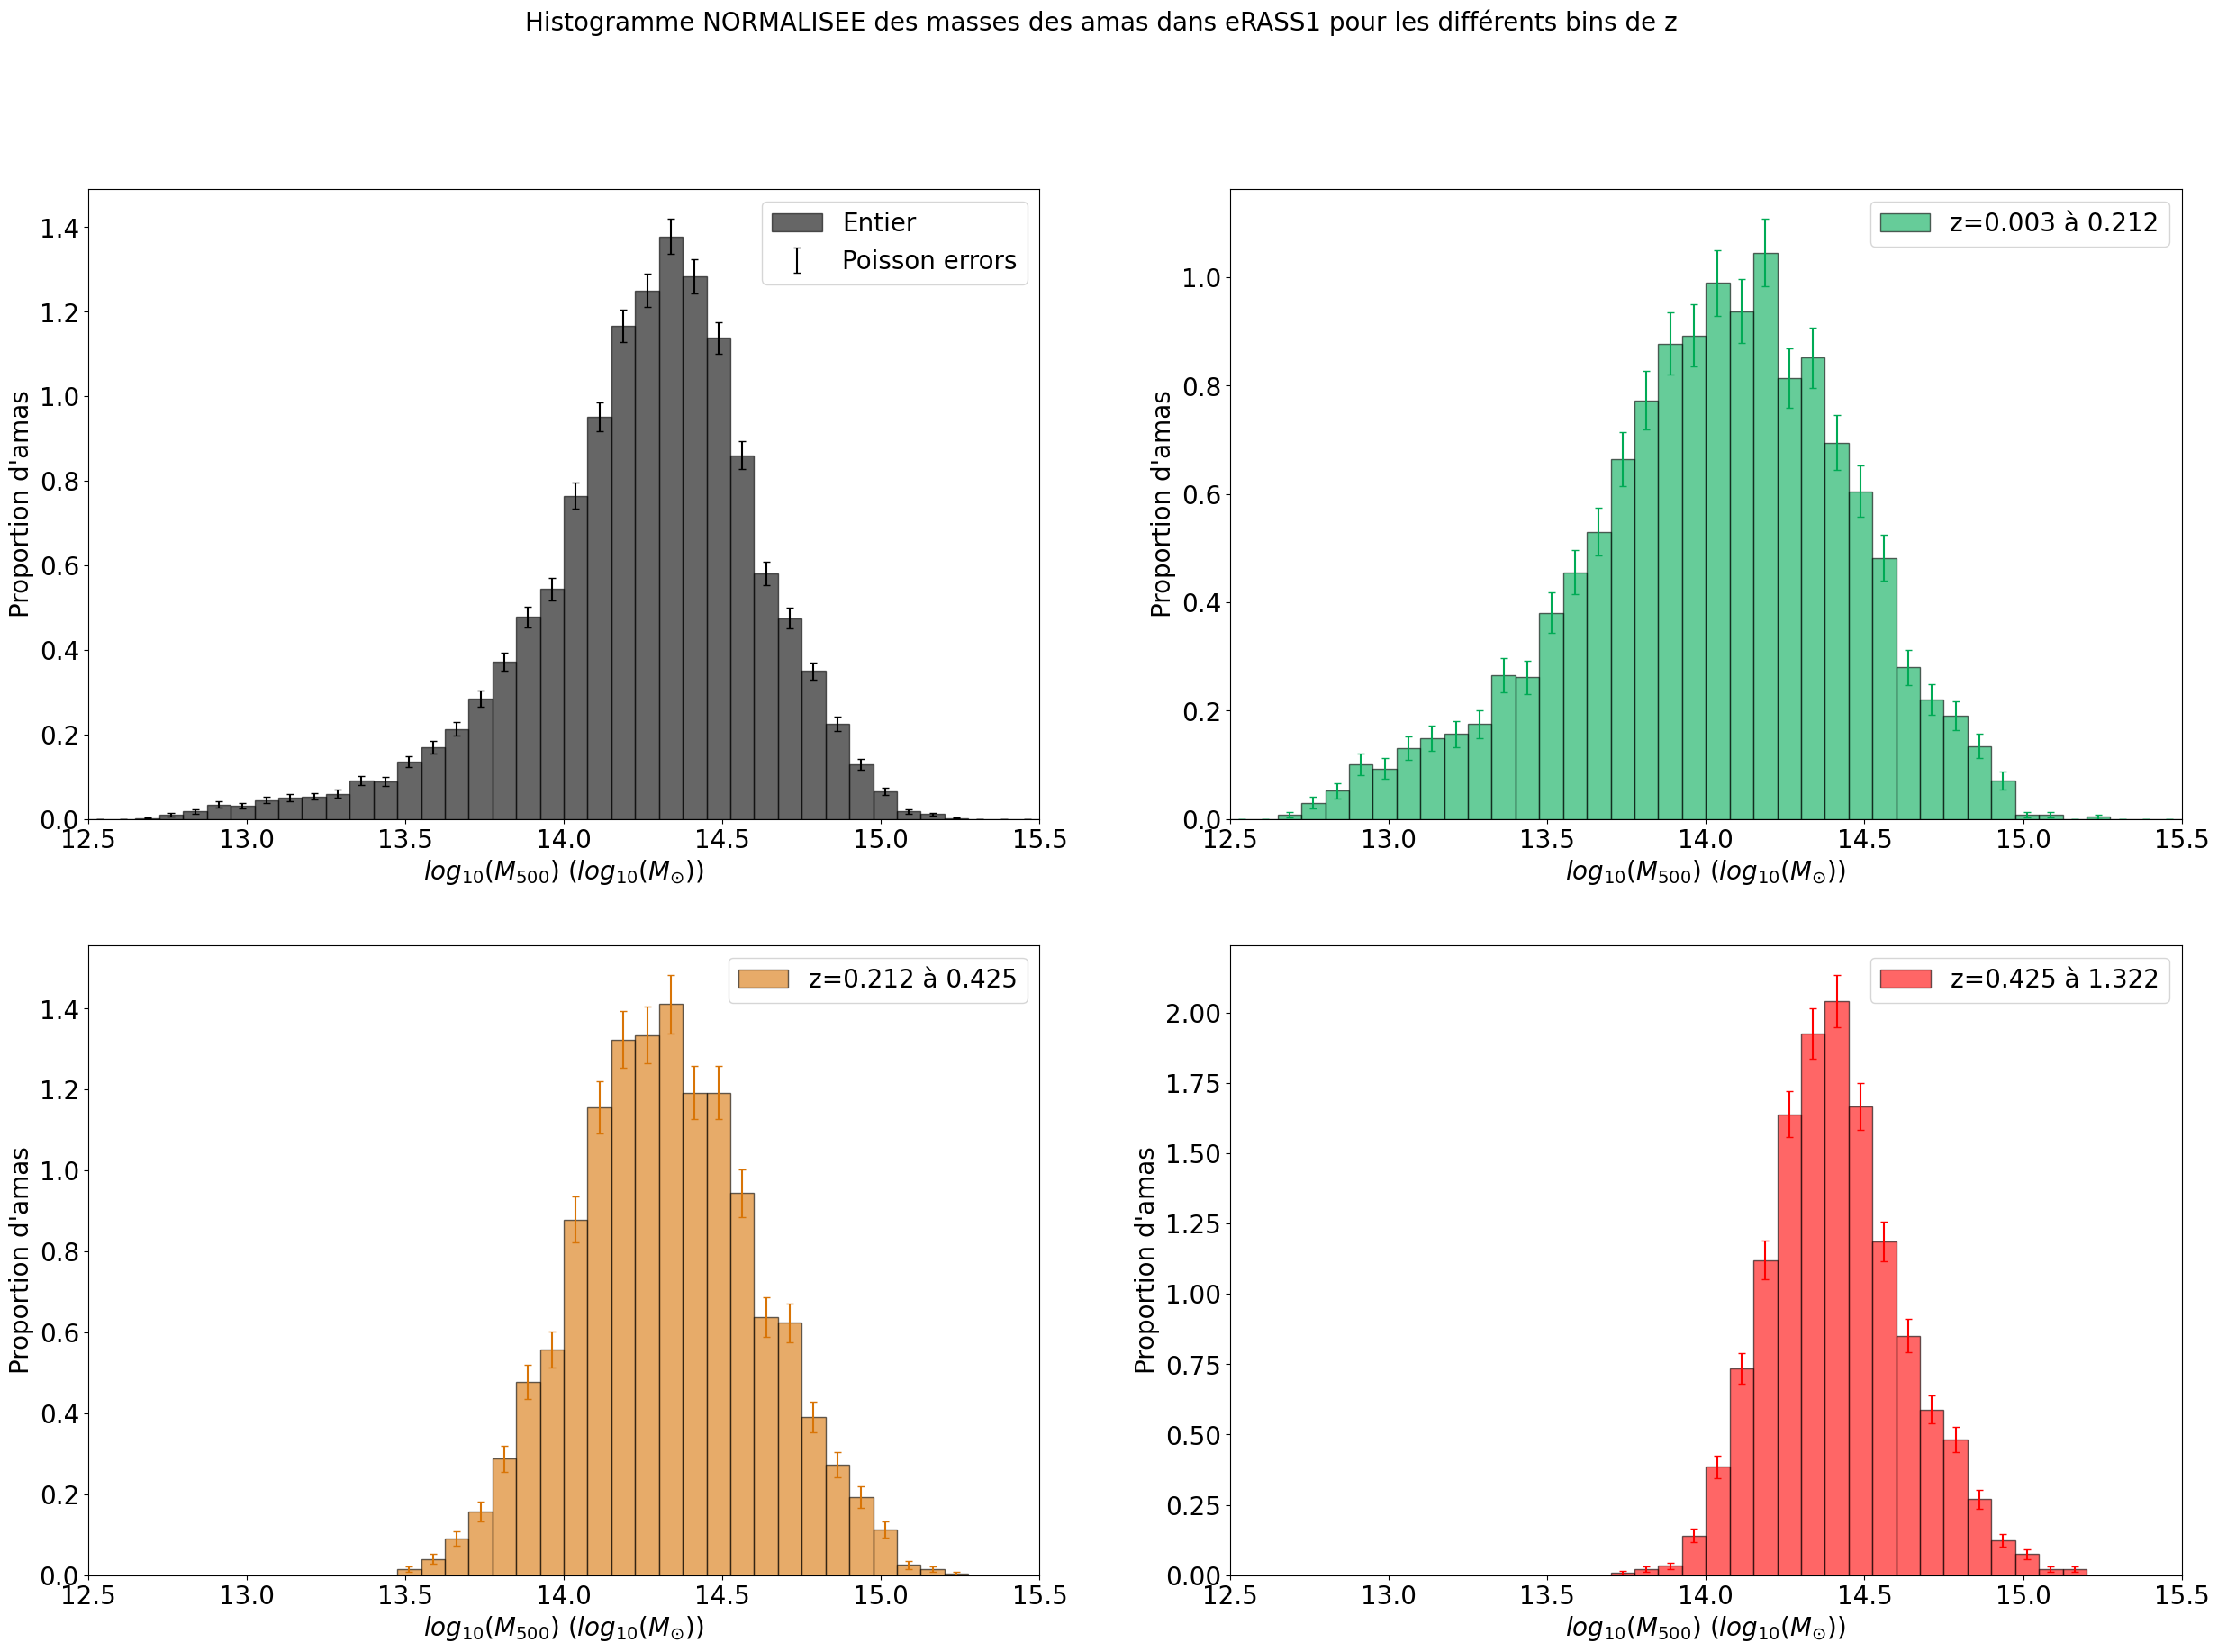

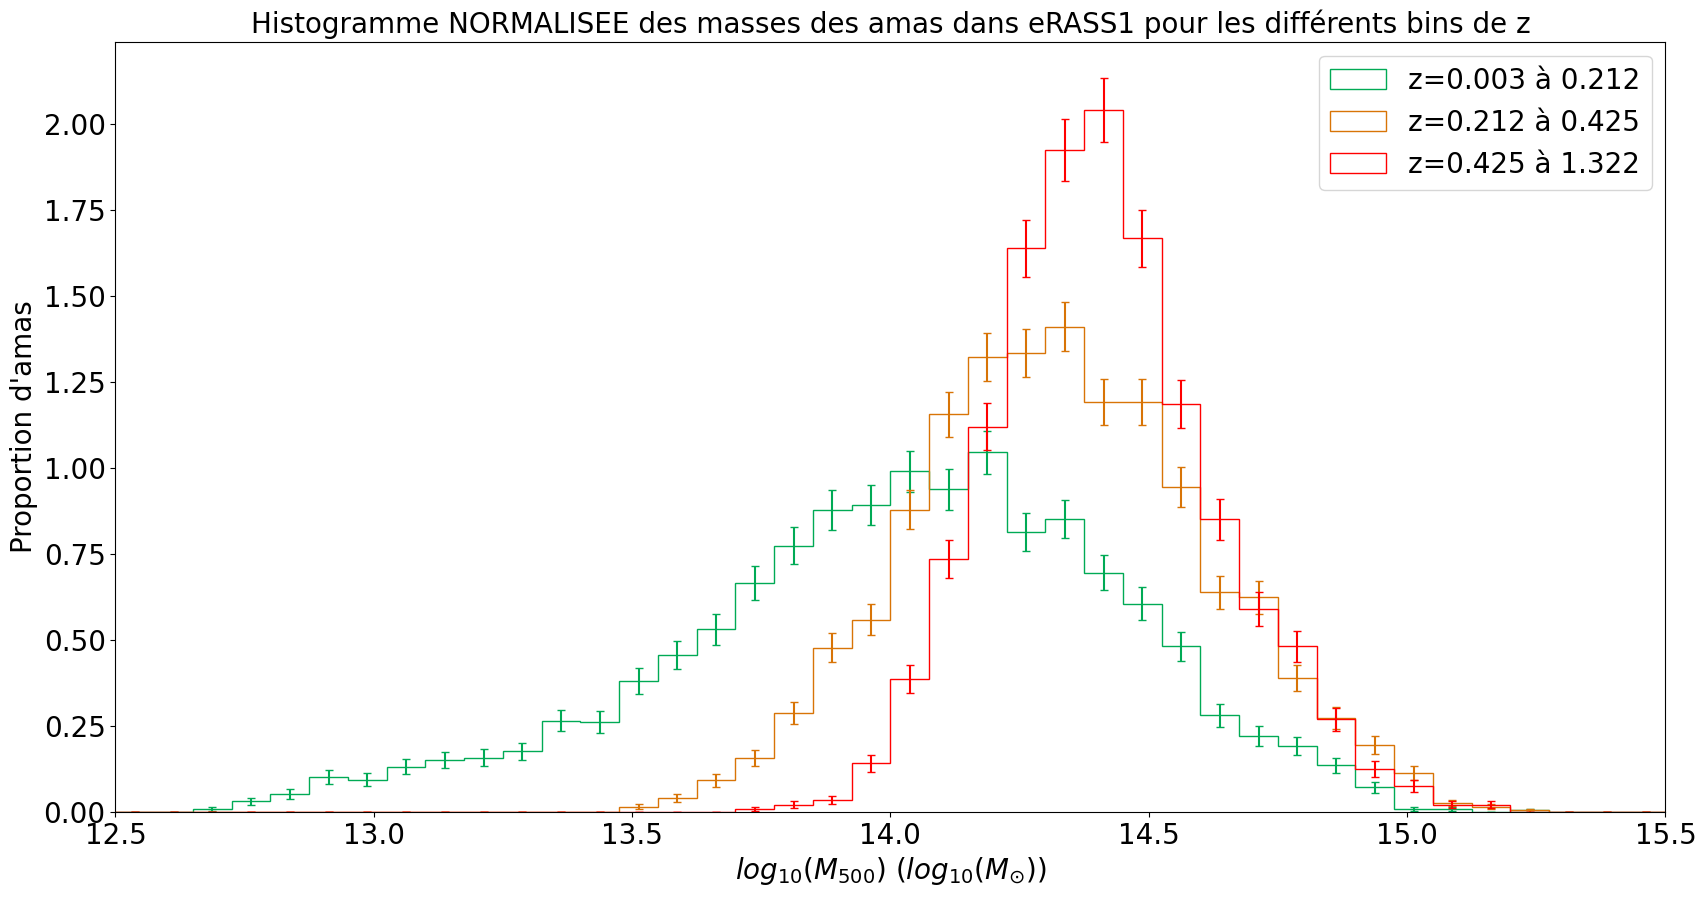

In [70]:
# Histo largeurs différentes - nb ~ fixées

# Histogramme des masses des amas dans eRASS1 sans normalisation
plt.figure(figsize=(20, 10))

plt.ylabel('Nombre d\'amas')
plt.yscale('log')
plt.title('Histogramme des masses des amas dans eRASS1')
print('Moyenne de la masse des amas est de ',round(np.mean(M500_eRASS1),3)," et l'écart type de ", round(np.std(M500_eRASS1),3), " pour eRASS1")

cmap = plt.get_cmap('tab10') 
for i,sub_mass in enumerate(M500_eRASS1_sub_z_2) :
    print('Moyenne de la masse des amas est de ',round(np.mean(sub_mass),3),r" et l'écart type de ", round(np.std(sub_mass),3), f" pour eRASS1 pour des z allant de {round(bornes_z_eRASS1_2[i],3)} à {round(bornes_z_eRASS1_2[i+1],3)}")

    plt.hist(
        sub_mass,
        bins=nb_bins_histo,
        range=(12.5, 15.5),  # On fixe la plage de l'histogramme pour qu'il soit comparable avec les autres !
        color=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z))),  # Normalisation de i pour le colormap
        alpha=0.6,
        edgecolor='black',
        label=f'z={round(bornes_z_eRASS1_2[i],3)} à {round(bornes_z_eRASS1_2[i+1],3)}'
    )
    plt.errorbar(bin_centers, counts_eRASS1_sub_z_2[i], yerr=errors_poisson_eRASS1_sub_z_2[i], fmt='none', ecolor=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z))), capsize=3)    
    plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)') 
    plt.ylabel('Nombre d\'amas')
    plt.yscale('log')
    plt.title(f'Histogramme des masses des amas dans eRASS1 pour {nb_bins_z} bins de z')

plt.legend()




# Histogramme des masses des amas dans eRASS1 normalisé (chaqye nombre d'amas par bin est divisé par le nombre total d'amas dans eRASS1)
plt.figure(figsize=(30, 20))
plt.suptitle(f'Histogramme NORMALISEE des masses des amas dans eRASS1 pour les différents bins de z', fontsize=20)
plt.subplot((nb_bins_z+1)//2 , (nb_bins_z+1)//2 ,1)
plt.hist(M500_eRASS1, bins=nb_bins_histo, color='black',range=(12.5, 15.5), alpha = 0.6, edgecolor='black',label = 'Entier', density=True) #l'opition density=True normalise l'histogramme ((nombre d’éléments dans le bin) ÷ (nombre total d’éléments × largeur du bin))
plt.errorbar(bin_centers, norm_counts_eRASS1, yerr=errors_poisson_eRASS1_normalized, fmt='none', ecolor='black', capsize=3, label='Poisson errors')
plt.xlim(12.5, 15.5)
plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
if nb_bins_histo == 100:
    plt.ylabel('Proportion d\'amas en %')
else:
    plt.ylabel('Proportion d\'amas')
plt.legend()

for i,sub_mass in enumerate(M500_eRASS1_sub_z_2) :
    plt.subplot((nb_bins_z+1)//2 , (nb_bins_z+1)//2  ,i+2)
    plt.hist(sub_mass, bins=nb_bins_histo, range=(12.5, 15.5), 
             color=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z_2))), edgecolor='black', alpha=0.6,
             label = f'z={round(bornes_z_eRASS1_2[i],3)} à {round(bornes_z_eRASS1_2[i+1],3)}', density=True) #idem
    plt.errorbar(bin_centers, norm_counts_eRASS1_sub_z_2[i], yerr=errors_poisson_eRASS1_normalized_sub_z_2[i], fmt='none',
                 ecolor=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z_2))), capsize=3)
    plt.xlim(12.5, 15.5)
    plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
    if nb_bins_histo == 100:
        plt.ylabel('Proportion d\'amas en %')
    else:
        plt.ylabel('Proportion d\'amas')
    plt.legend()

#M500_eRASS1_sub_z_2_partial = [M500_eRASS1_sub_z_2[0],M500_eRASS1_sub_z_2[2]]
plt.figure(figsize=(20, 10))
plt.title(f'Histogramme NORMALISEE des masses des amas dans eRASS1 pour les différents bins de z', fontsize=20)
for i,sub_mass in enumerate(M500_eRASS1_sub_z_2) :
    plt.hist(sub_mass, bins=nb_bins_histo, color=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z_2))),range=(12.5, 15.5), label=f'z={round(bornes_z_eRASS1_2[i],3)} à {round(bornes_z_eRASS1_2[i+1],3)}', density=True, histtype='step') # Only edges
    plt.errorbar(bin_centers, norm_counts_eRASS1_sub_z_2[i], yerr=errors_poisson_eRASS1_normalized_sub_z_2[i], fmt='none',
                 ecolor=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z_2))), capsize=3)
    plt.xlim(12.5, 15.5)
    plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
    if nb_bins_histo == 100:
        plt.ylabel('Proportion d\'amas en %')
    else:
        plt.ylabel('Proportion d\'amas')    
    plt.legend()


### Estimation CMF

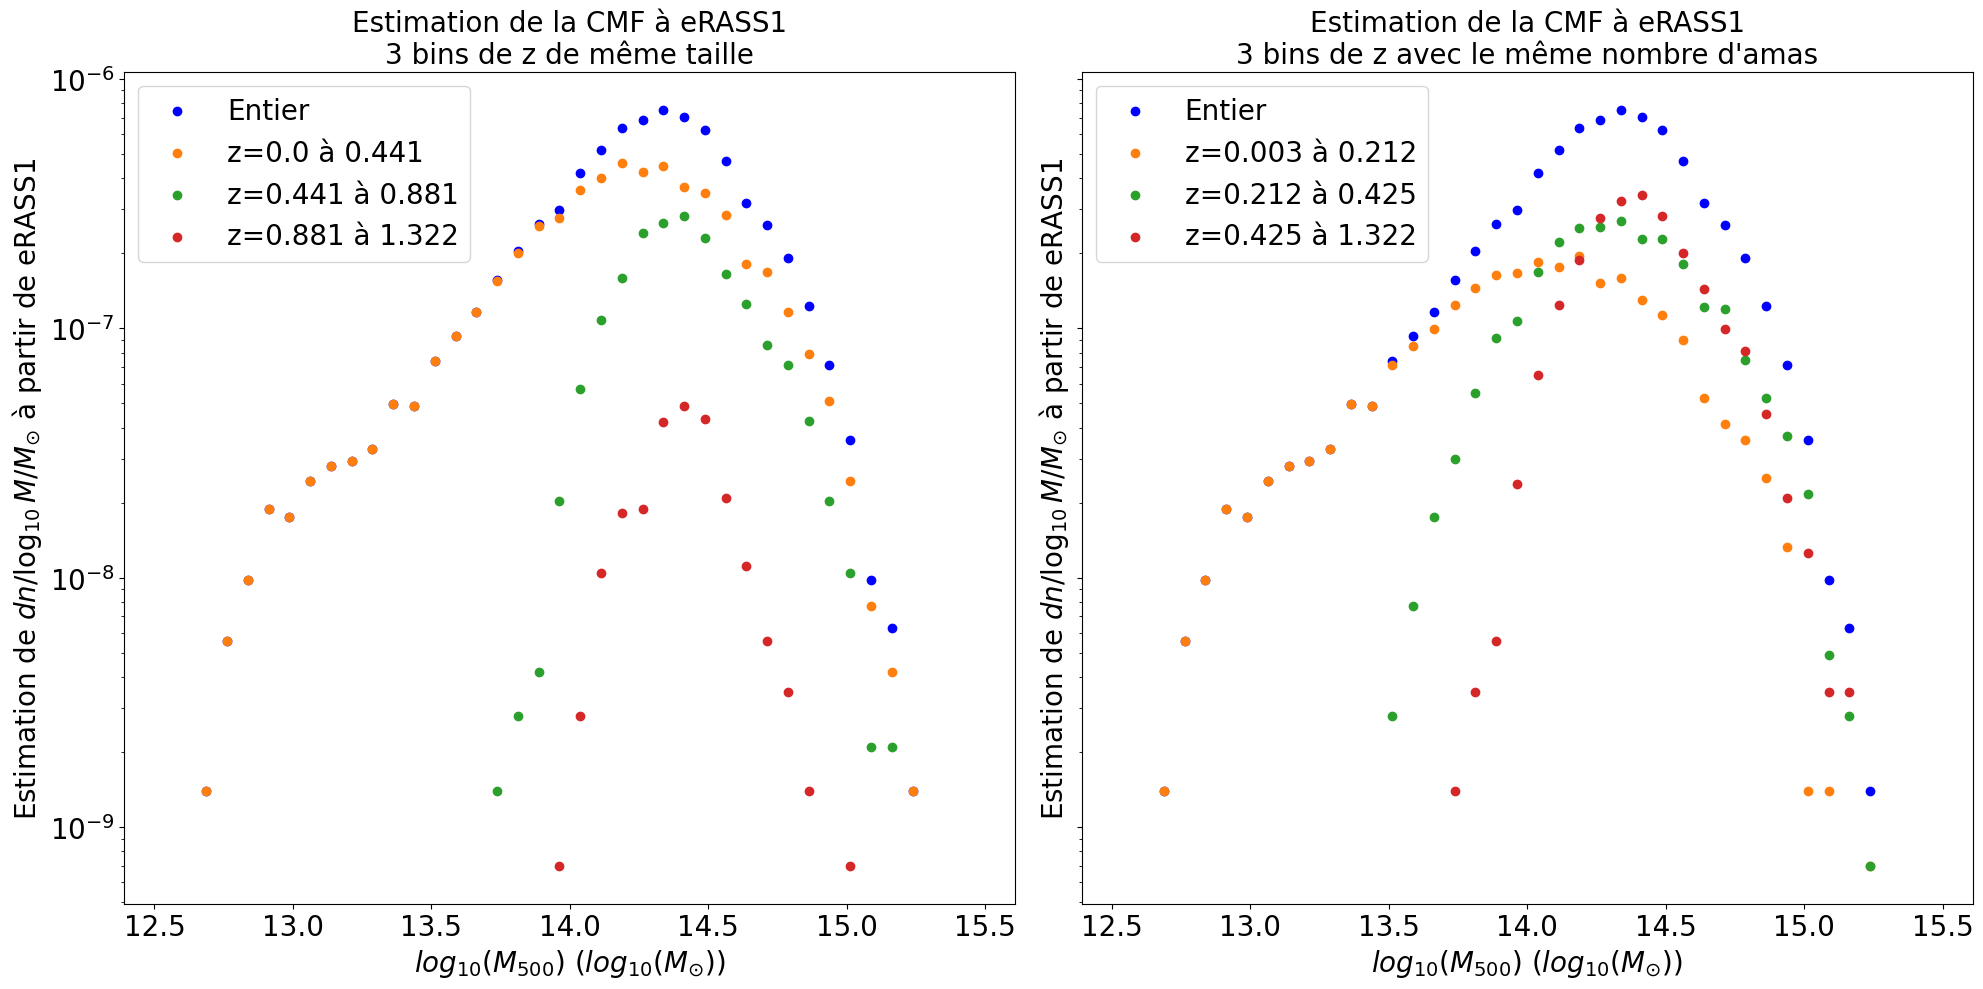

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharey=True)

# First subplot: bins de z de même taille
ax = axes[0]
ax.scatter(bin_centers, n_eRASS1, color='blue', label='Entier') 
cmap = plt.get_cmap('tab10') 
for i, sub_nrass in enumerate(n_eRASS1_sub_z):
    ax.scatter(bin_centers_eRASS1_sub_z[i], sub_nrass, color=cmap(i+1), label=f'z={round(bornes_z_eRASS1[i],3)} à {round(bornes_z_eRASS1[i+1],3)}')
ax.set_xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
ax.set_ylabel(r'Estimation de $dn / \log_{10} M / M_{\odot}$ à partir de eRASS1')
ax.set_yscale('log')
ax.set_title(f'Estimation de la CMF à eRASS1\n{nb_bins_z} bins de z de même taille')
ax.legend()

# Second subplot: bins de z avec le même nombre d'amas
ax2 = axes[1]
ax2.scatter(bin_centers, n_eRASS1, color='blue', label='Entier') 
cmap = plt.get_cmap('tab10') 
for i, sub_nrass in enumerate(n_eRASS1_sub_z_2):
    ax2.scatter(bin_centers_eRASS1_sub_z_2[i], sub_nrass, color=cmap(i+1), label=f'z={round(bornes_z_eRASS1_2[i],3)} à {round(bornes_z_eRASS1_2[i+1],3)}')
ax2.set_xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
ax2.set_ylabel(r'Estimation de $dn / \log_{10} M / M_{\odot}$ à partir de eRASS1')
ax2.set_yscale('log')
ax2.set_title(f'Estimation de la CMF à eRASS1\n{nb_bins_z} bins de z avec le même nombre d\'amas')
ax2.legend()

plt.tight_layout()

<>:22: SyntaxWarning: invalid escape sequence '\o'
<>:22: SyntaxWarning: invalid escape sequence '\o'
C:\Users\ED282972\AppData\Local\Temp\ipykernel_16740\4093152440.py:22: SyntaxWarning: invalid escape sequence '\o'
  '''residuals_GSR = np.abs(CMF_GSR_func(bin_centers) - n_eRASS1)


'plt.legend()'

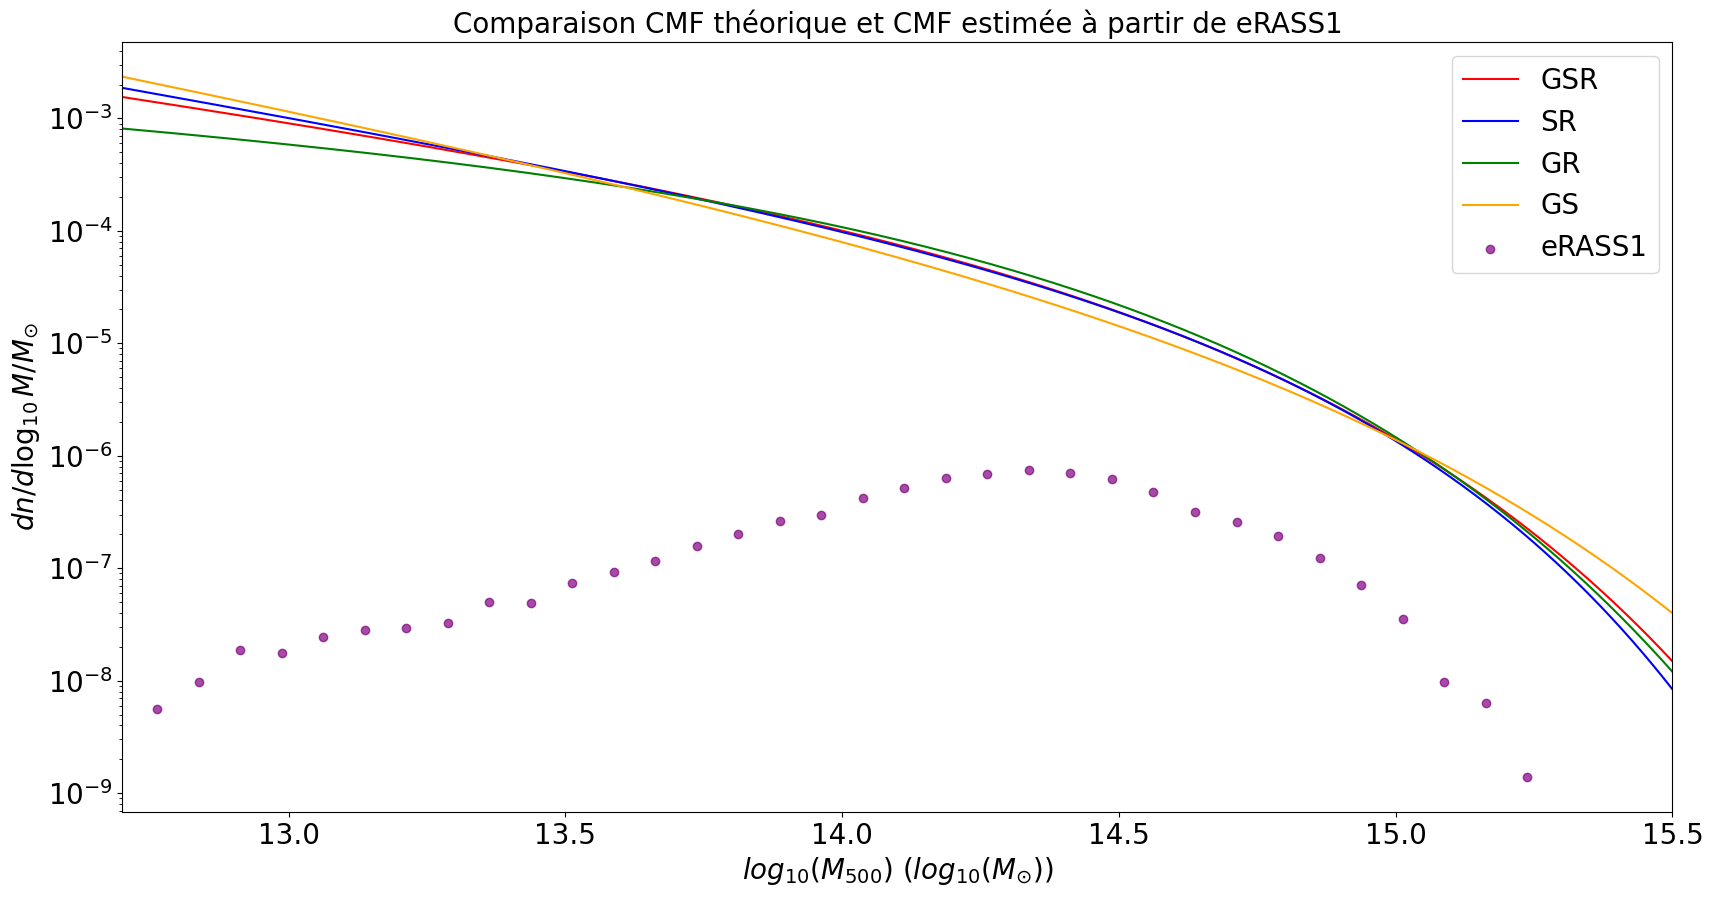

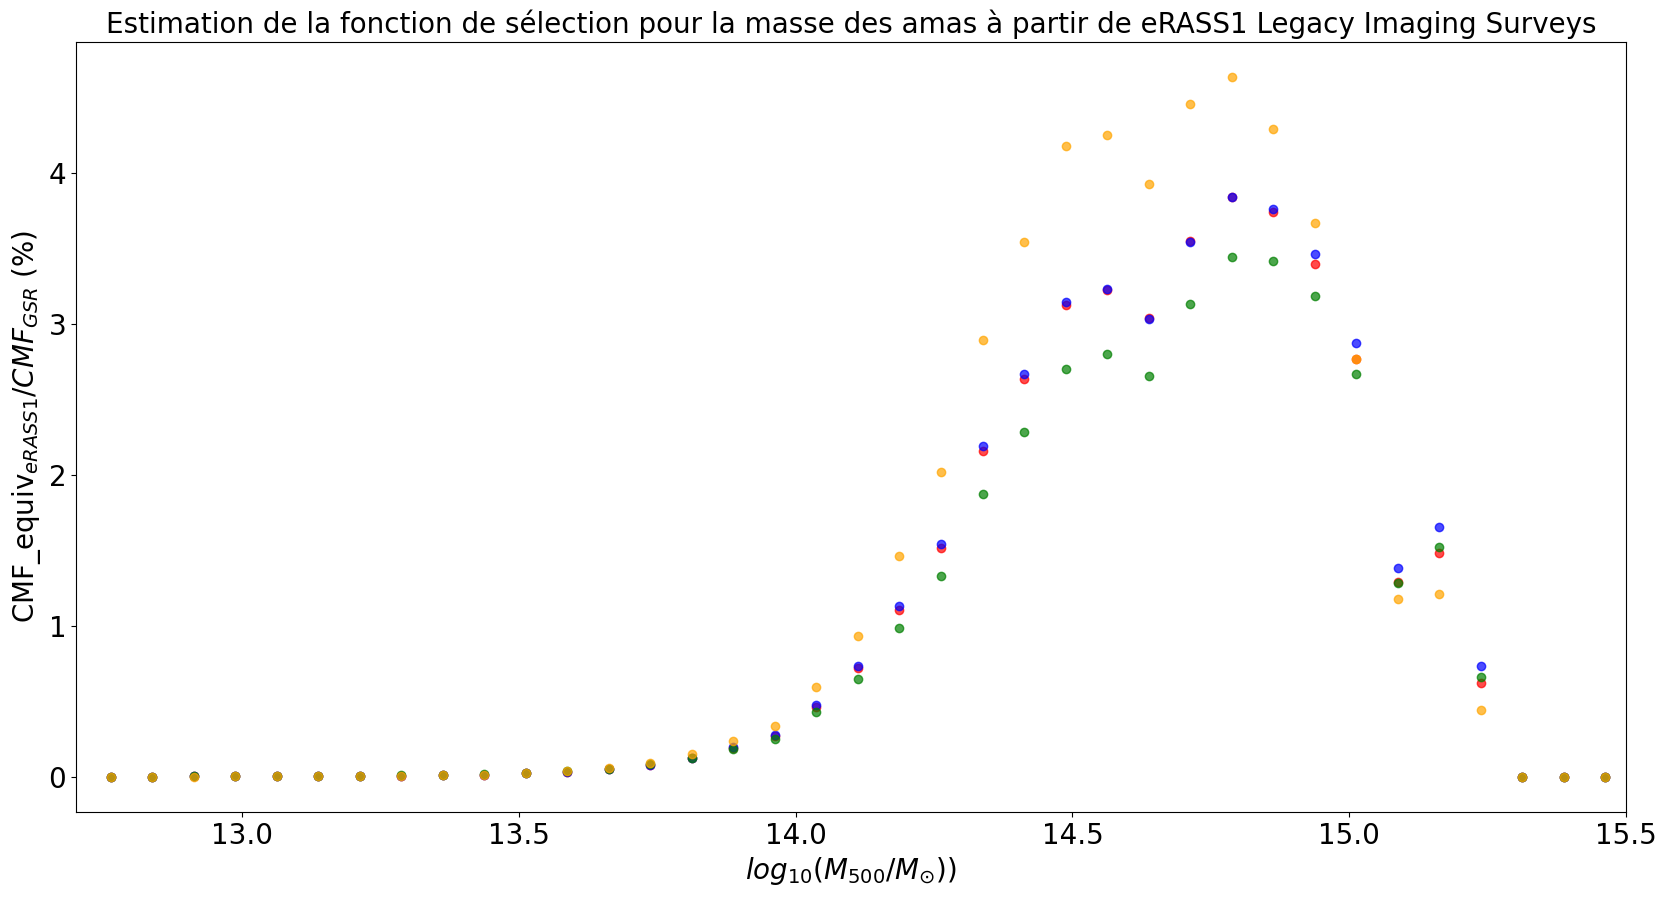

In [72]:
# Mpc ^-3 dex -1

# ATTENTION : On n'a pas pris en compte l'évolution en fonction du redshift, ni la masse de référence utilisée pour la fonction MRP (M500 ou autre chose ? → je n'arrive pas à trouver dans les papiers pour l'instant)

fig1 = plt.figure(figsize=(20, 10))

plt.plot(log10_M_Msun, CMF_GSR, label='GSR', color='red')
plt.plot(log10_M_Msun, CMF_SR, label='SR', color='blue')
plt.plot(log10_M_Msun, CMF_GR, label='GR', color='green')
plt.plot(log10_M_Msun, CMF_GS, label='GS', color='orange')

plt.scatter(bin_centers, n_eRASS1, color='purple', label='eRASS1', alpha=0.7)
plt.xlim(12.7, 15.5)

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$dn / d\log_{10} M / M_{\odot}$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de eRASS1')

plt.legend()

'''residuals_GSR = np.abs(CMF_GSR_func(bin_centers) - n_eRASS1)
residuals_SR = np.abs(CMF_SR_func(bin_centers) - n_eRASS1)
residuals_GR = np.abs(CMF_GR_func(bin_centers) - n_eRASS1)
residuals_GS = np.abs(CMF_GS_func(bin_centers) - n_eRASS1)


fig2 = plt.figure(figsize=(20, 10))
plt.scatter(bin_centers, residuals_GSR, color='red', label='GSR Residuals', alpha=0.7)-
plt.scatter(bin_centers, residuals_SR, color='blue', label='SR Residuals', alpha=0.7)
plt.scatter(bin_centers, residuals_GR, color='green', label='GR Residuals', alpha=0.7)
plt.scatter(bin_centers, residuals_GS, color='orange', label='GS Residuals', alpha=0.7)
plt.xlim(12.2, 15.7)
plt.yscale('log')

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$dn / d\log_{10} M / M_{\odot}$')


plt.title('Résidus entre la CMF théorique et la CMF estimée à partir de eRASS1')
'''

# On essaie d'en déduire une fonction de sélection en fonction de la masse des amas

estimation_selection_function_masse_GSR = n_eRASS1/CMF_GSR_func(bin_centers)
estimation_selection_function_masse_SR = n_eRASS1/CMF_SR_func(bin_centers)
estimation_selection_function_masse_GR = n_eRASS1/CMF_GR_func(bin_centers)
estimation_selection_function_masse_GS = n_eRASS1/CMF_GS_func(bin_centers)



plt.figure(figsize=(20, 10))

plt.scatter(bin_centers, estimation_selection_function_masse_GSR * 100, color='red', alpha=0.7,label='GSR')
plt.scatter(bin_centers, estimation_selection_function_masse_SR * 100, color='blue', alpha=0.7,label='SR')
plt.scatter(bin_centers, estimation_selection_function_masse_GR * 100, color='green', alpha=0.7,label='GR')
plt.scatter(bin_centers, estimation_selection_function_masse_GS * 100, color='orange', alpha=0.7,label='GS')

'''plt.hlines(100, 12.7, 15.5, color='black', linestyle='dashed', label='100%')
plt.hlines(0, 12.7, 15.5, color='black', linestyle='dashed', label='0%')'''

plt.xlim(12.7, 15.5)

plt.xlabel(r'$log_{10}(M_{500}/M_{\odot})$)')
plt.ylabel(r'CMF_equiv$_{eRASS1} / CMF_{GSR}$ (%)')
plt.title('Estimation de la fonction de sélection pour la masse des amas à partir de eRASS1 Legacy Imaging Surveys')

'''plt.legend()'''

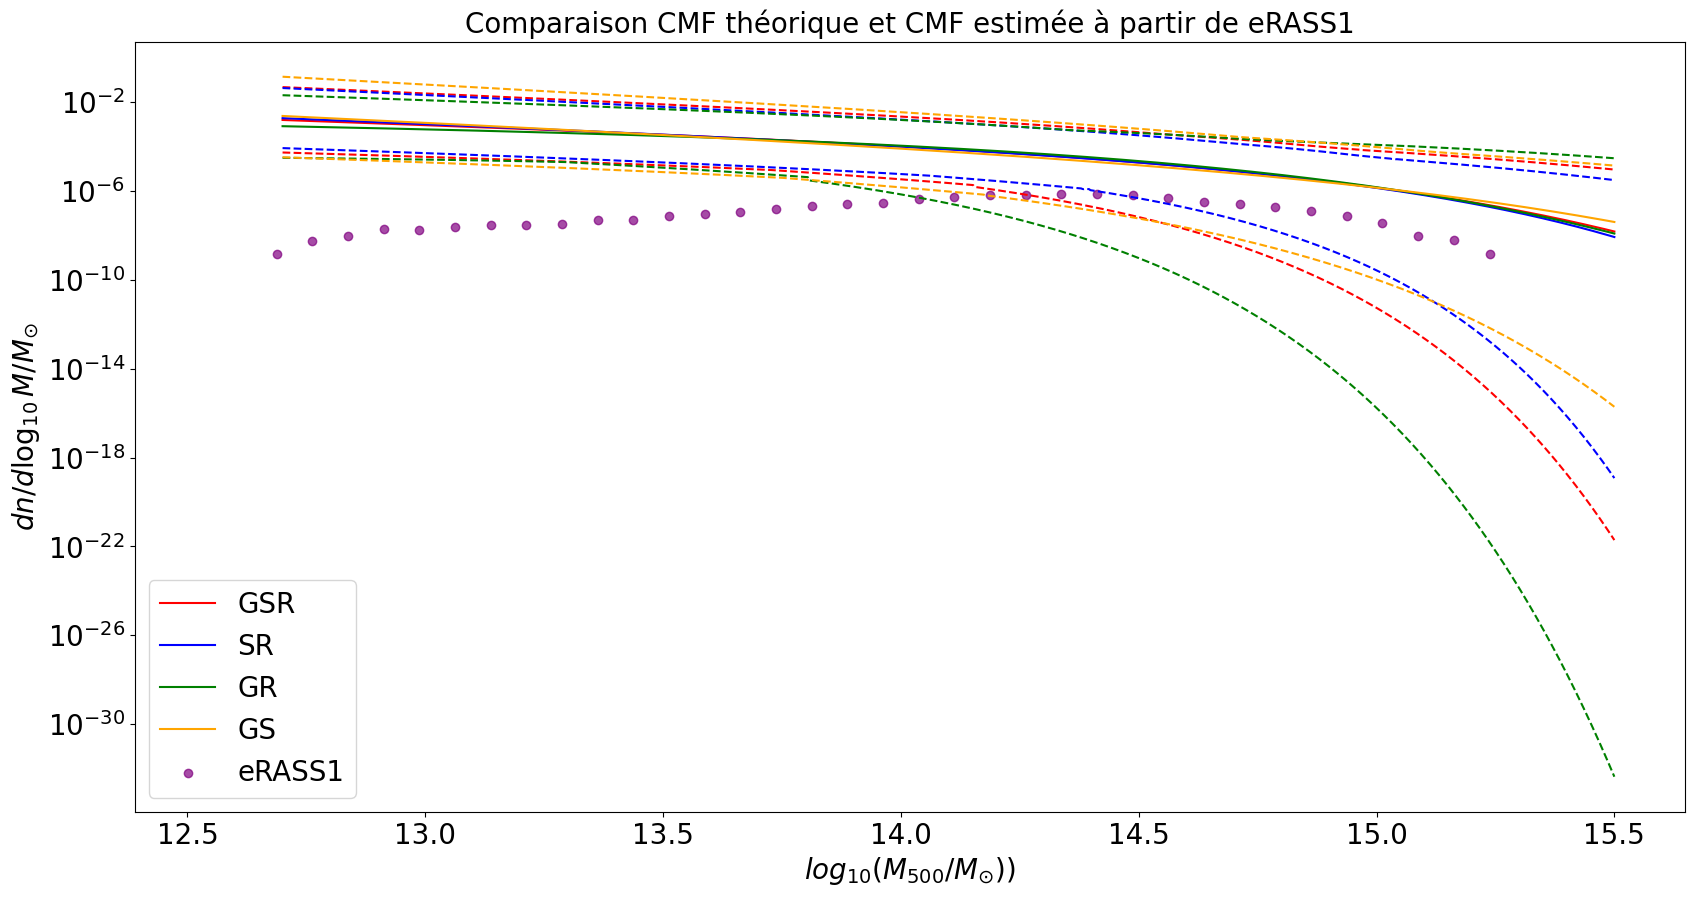

In [73]:
# Mpc ^-3 dex -1
fig = plt.figure(figsize=(20, 10))

plt.plot(log10_M_Msun, CMF_GSR, label='GSR', color='red')
plt.plot(log10_M_Msun, Borne_min_CMF_GSR, color='red',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GSR, color='red',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_SR, label='SR', color='blue')
plt.plot(log10_M_Msun, Borne_min_CMF_SR, color='blue',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_SR, color='blue',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_GR, label='GR', color='green')
plt.plot(log10_M_Msun, Borne_min_CMF_GR, color='green',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GR, color='green',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_GS, label='GS', color='orange')
plt.plot(log10_M_Msun, Borne_min_CMF_GS, color='orange',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GS, color='orange',linestyle='dashed')

plt.scatter(bin_centers, n_eRASS1, color='purple', label='eRASS1', alpha=0.7)

plt.xlabel(r'$log_{10}(M_{500}/M_{\odot})$)')
plt.ylabel(r'$dn / d\log_{10} M / M_{\odot}$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de eRASS1')
plt.legend()

In [74]:
'''# dex ^-1

fig = plt.figure(figsize=(20, 10))
plt.plot(log10_M_Msun, CMF_GSR*volume_eRASS1, label='GSR', color='red')
plt.scatter(bin_centers, counts/bin_width_eRASS1, color='blue', label='eRASS1', alpha=0.7)
plt.xlabel(r'$log_{10}(M_{500}/M_{\odot})$)')
plt.ylabel(r'$\log_{10} M / M_{\odot}$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de eRASS1')
plt.legend()
'''

<>:1: SyntaxWarning: invalid escape sequence '\o'
<>:1: SyntaxWarning: invalid escape sequence '\o'
C:\Users\ED282972\AppData\Local\Temp\ipykernel_16740\2293506136.py:1: SyntaxWarning: invalid escape sequence '\o'
  '''# dex ^-1


"# dex ^-1\n\nfig = plt.figure(figsize=(20, 10))\nplt.plot(log10_M_Msun, CMF_GSR*volume_eRASS1, label='GSR', color='red')\nplt.scatter(bin_centers, counts/bin_width_eRASS1, color='blue', label='eRASS1', alpha=0.7)\nplt.xlabel(r'$log_{10}(M_{500}/M_{\\odot})$)')\nplt.ylabel(r'$\\log_{10} M / M_{\\odot}$')\nplt.yscale('log')\nplt.title('Comparaison CMF théorique et CMF estimée à partir de eRASS1')\nplt.legend()\n"